In [1]:
!nvidia-smi

Sat May 16 07:33:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   65C    P0             30W /   72W |     260MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1. 구글 드라이브 연동 (마운트)
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd

# 2. 파이썬 파일들이 있는 드라이브 경로 설정 및 시스템 패스에 추가
project_path = '/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/'
sys.path.append(project_path)

from run_regression import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. 우분투 환경에 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 설치된 폰트를 Matplotlib 메모리에 직접 추가 (런타임 재시작 방지)
font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
for fpath in font_files:
    fm.fontManager.addfont(fpath)

# 3. 기본 폰트 및 설정 변경
plt.rc('font', family='NanumSquare') # 폰트 이름 설정 (NanumGothic, NanumBarunGothic 등 사용 가능)
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호 깨짐 방지

# 4. 테스트용 코드 (한글이 잘 나오는지 확인)
# plt.figure(figsize=(5, 3))
# plt.title("한글 폰트 적용 테스트 (마이너스: -100)")
# plt.plot([-100, 0, 100], [-100, 0, 100])
# plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [4]:
# 3. 데이터 로드
file_path = os.path.join(project_path, 'data/raw/binance_processed_futures_8hr_260514.parquet')
df = pd.read_parquet(file_path)
var_list = ['Open', 'High', 'Low', 'Close', 'Volume'
            , 'Number of trades'
            , 'fundingRate']
df['BAS_DT']=df['Open time'].dt.strftime('%Y%m%d%H')
df['day_of_week'] = df['Open time'].dt.day_of_week # 요일 0:월, 1:화, ... 6:일
df['hour'] = df['Open time'].dt.hour/8 # 시간대(0,1,2)
var_time = ['BAS_DT','day_of_week','hour']


🚀 [Trial 1/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 8, 'seq_length': 21}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121808~2026030100 자료 추출 중 : 1095
test set : 2026021508~2026041200 자료 추출 중 : 840
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.114968 | val_loss=0.121497 | test_loss=0.091520 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/1_2605160733_D32_H64_N8_SEQ21/tft_best.pt
***[TFT Epoch:002] train_loss=0.110106 | val_loss=0.117113 | test_loss=0.086409 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/1_2605160733_D32_H64_N8_SEQ21/tft_best.pt
***[TFT Epoch:003] train_loss=0.112090 | val_loss=0.105122 | test_loss=0.084923 | lr=3.99e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/1_2605160733_D32_H64_N8_SEQ21/tft_best.pt
***[TFT Ep

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


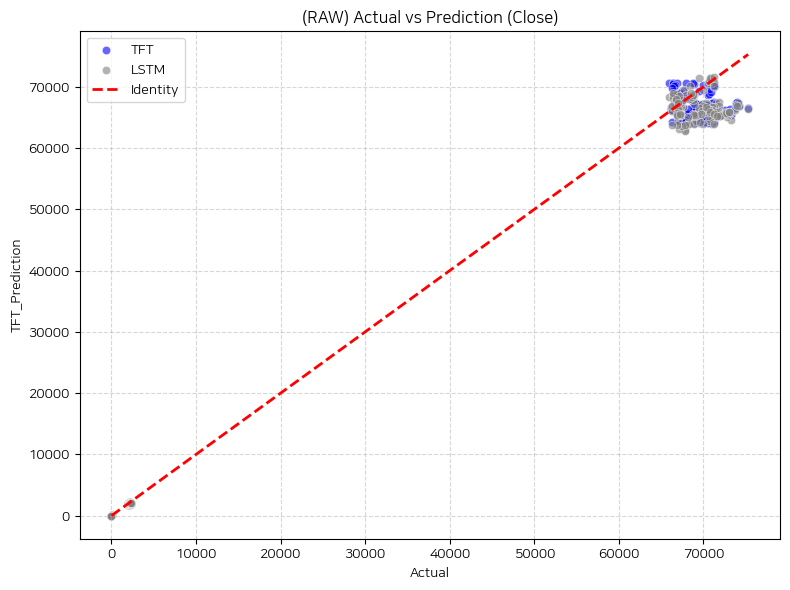

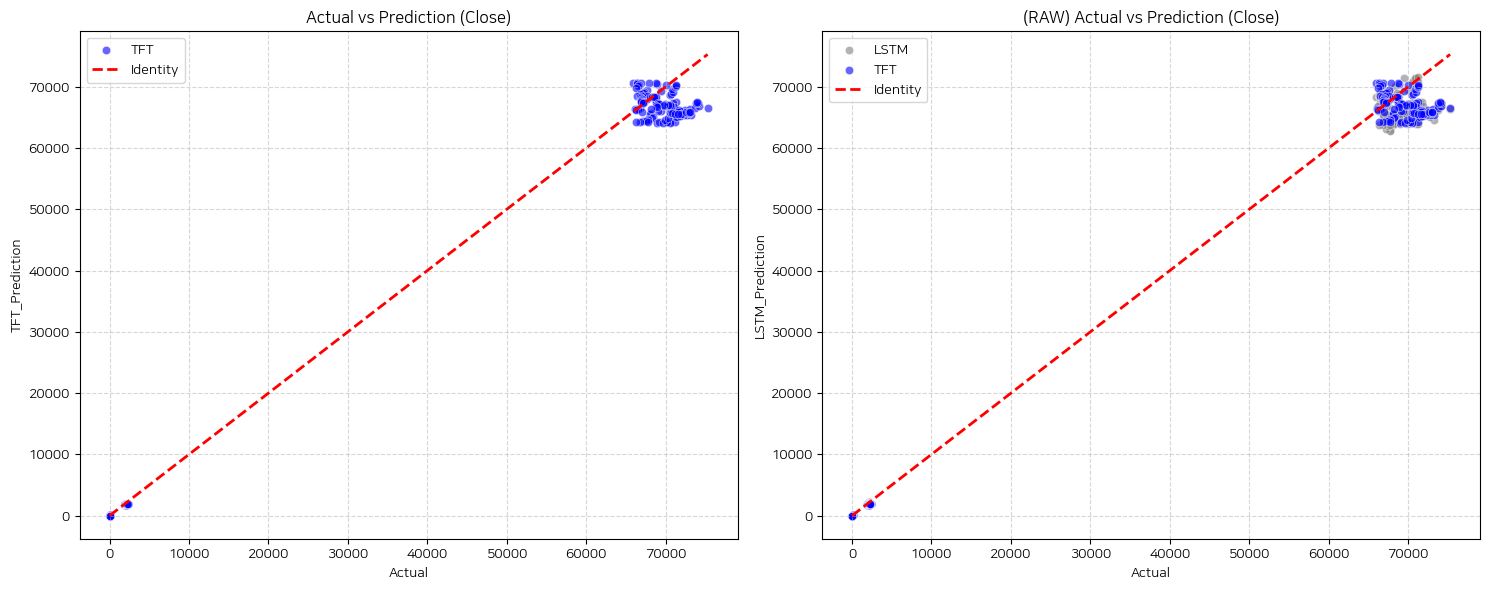

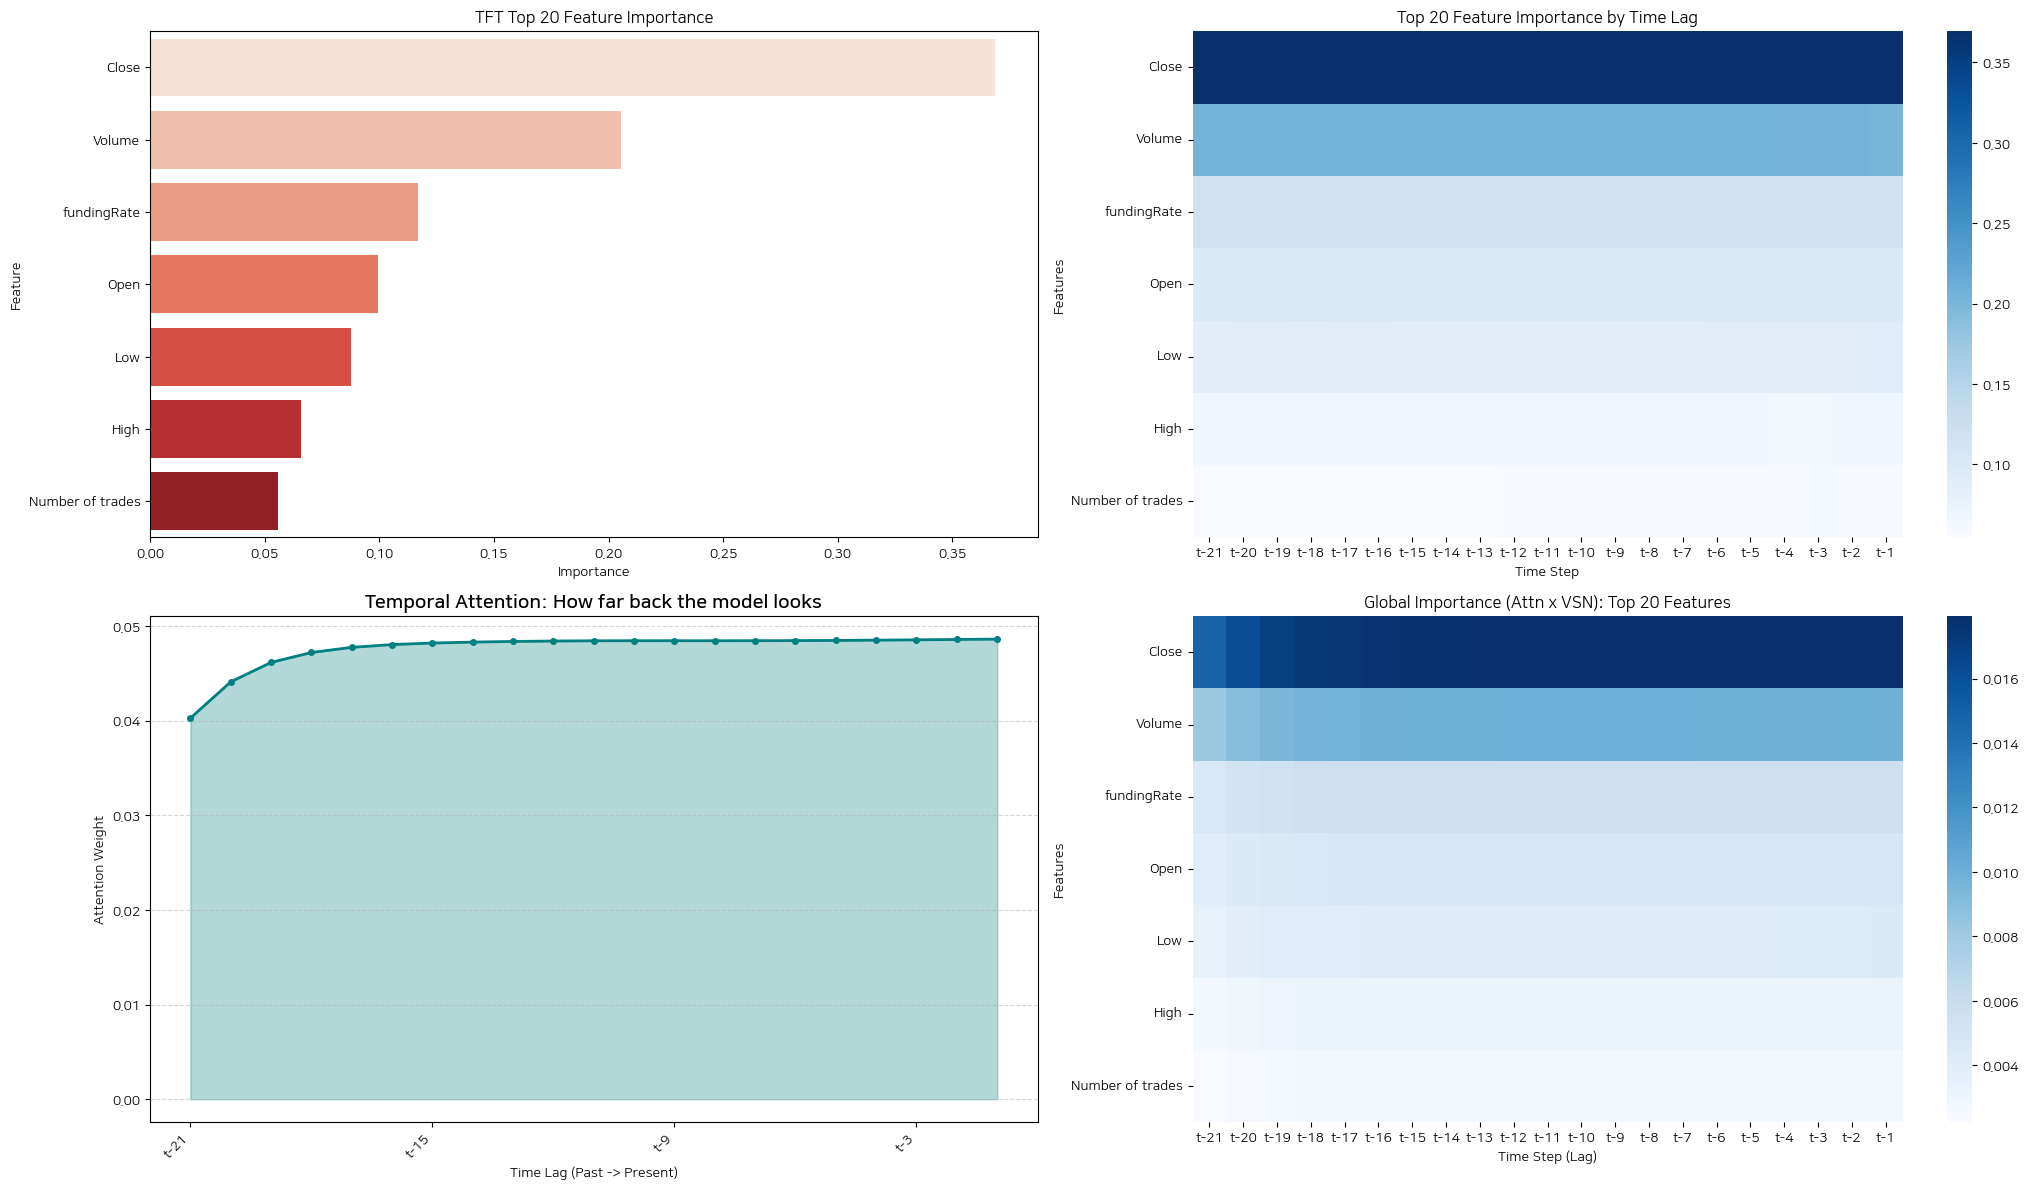

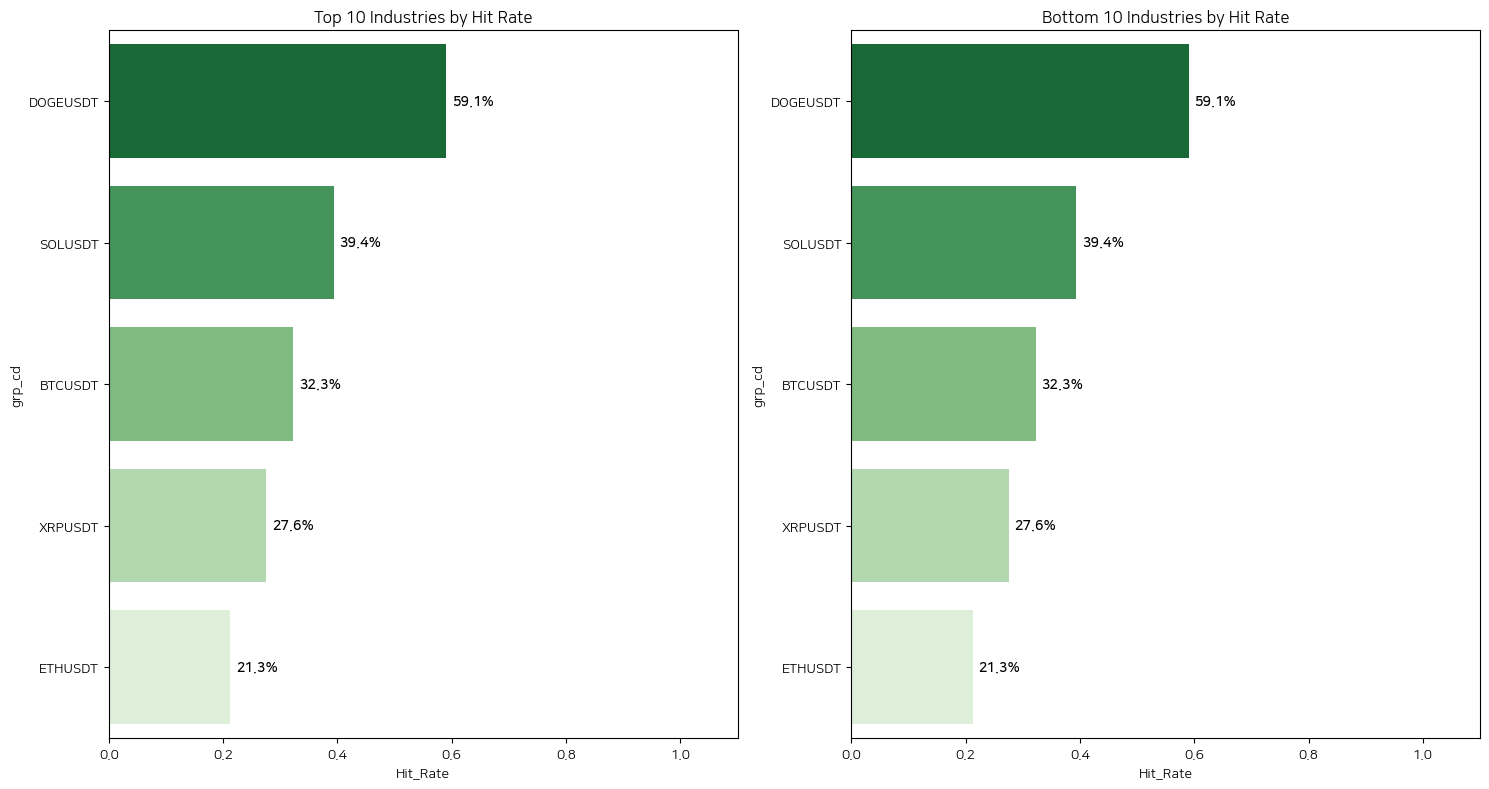

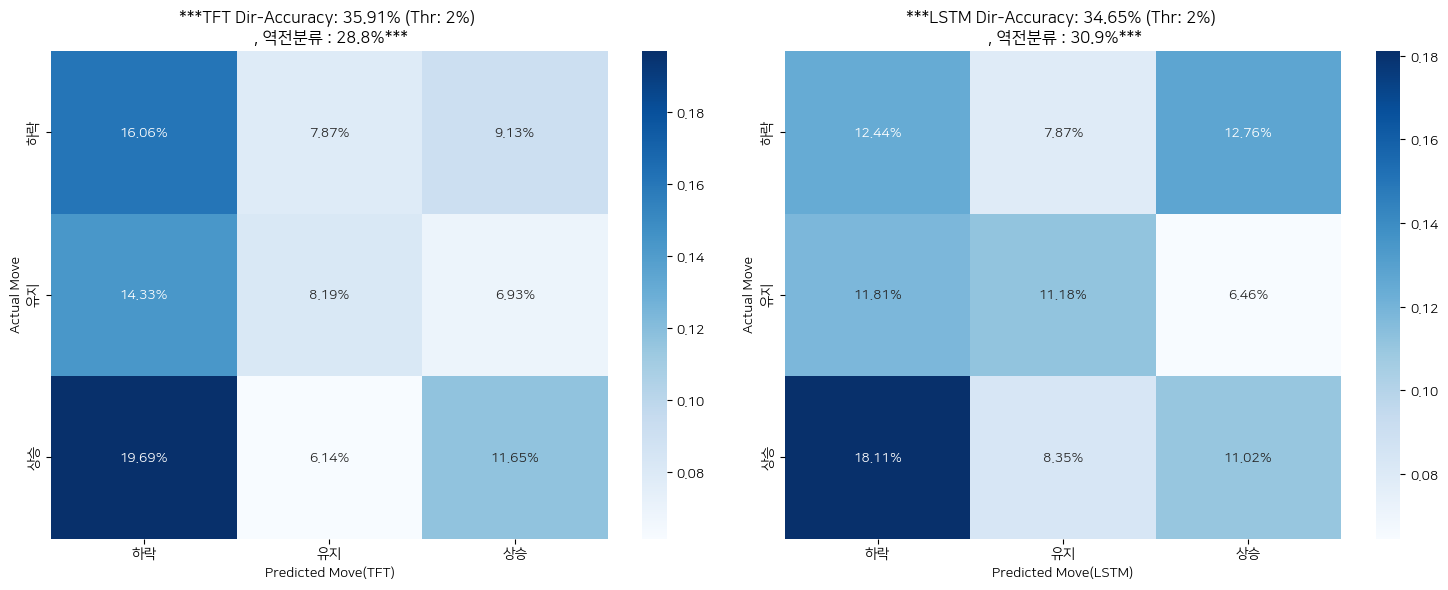

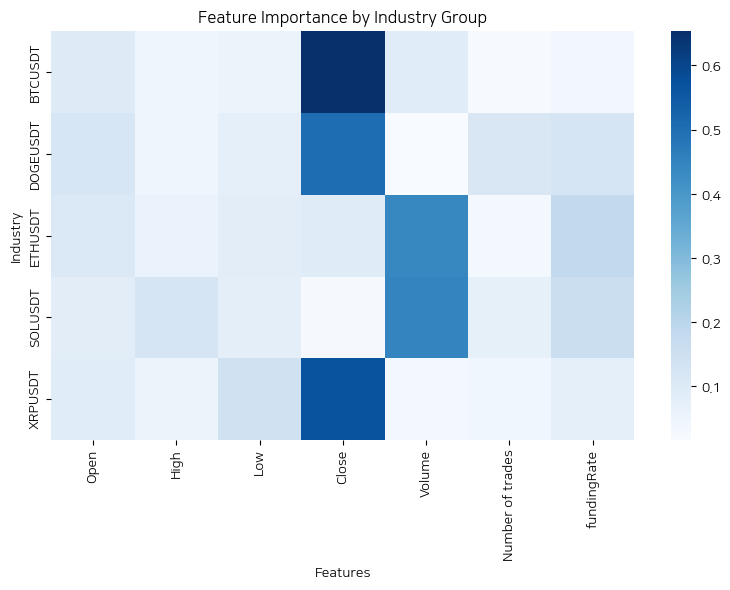

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 2/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 8, 'seq_length': 42}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121108~2026030100 자료 추출 중 : 1200
test set : 2026020808~2026041200 자료 추출 중 : 945
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.124128 | val_loss=0.137557 | test_loss=0.093551 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/2_2605160735_D32_H64_N8_SEQ42/tft_best.pt
***[TFT Epoch:002] train_loss=0.119484 | val_loss=0.136195 | test_loss=0.089591 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/2_2605160735_D32_H64_N8_SEQ42/tft_best.pt
***[TFT Epoch:003] train_loss=0.118106 | val_loss=0.158721 | test_loss=0.106326 | lr=3.99e-04***
***[TFT Epoch:004] train_loss=0.11

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


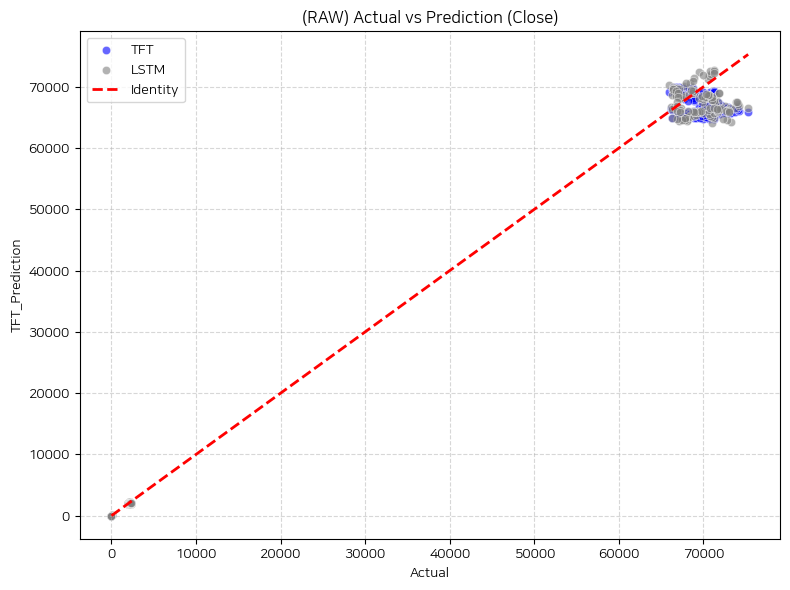

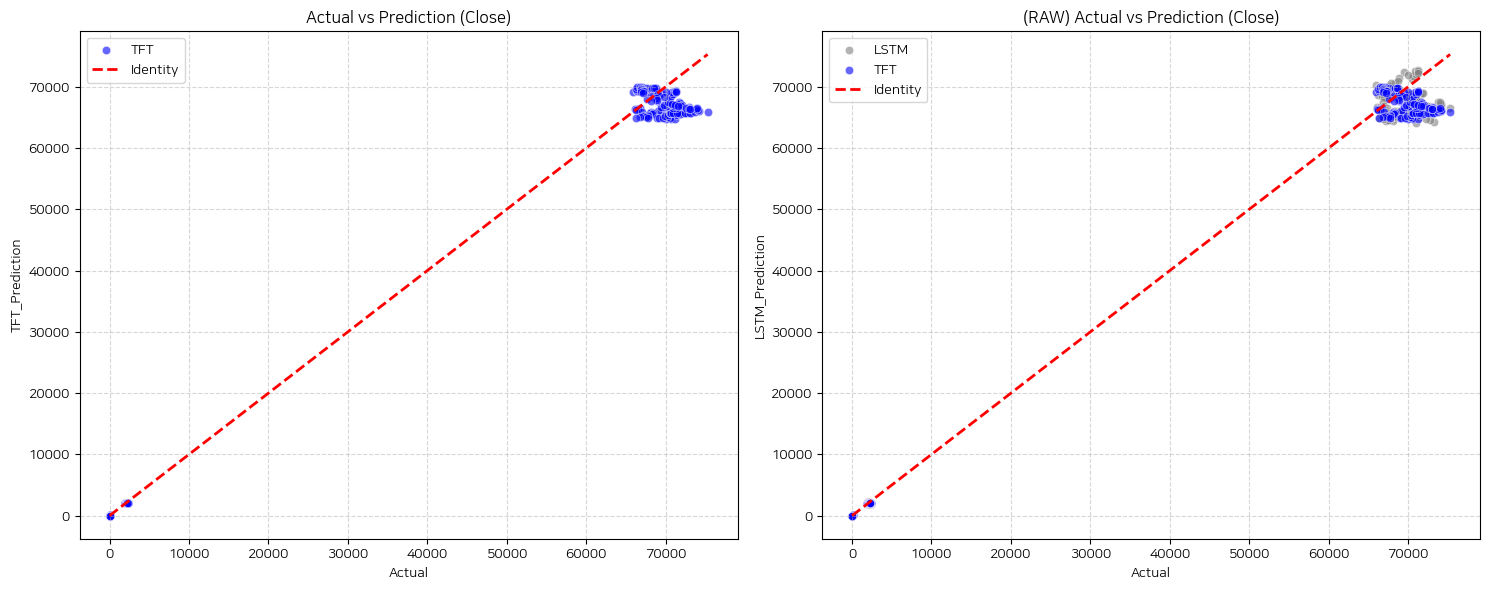

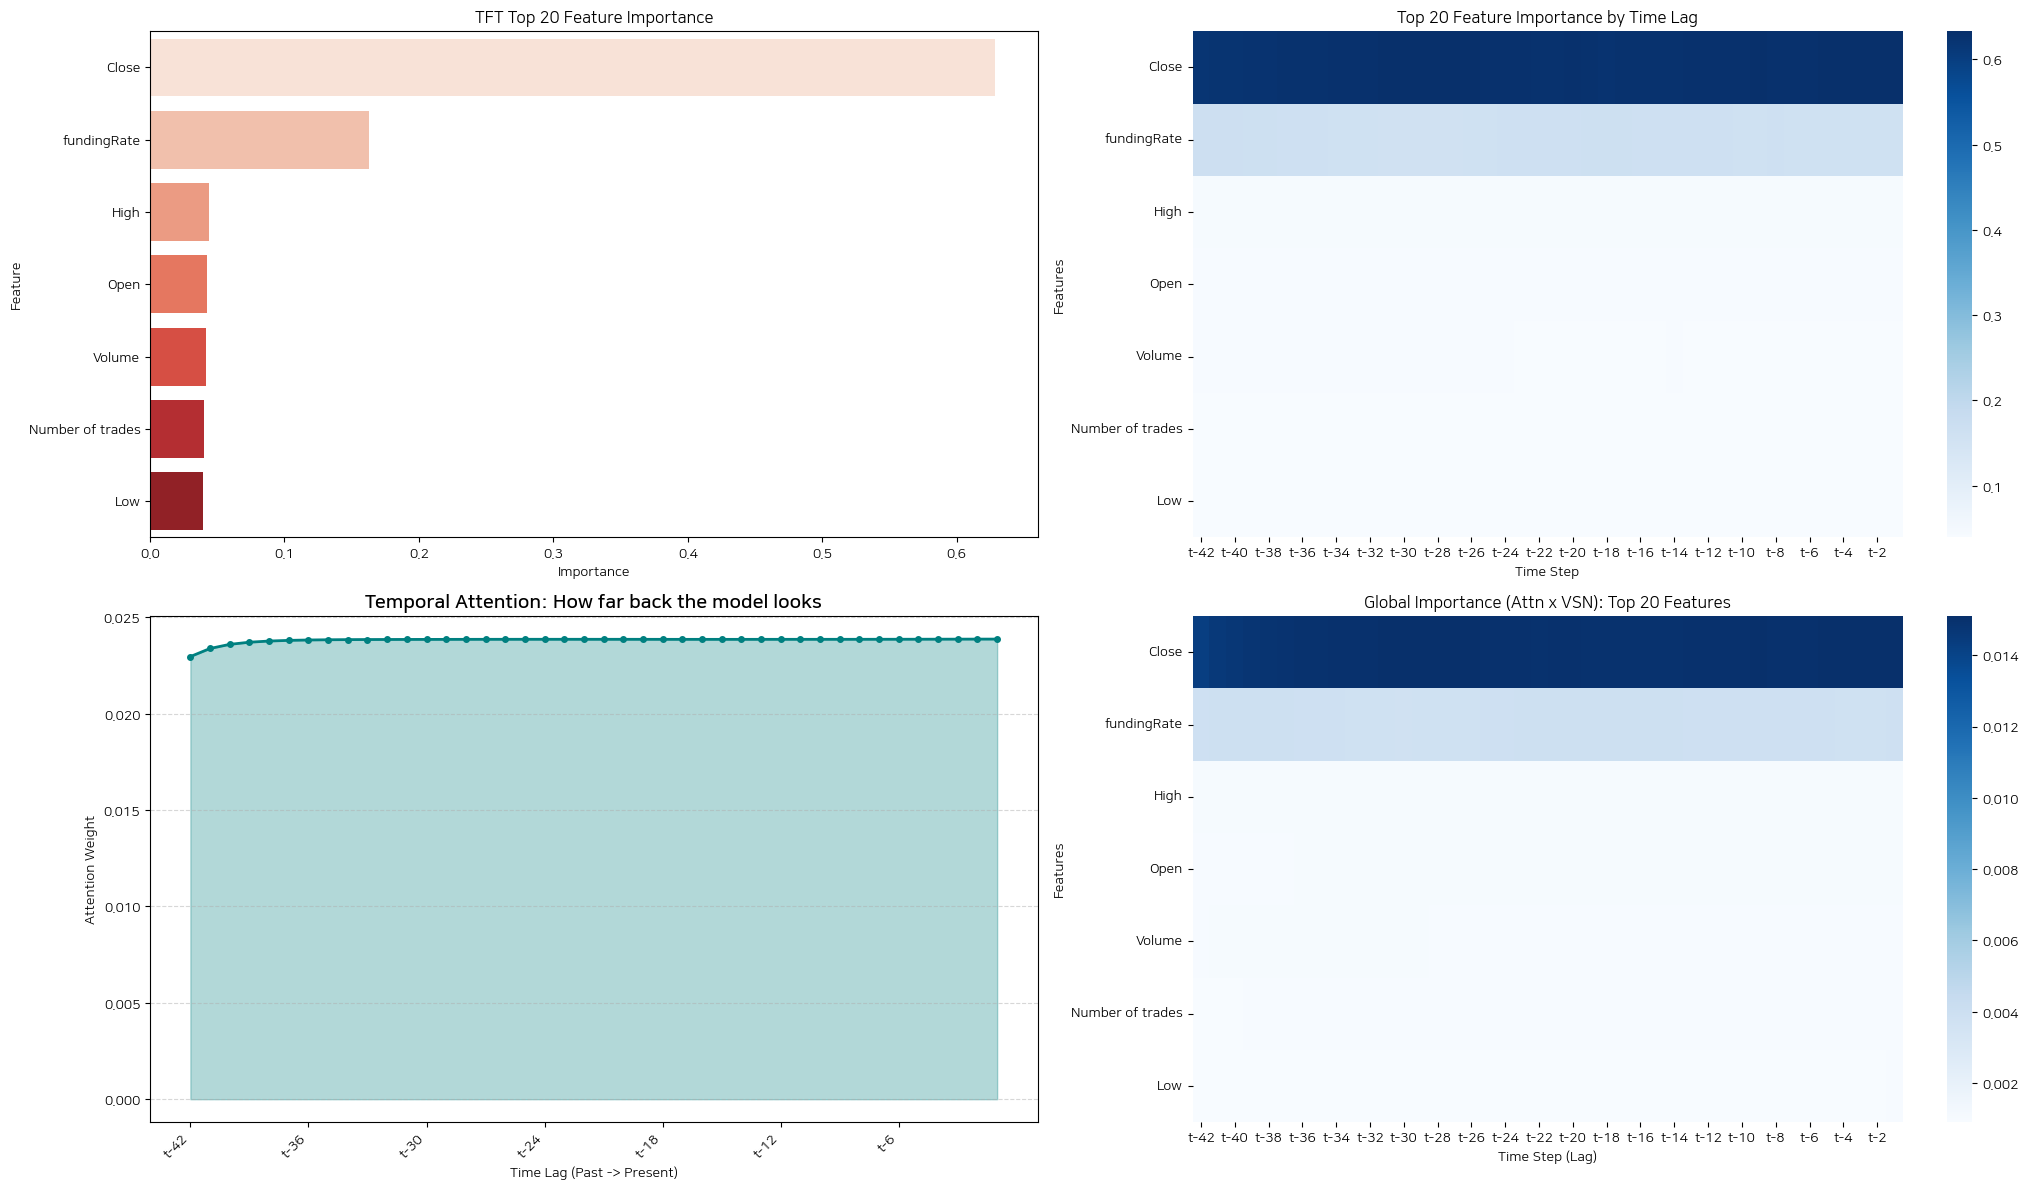

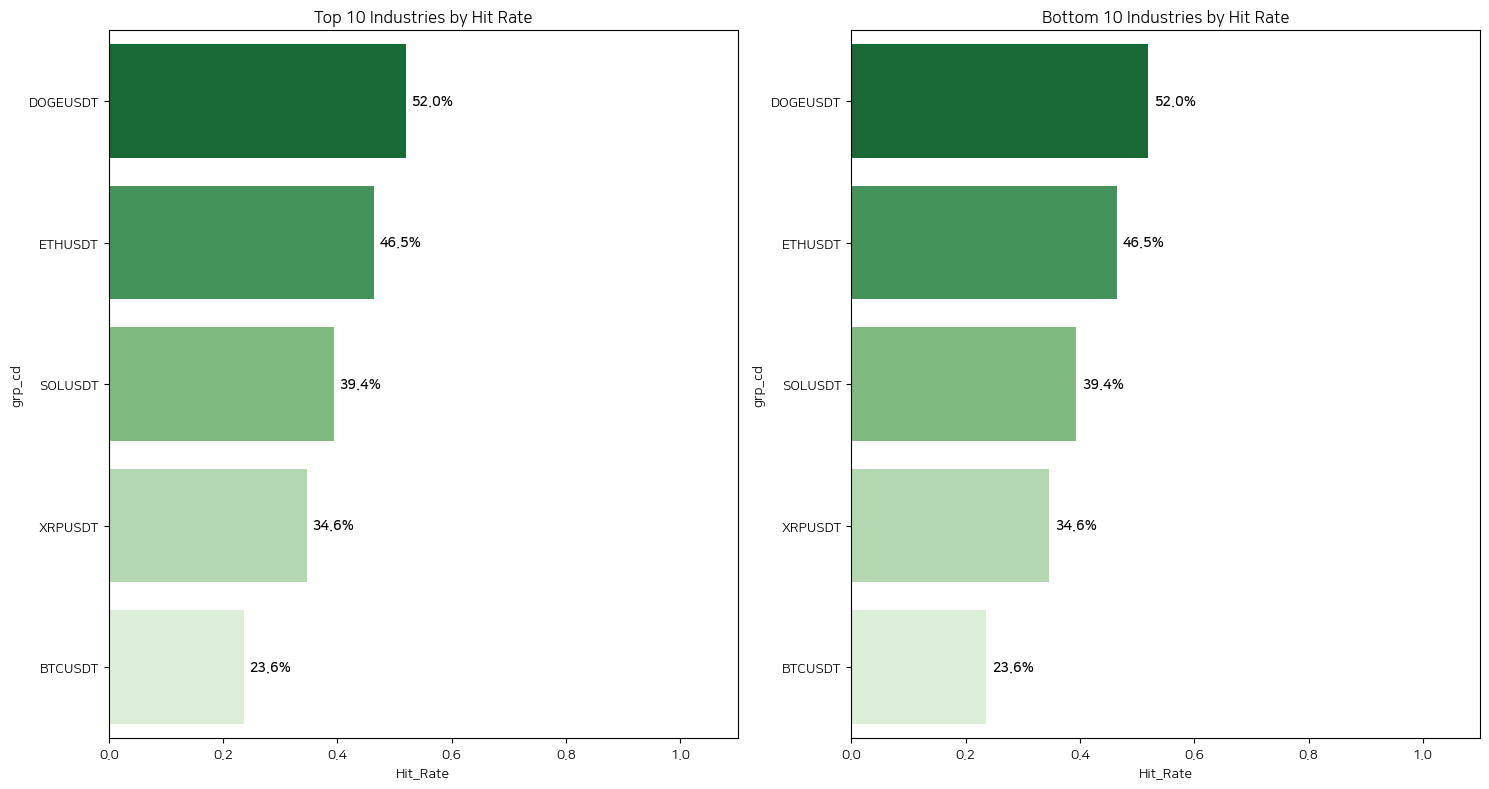

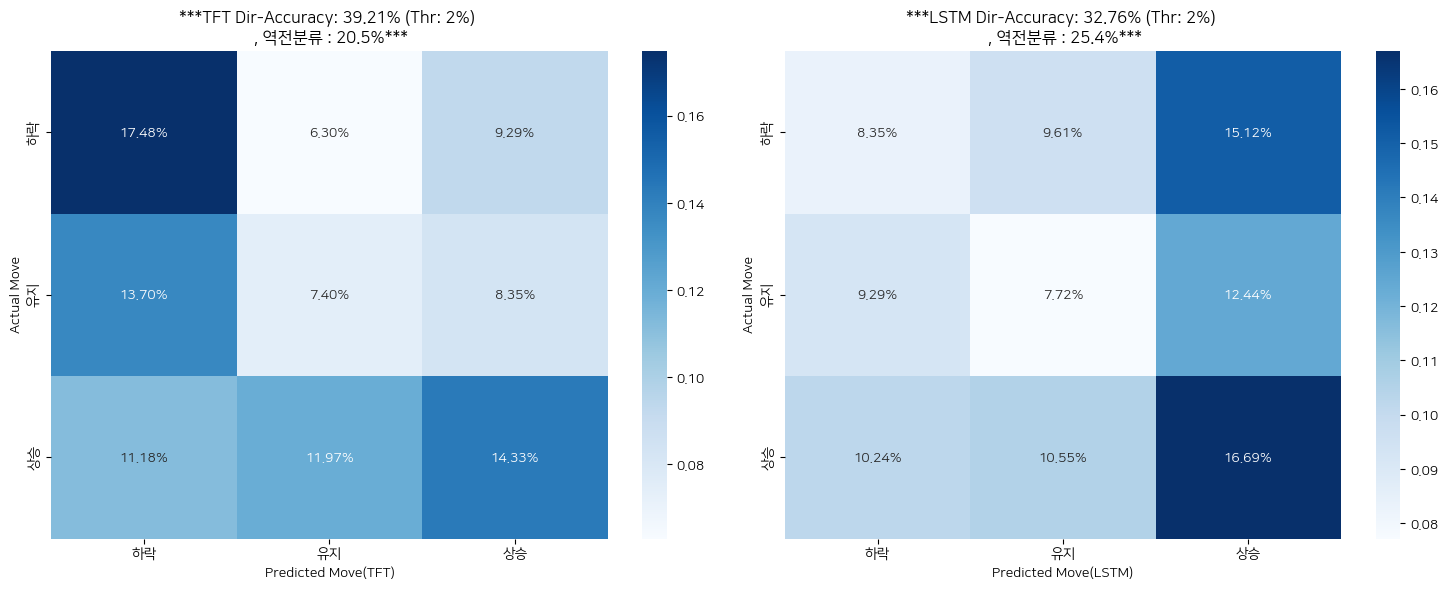

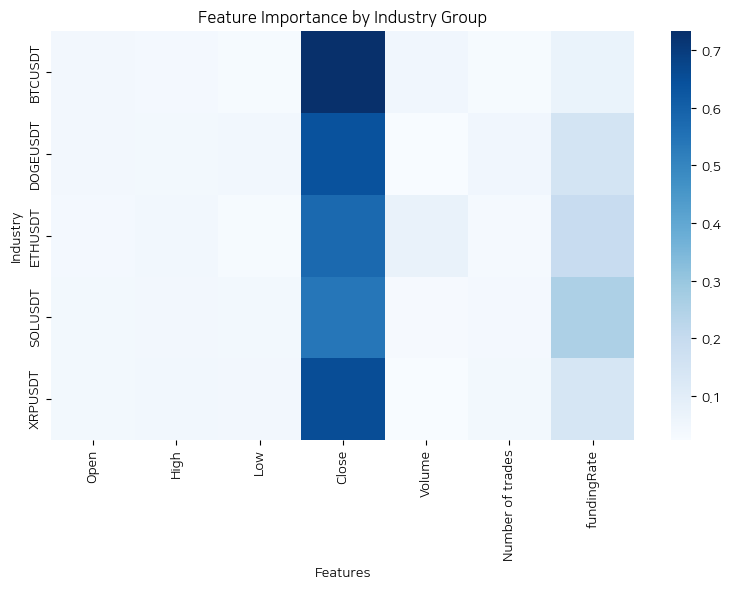

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 3/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 8, 'seq_length': 63}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025120408~2026030100 자료 추출 중 : 1305
test set : 2026020108~2026041200 자료 추출 중 : 1050
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.132140 | val_loss=0.160984 | test_loss=0.101782 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/3_2605160737_D32_H64_N8_SEQ63/tft_best.pt
***[TFT Epoch:002] train_loss=0.128523 | val_loss=0.160195 | test_loss=0.106353 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/3_2605160737_D32_H64_N8_SEQ63/tft_best.pt
***[TFT Epoch:003] train_loss=0.118008 | val_loss=0.142658 | test_loss=0.112466 | lr=3.99e-04***
 -> saved best to /content/drive/

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


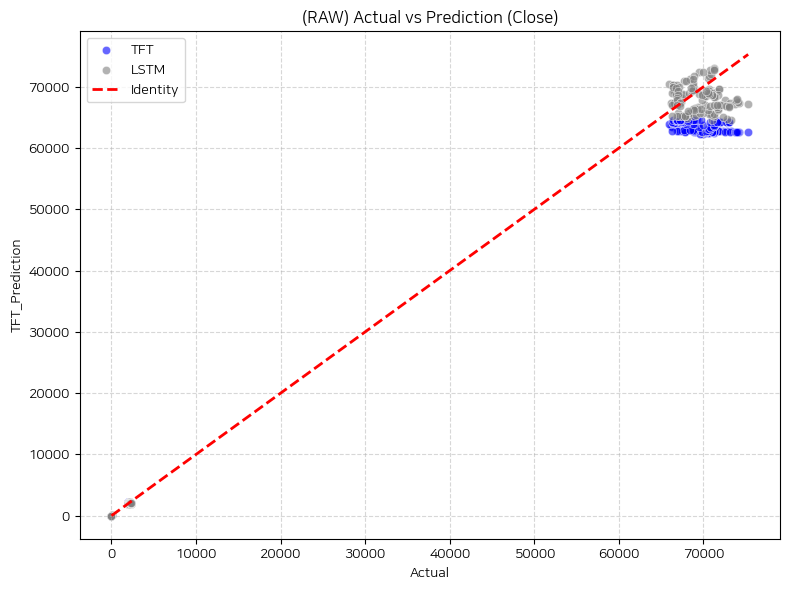

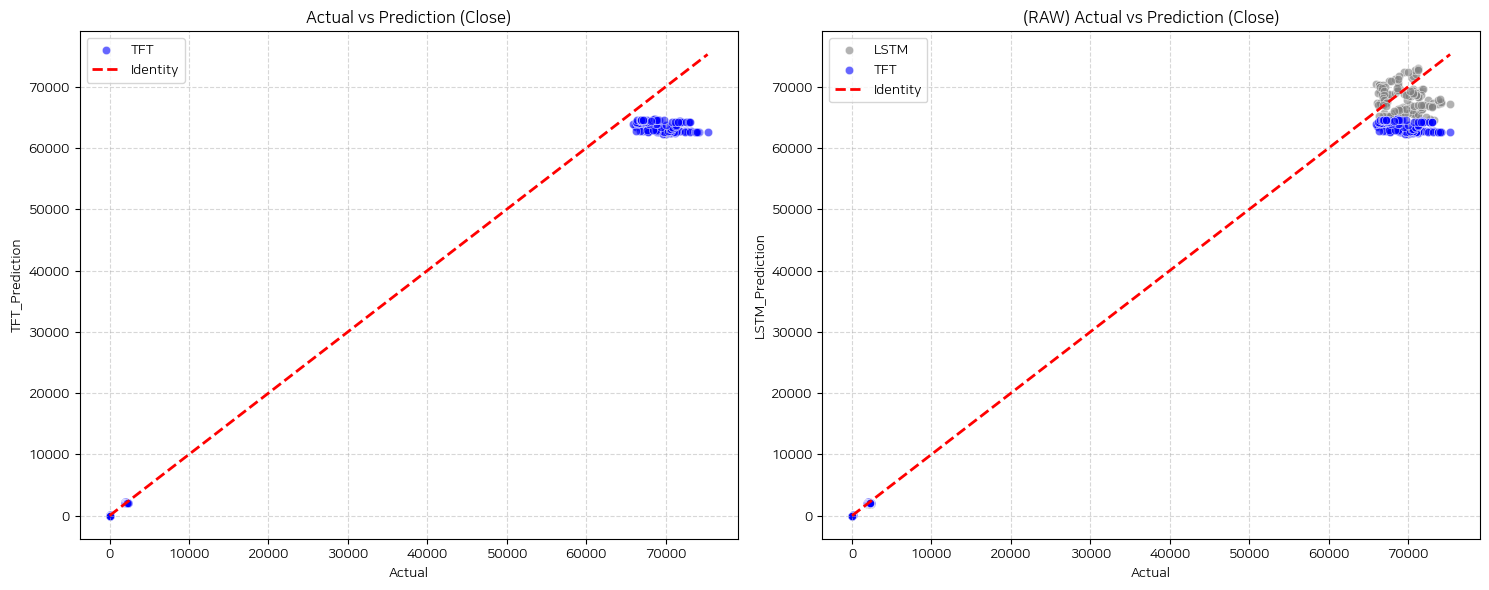

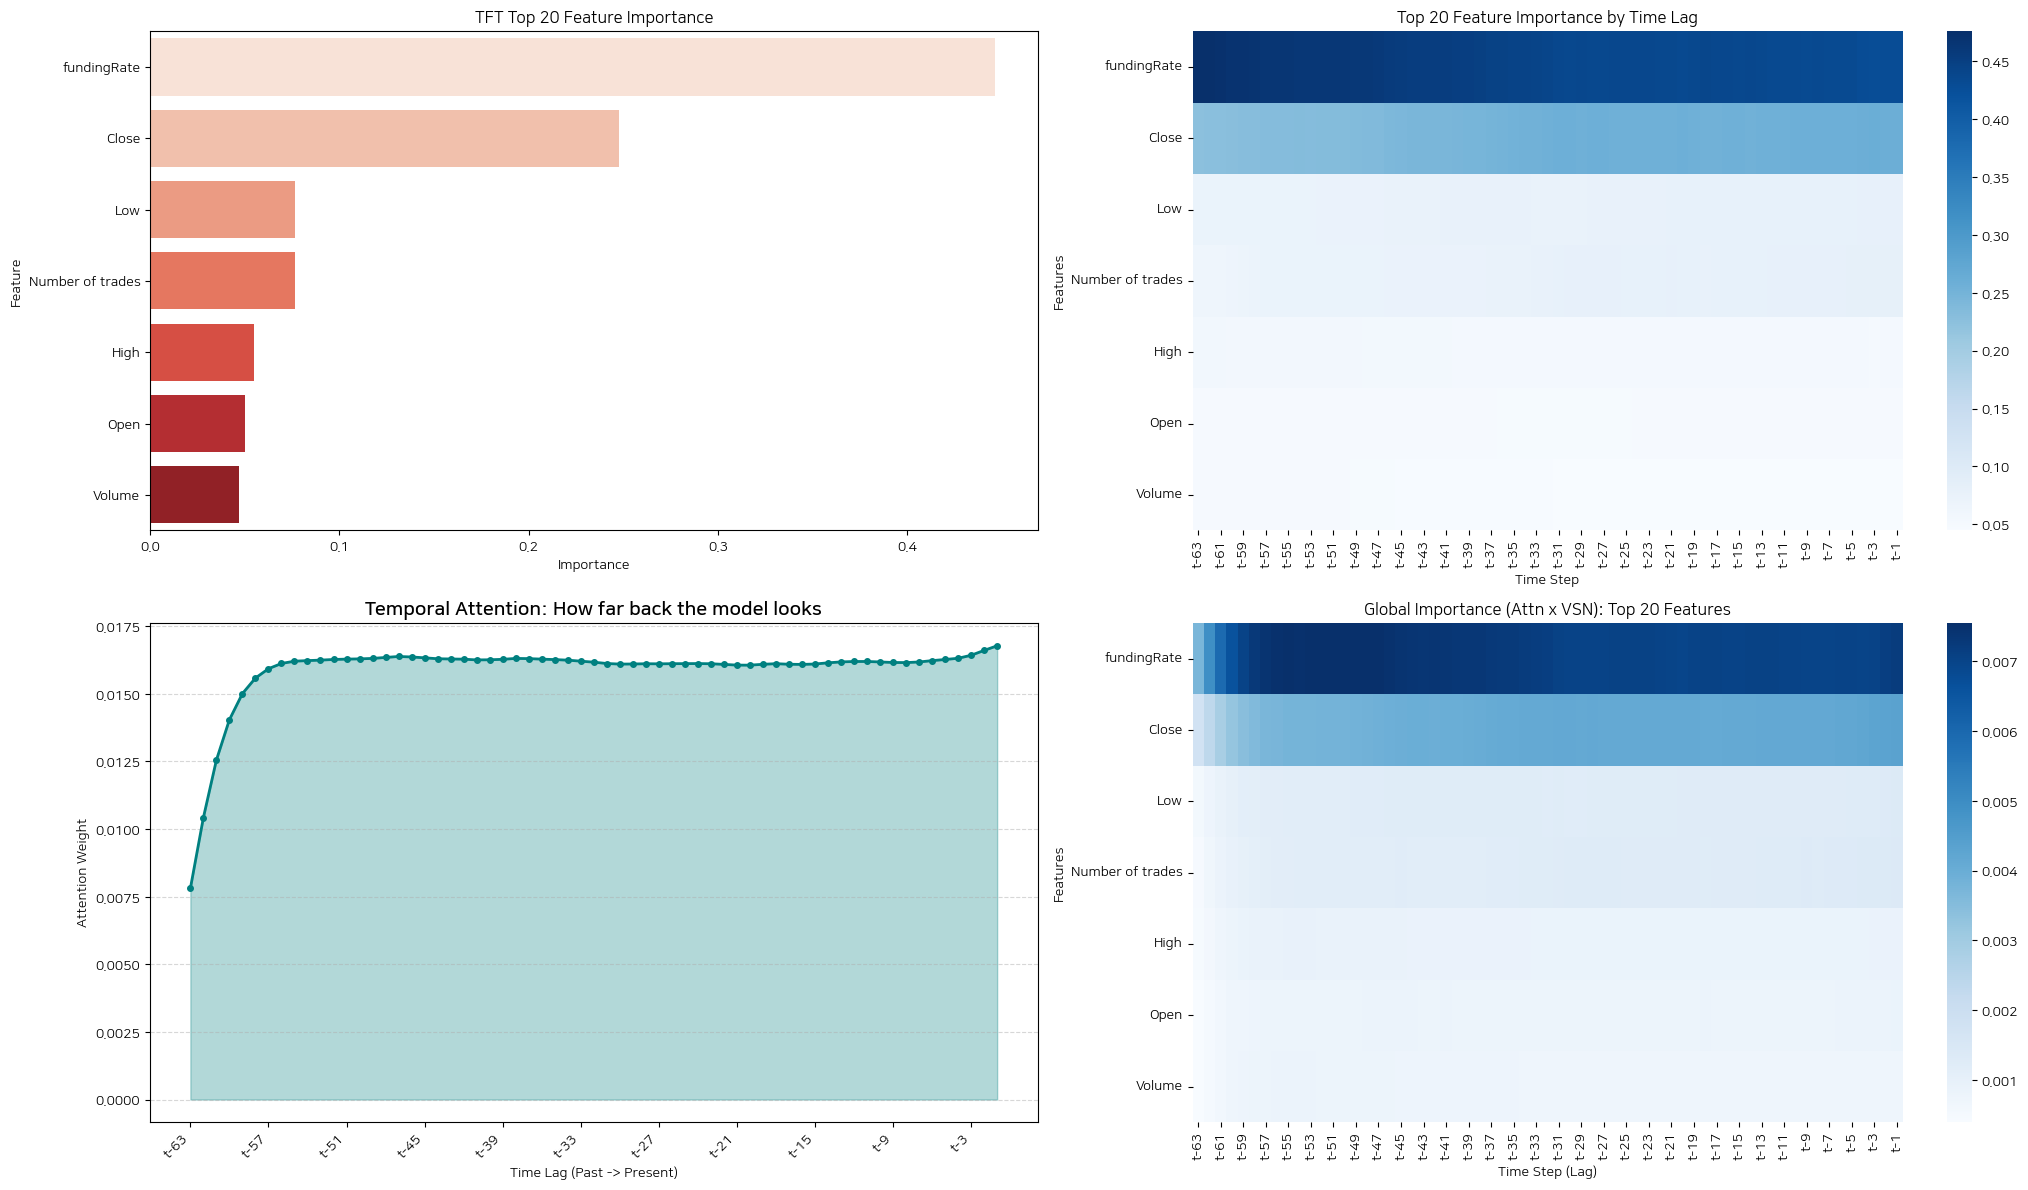

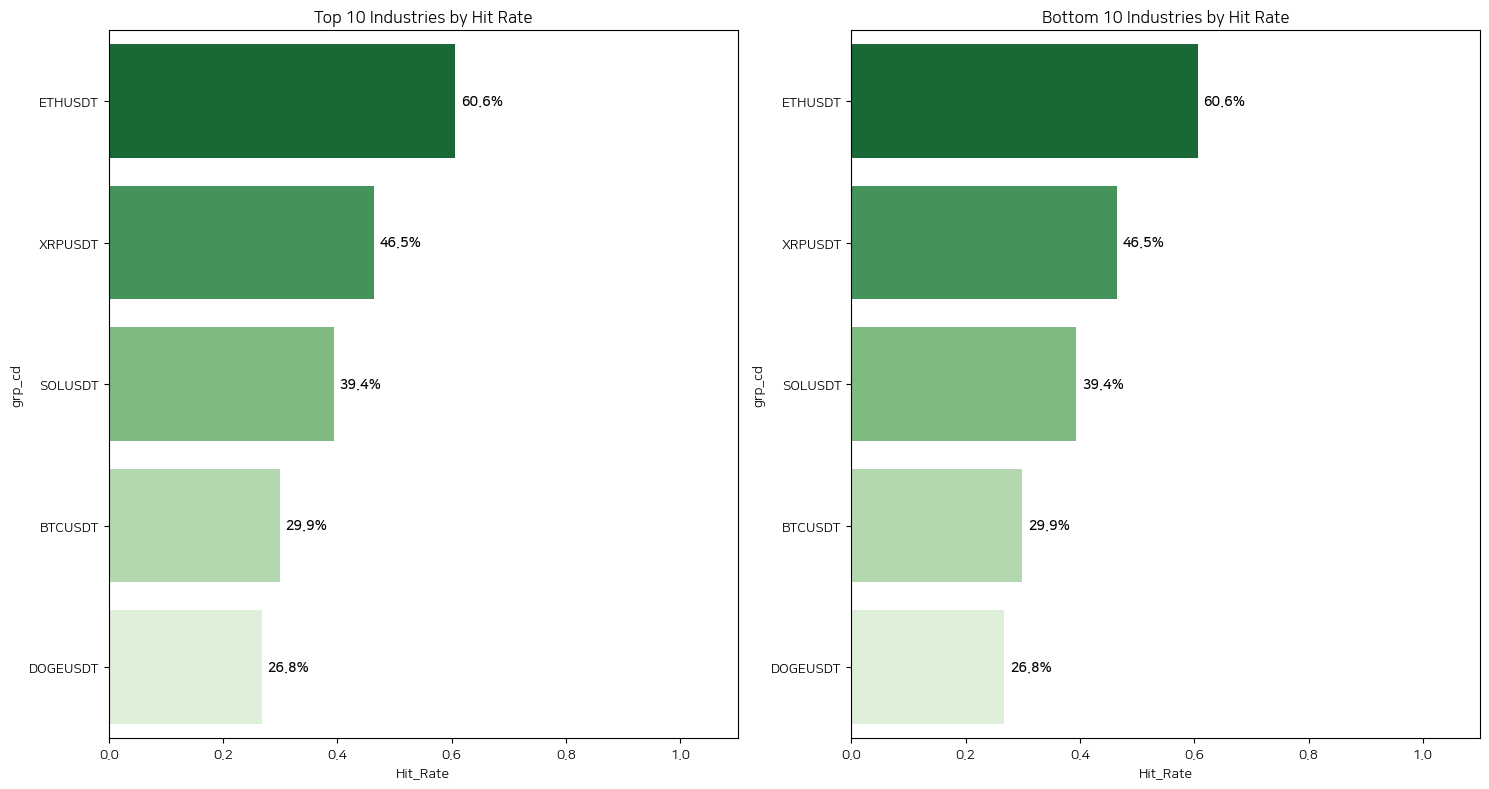

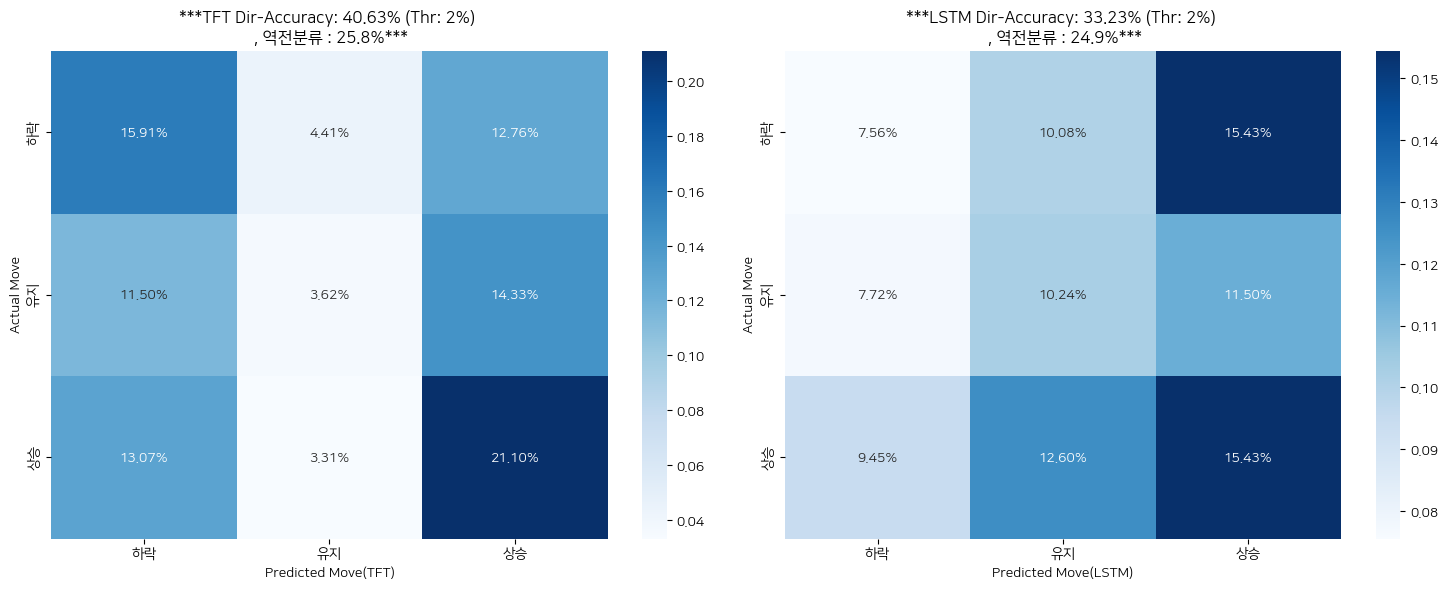

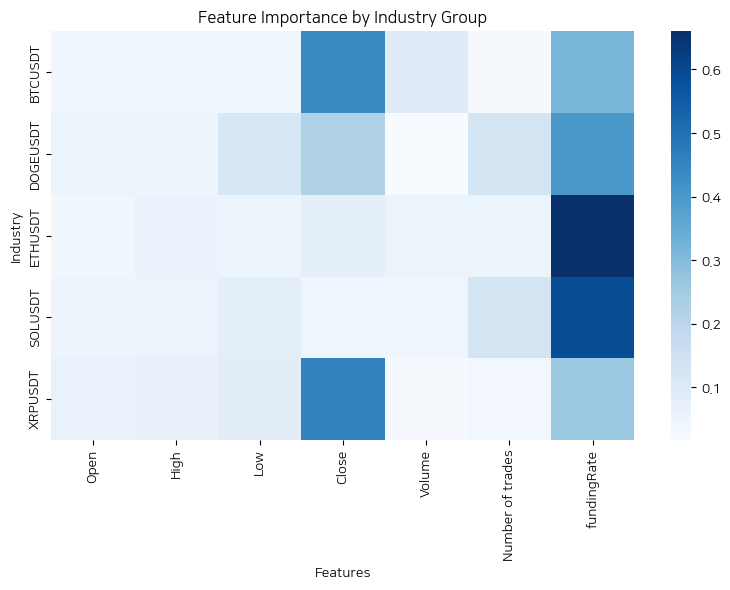

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 4/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 16, 'seq_length': 21}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121808~2026030100 자료 추출 중 : 1095
test set : 2026021508~2026041200 자료 추출 중 : 840
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.115764 | val_loss=0.121149 | test_loss=0.091338 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/4_2605160739_D32_H64_N16_SEQ21/tft_best.pt
***[TFT Epoch:002] train_loss=0.110868 | val_loss=0.118858 | test_loss=0.090149 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/4_2605160739_D32_H64_N16_SEQ21/tft_best.pt
***[TFT Epoch:003] train_loss=0.111277 | val_loss=0.105068 | test_loss=0.085004 | lr=3.99e-04***
 -> saved best to /content/driv

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


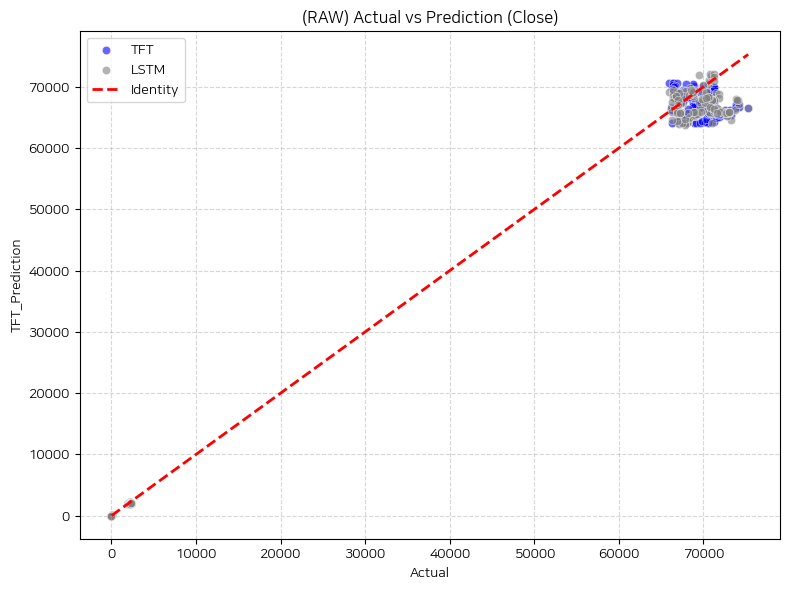

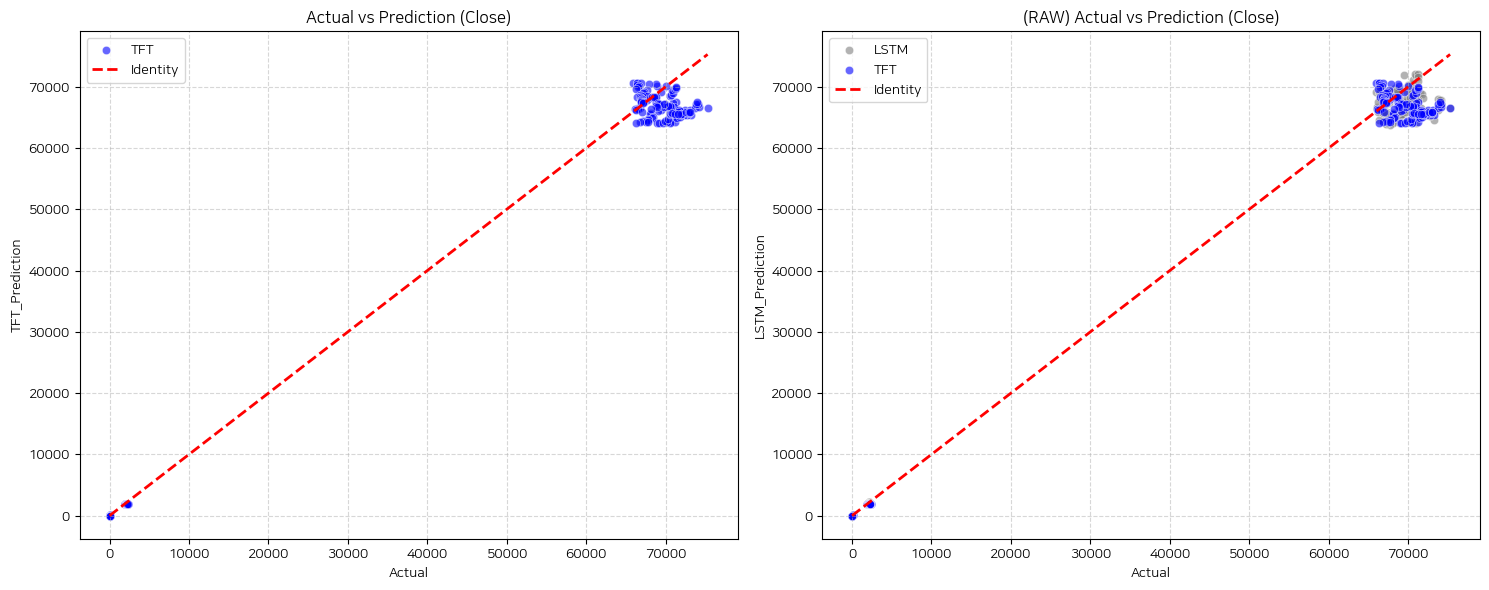

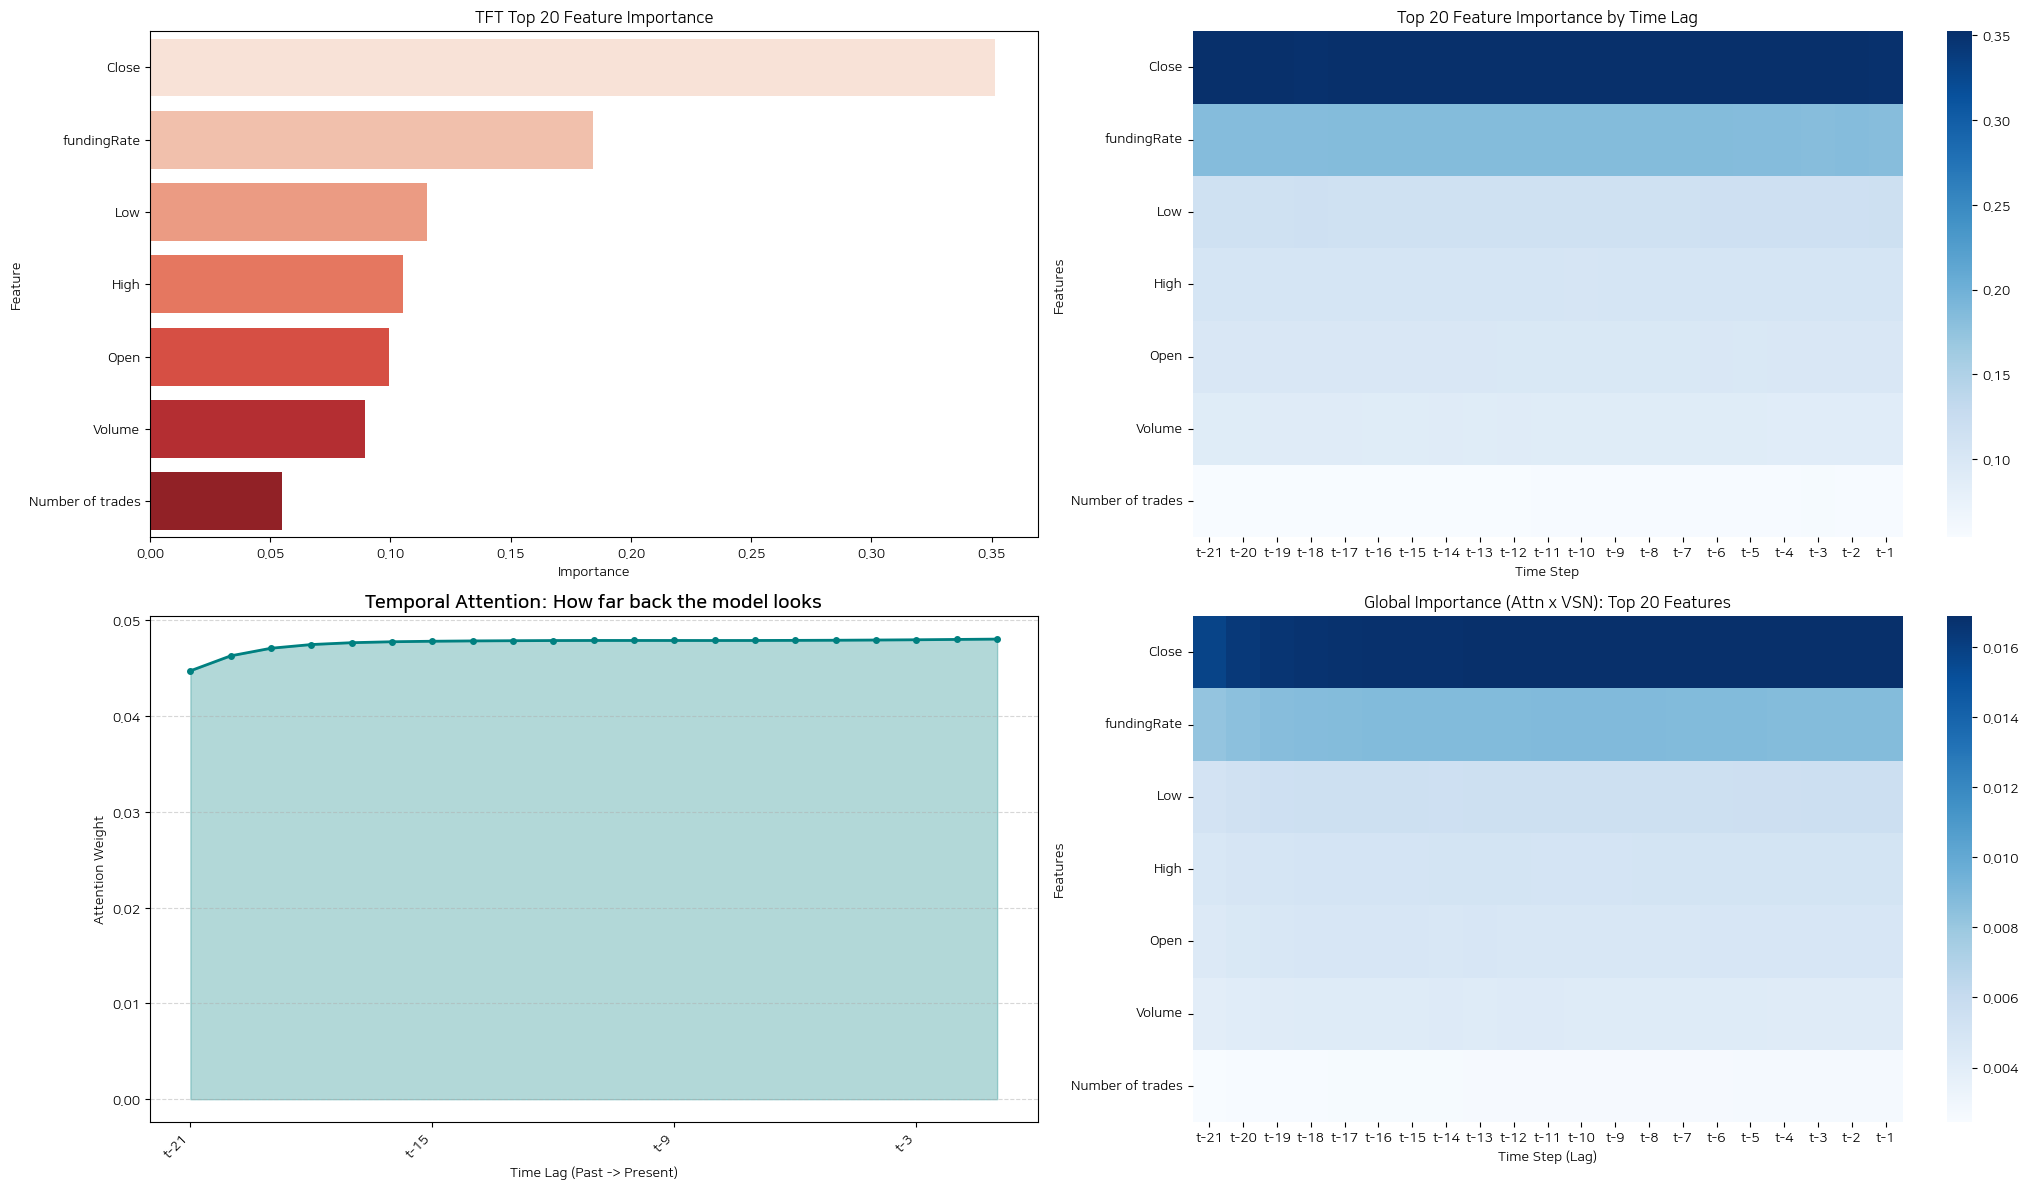

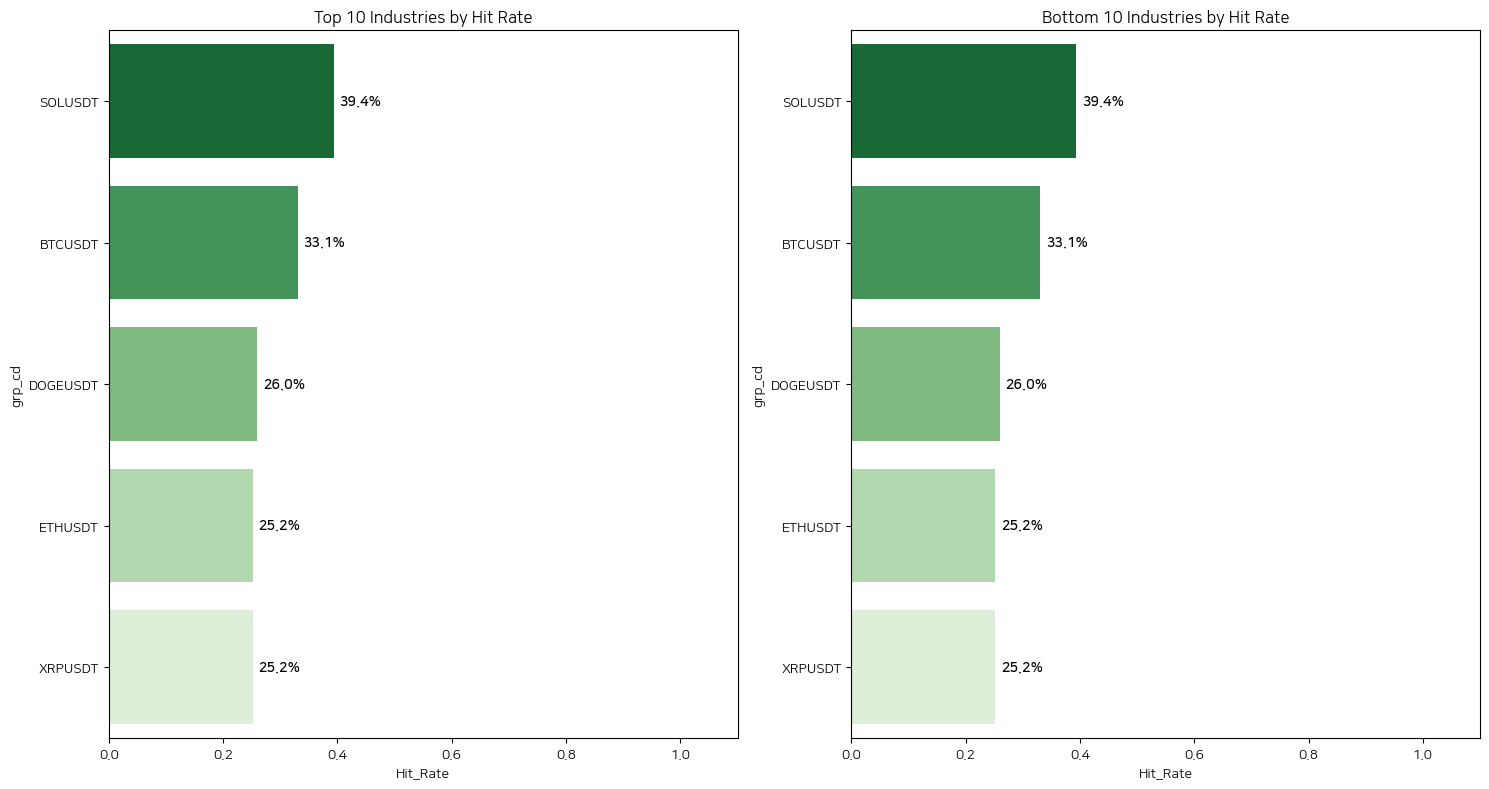

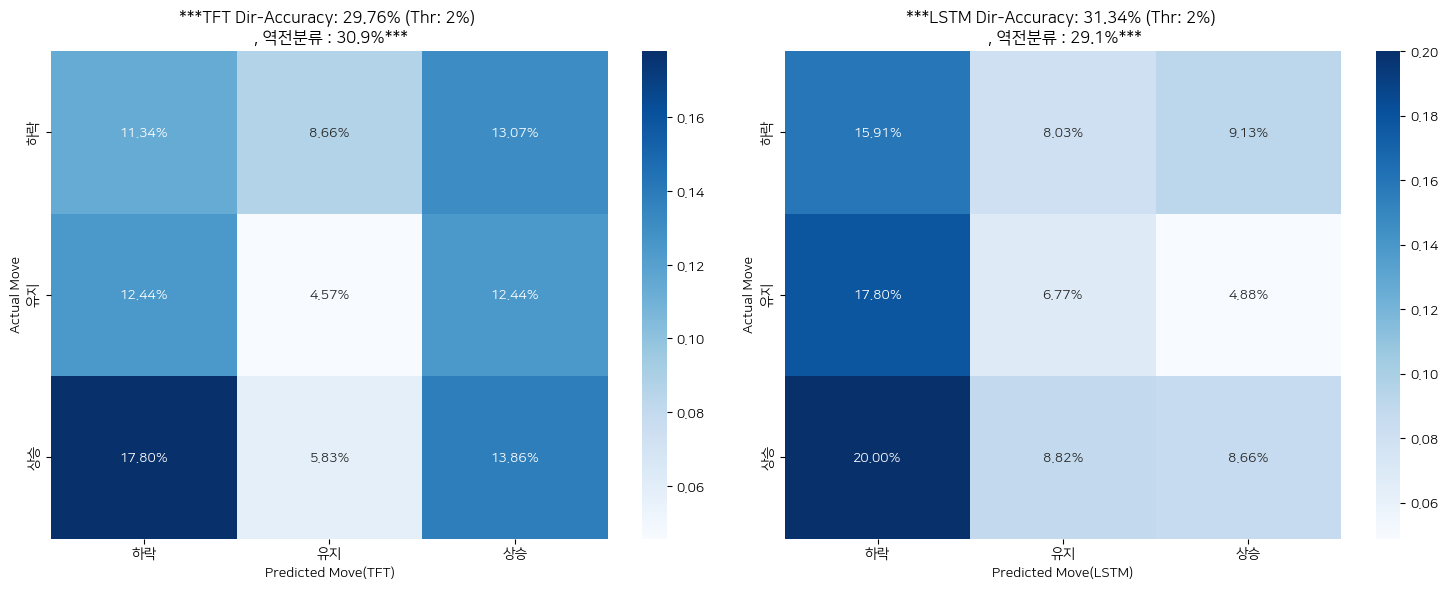

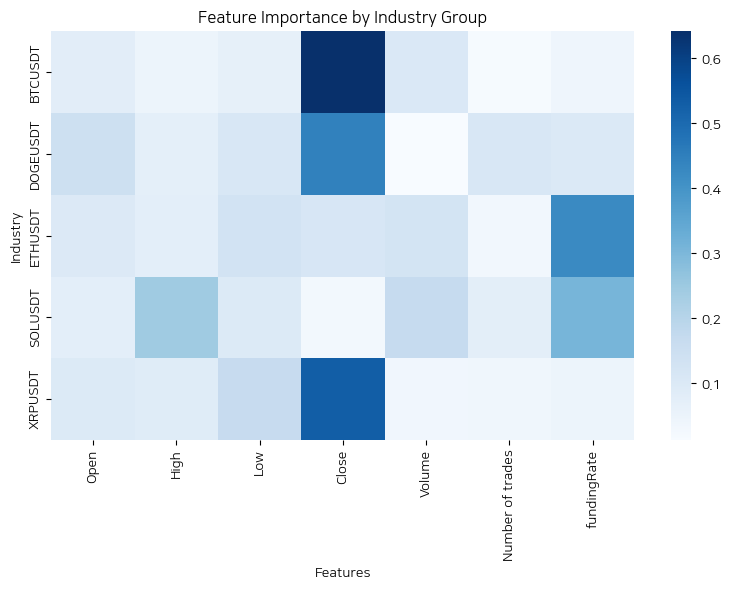

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 5/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 16, 'seq_length': 42}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121108~2026030100 자료 추출 중 : 1200
test set : 2026020808~2026041200 자료 추출 중 : 945
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.123884 | val_loss=0.138373 | test_loss=0.091266 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/5_2605160741_D32_H64_N16_SEQ42/tft_best.pt
***[TFT Epoch:002] train_loss=0.119251 | val_loss=0.141428 | test_loss=0.091096 | lr=4.53e-04***
***[TFT Epoch:003] train_loss=0.120146 | val_loss=0.166038 | test_loss=0.118431 | lr=3.99e-04***
***[TFT Epoch:004] train_loss=0.111589 | val_loss=0.149415 | test_loss=0.129774 | lr=3.31e-04***
***[TFT Epoch:005] train_loss=0.108474 | val_loss=0.143818 | test

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


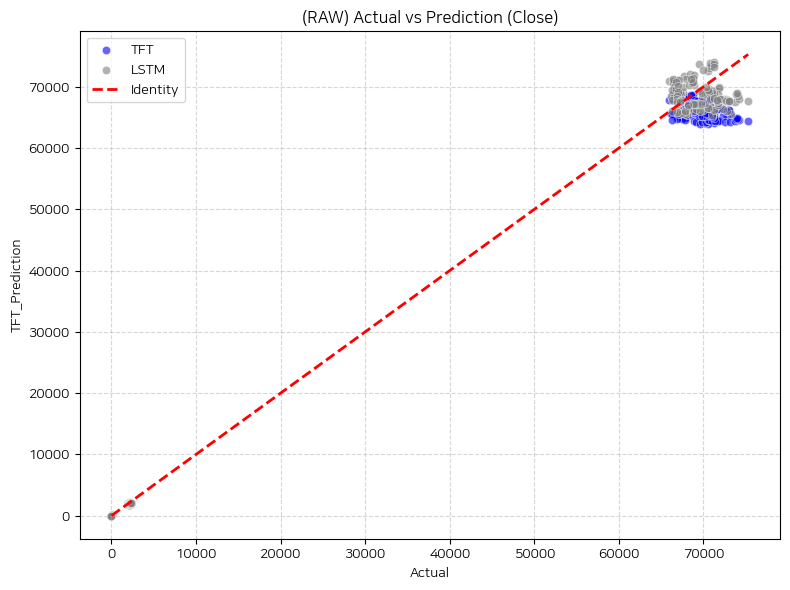

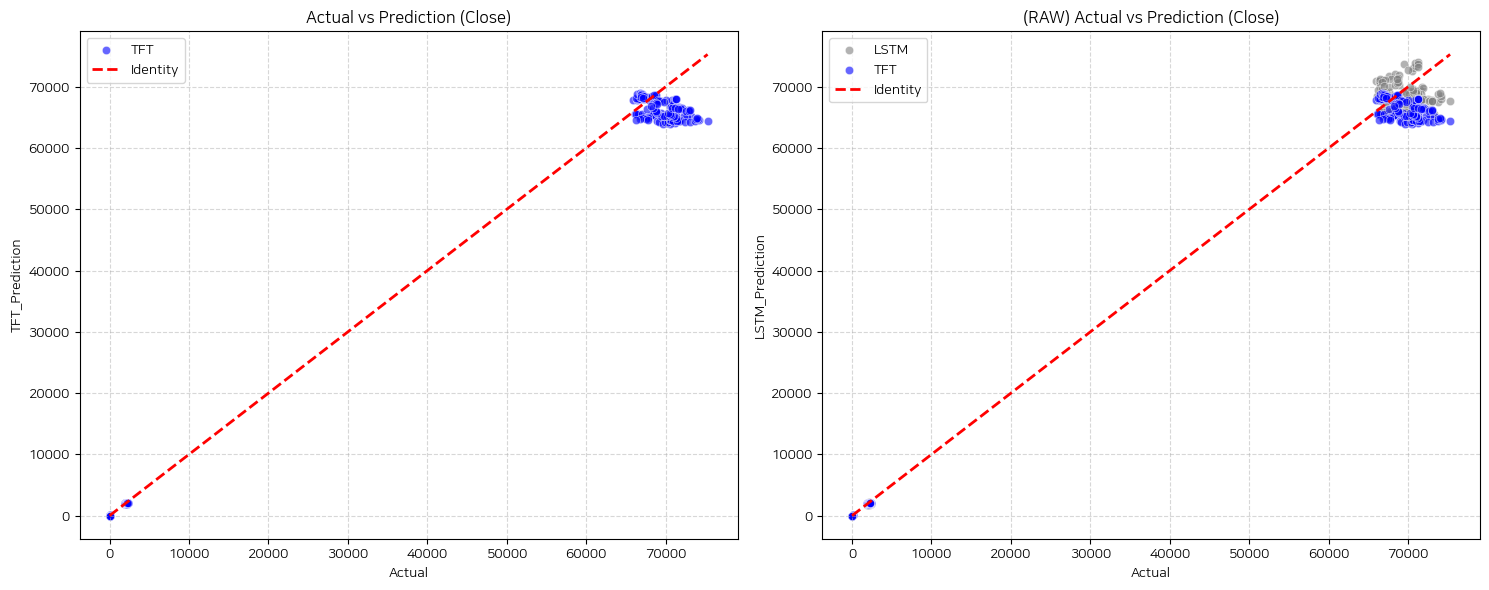

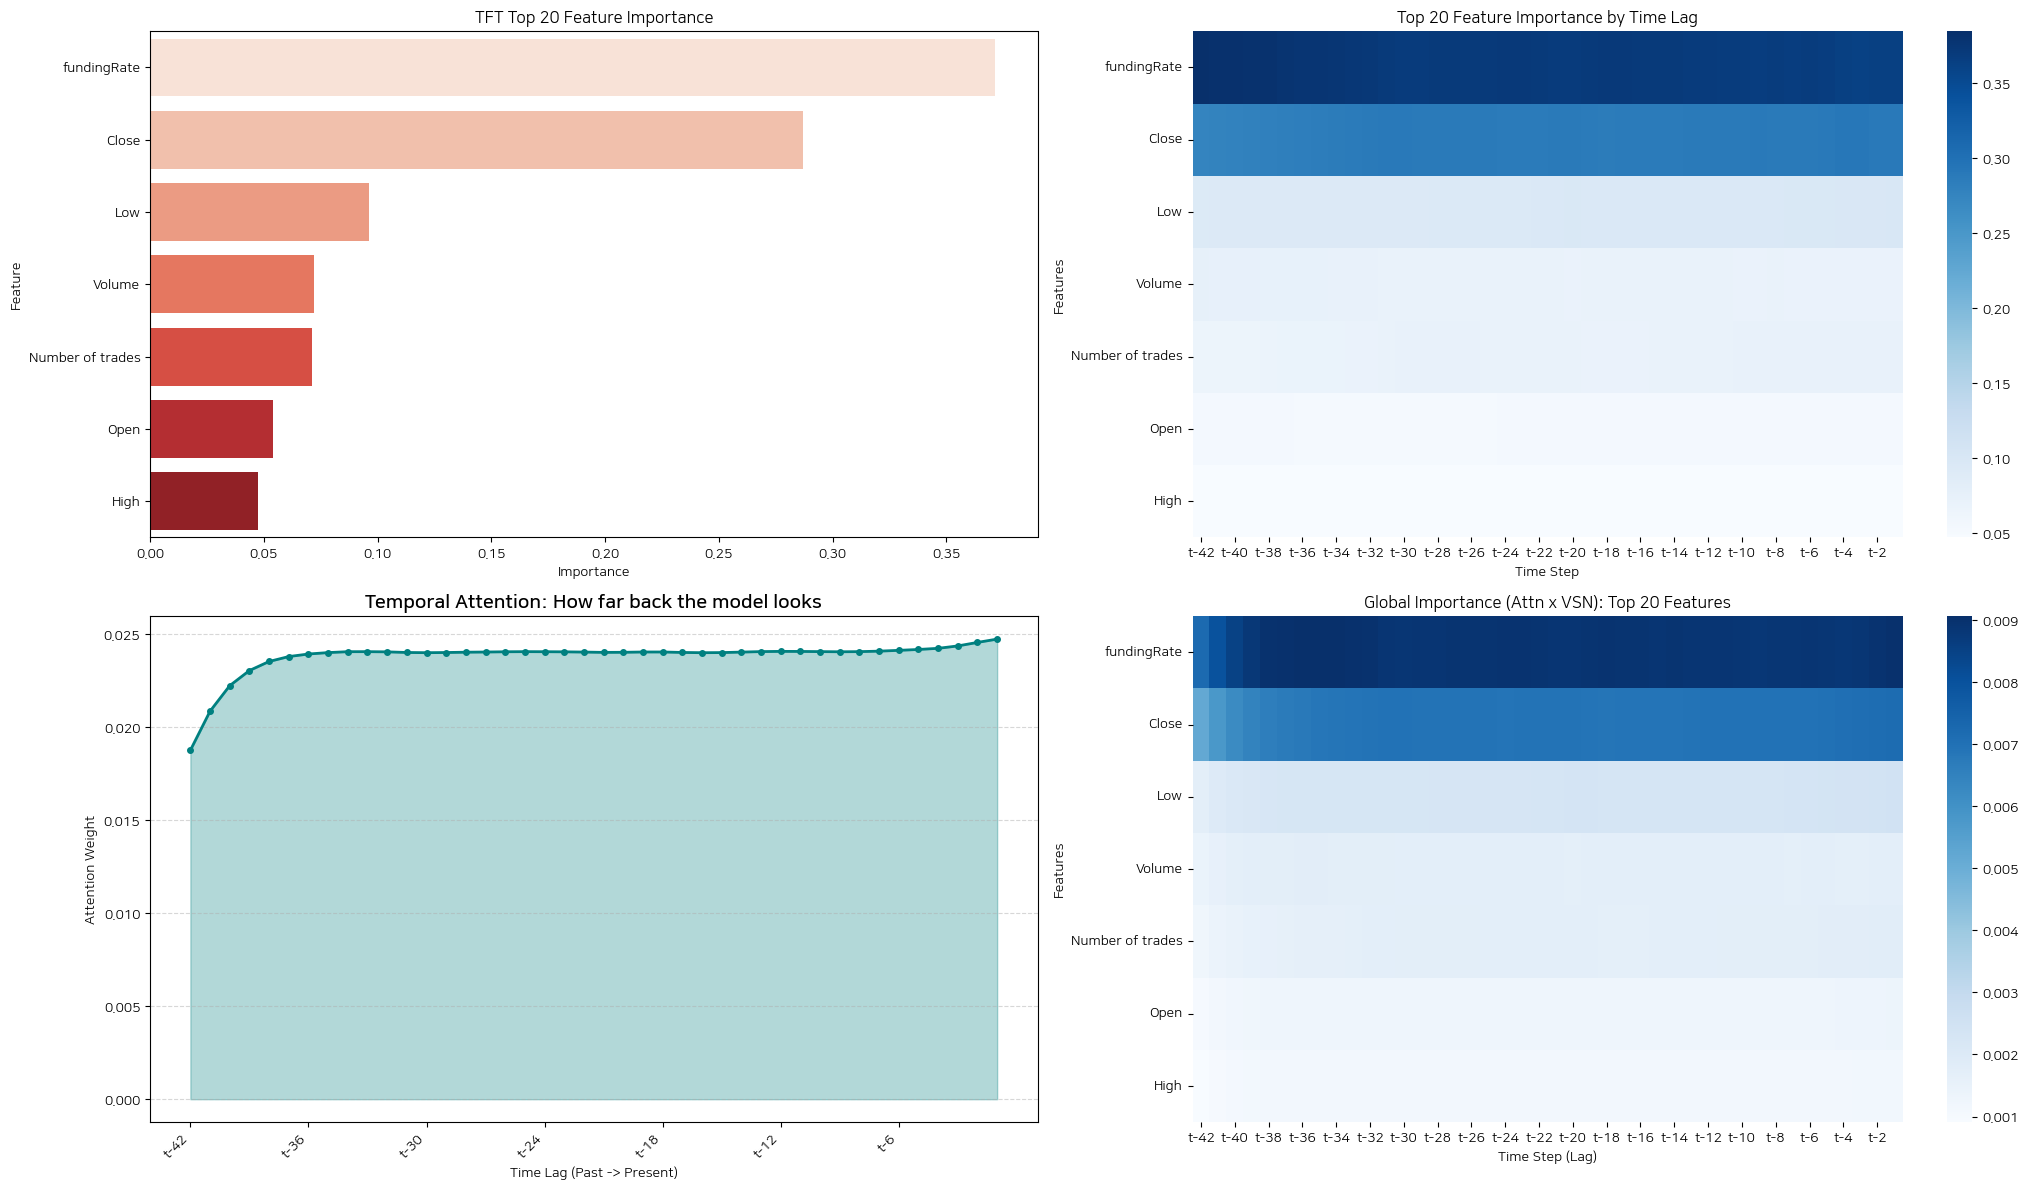

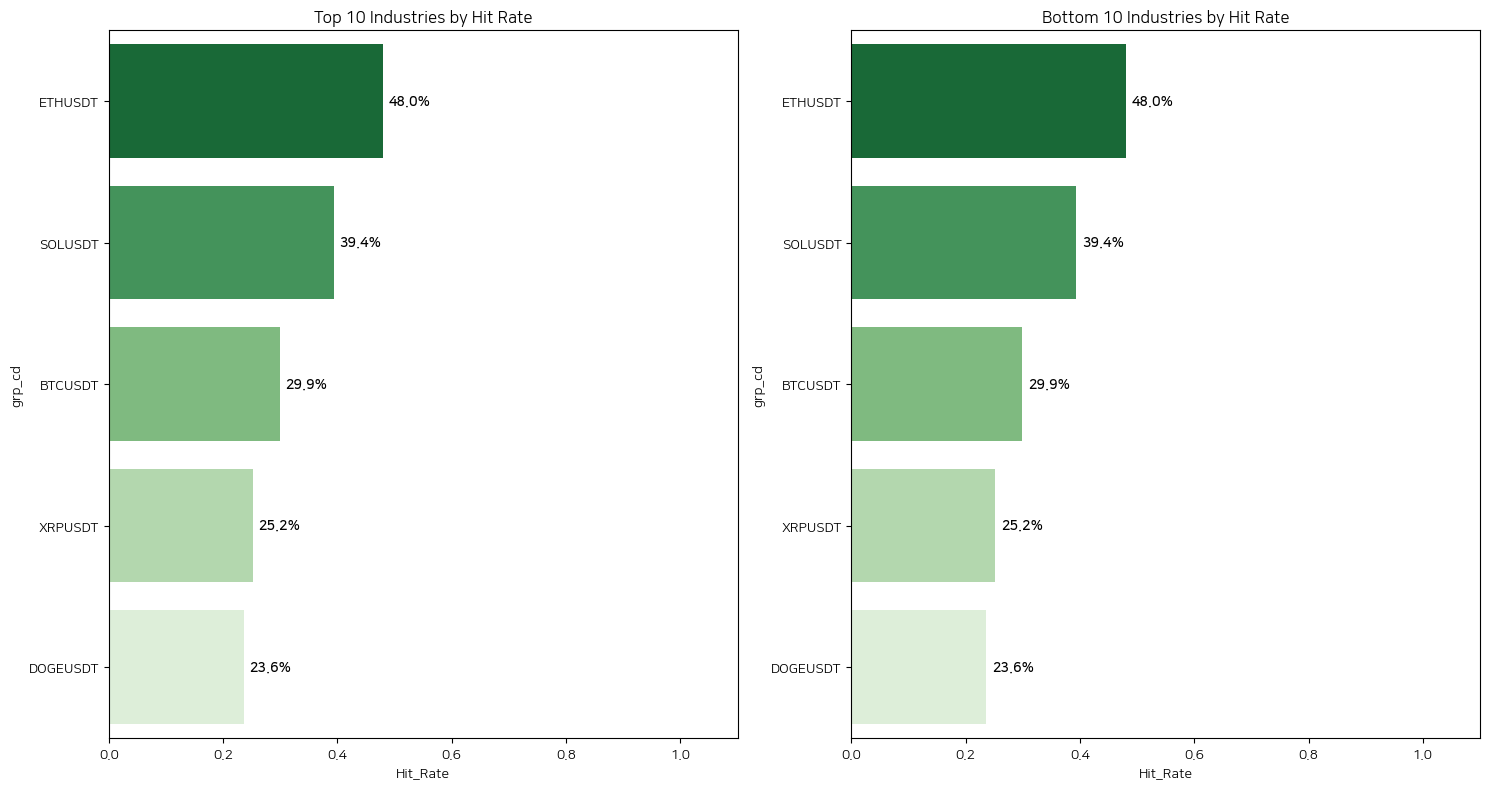

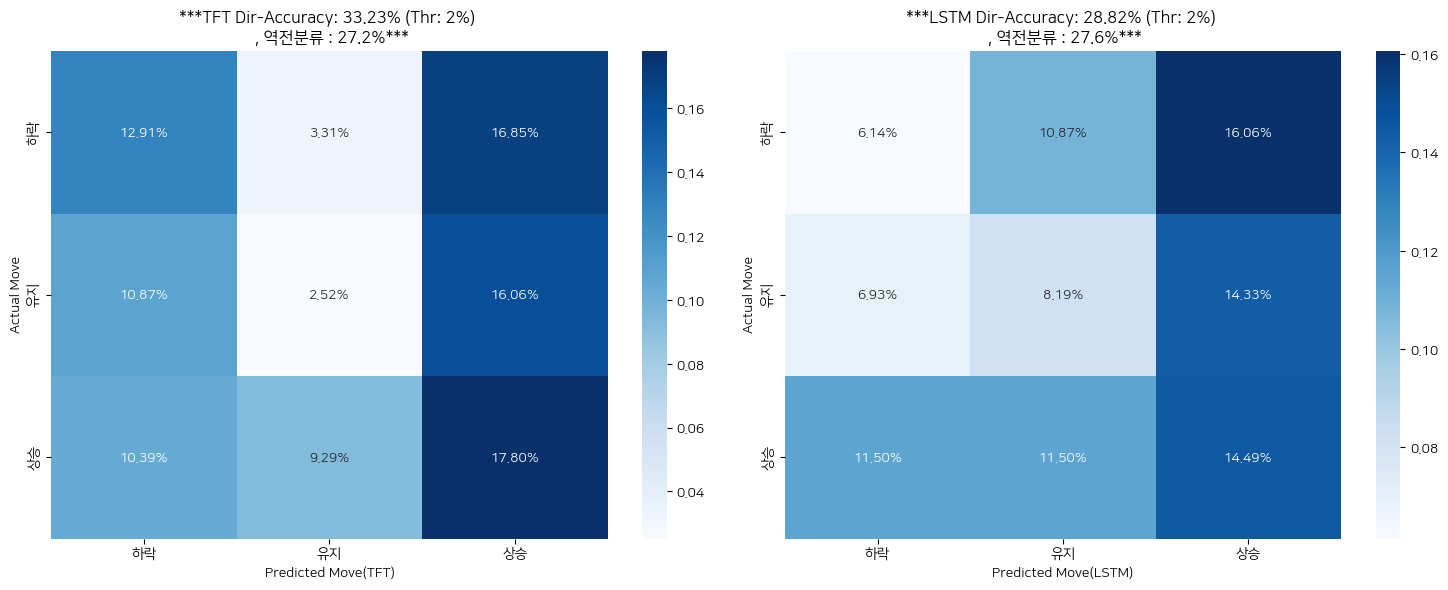

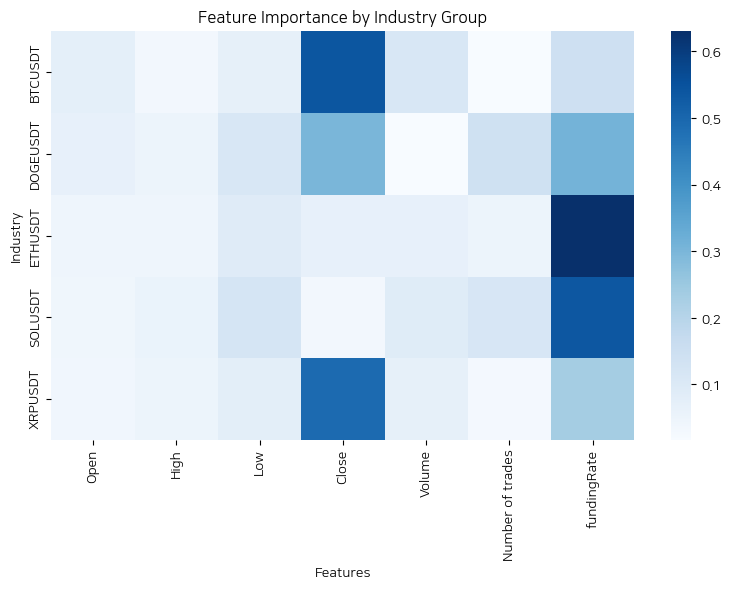

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 6/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 16, 'seq_length': 63}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025120408~2026030100 자료 추출 중 : 1305
test set : 2026020108~2026041200 자료 추출 중 : 1050
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.132050 | val_loss=0.160492 | test_loss=0.100875 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/6_2605160743_D32_H64_N16_SEQ63/tft_best.pt
***[TFT Epoch:002] train_loss=0.129809 | val_loss=0.163551 | test_loss=0.106824 | lr=4.53e-04***
***[TFT Epoch:003] train_loss=0.119862 | val_loss=0.150945 | test_loss=0.110774 | lr=3.99e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/6_2605160743_D32_H64_N16_SEQ63/tft_best.pt
***[TFT Epoch:004] train_loss=

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


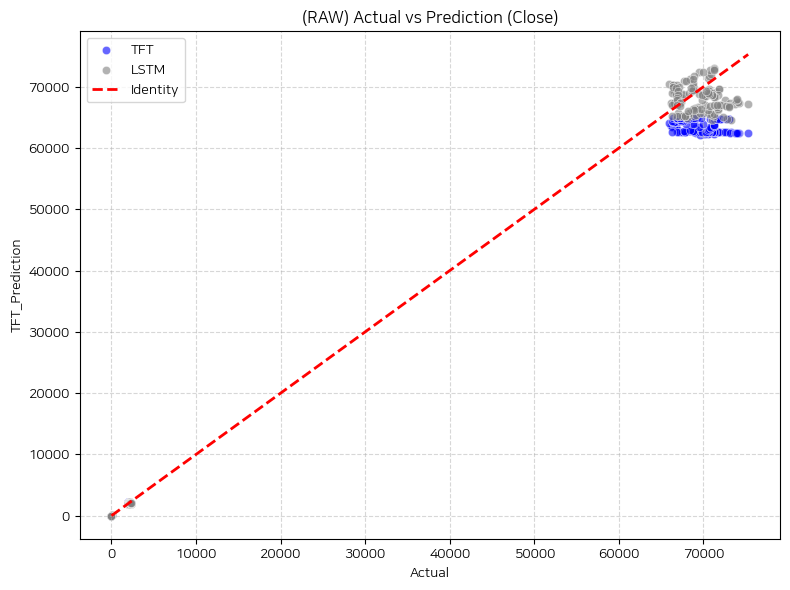

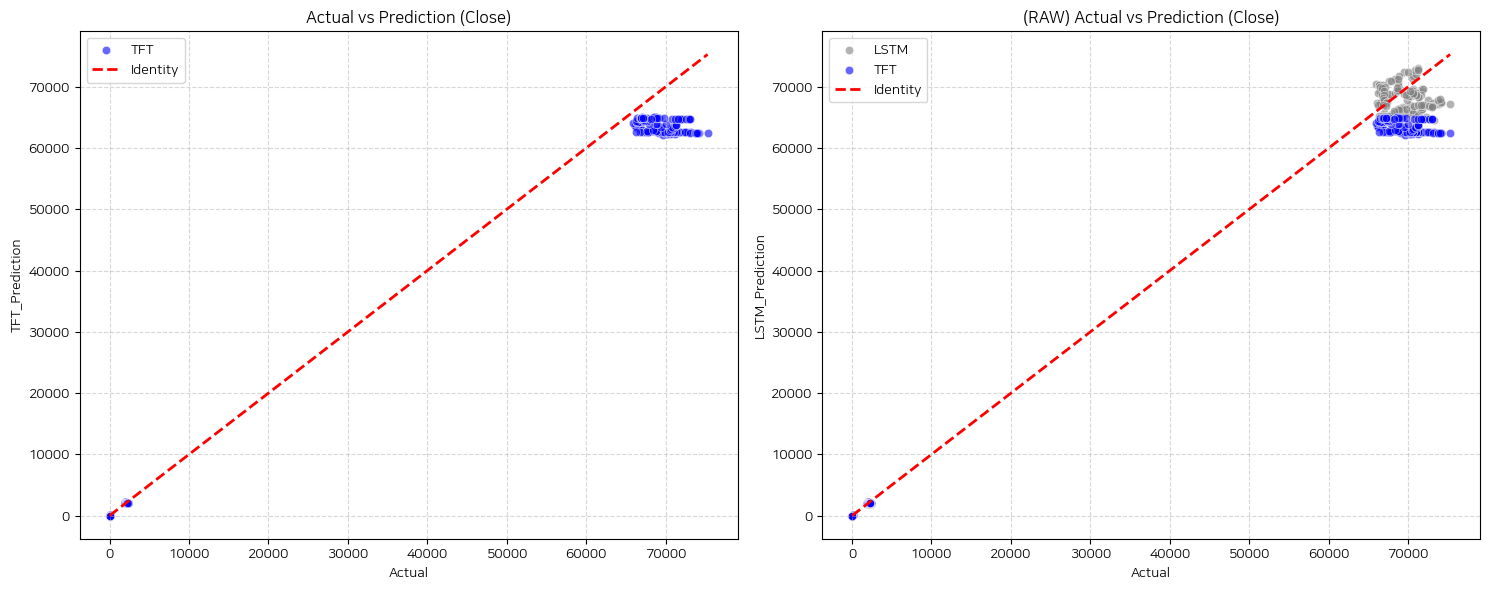

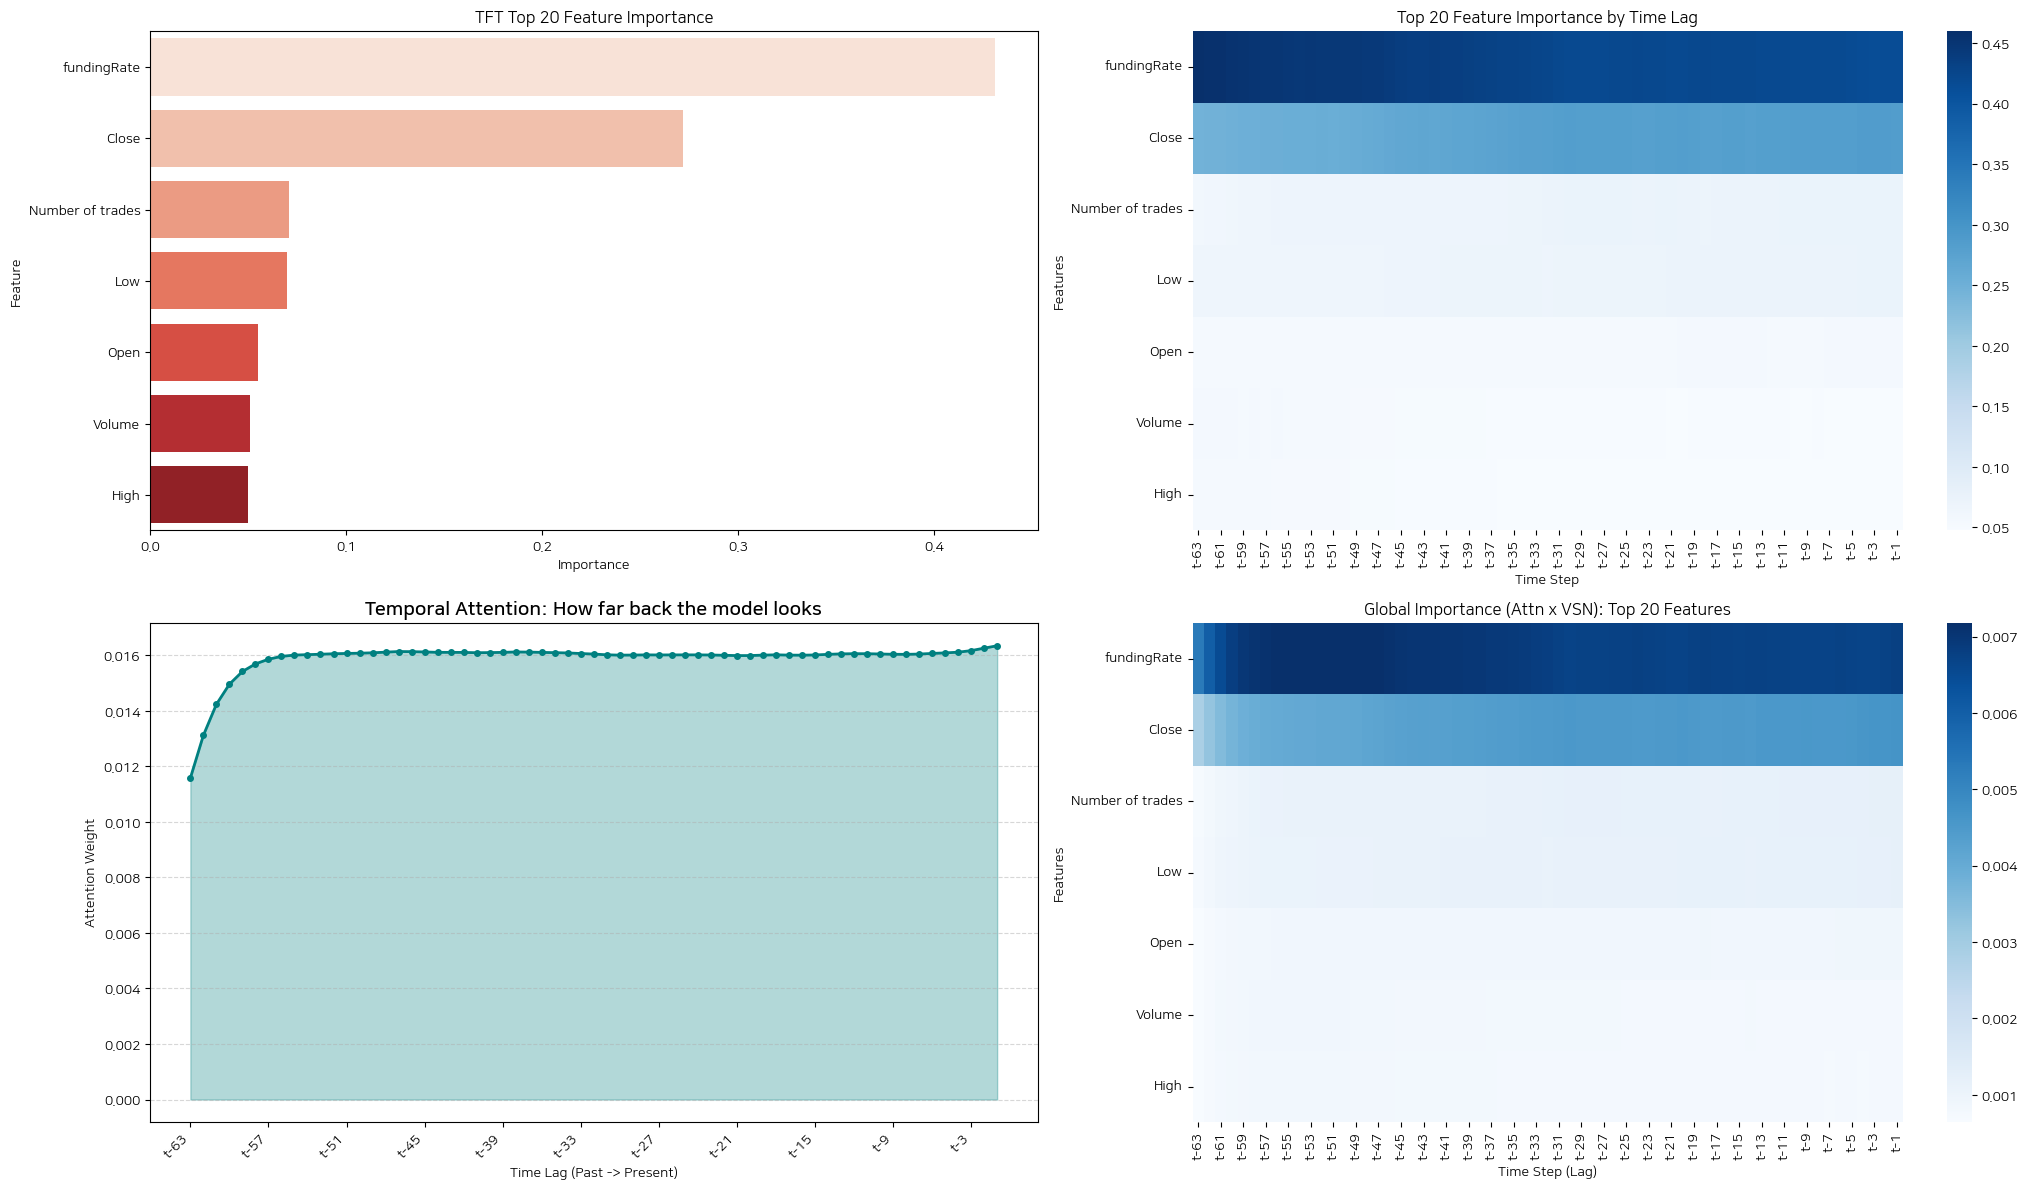

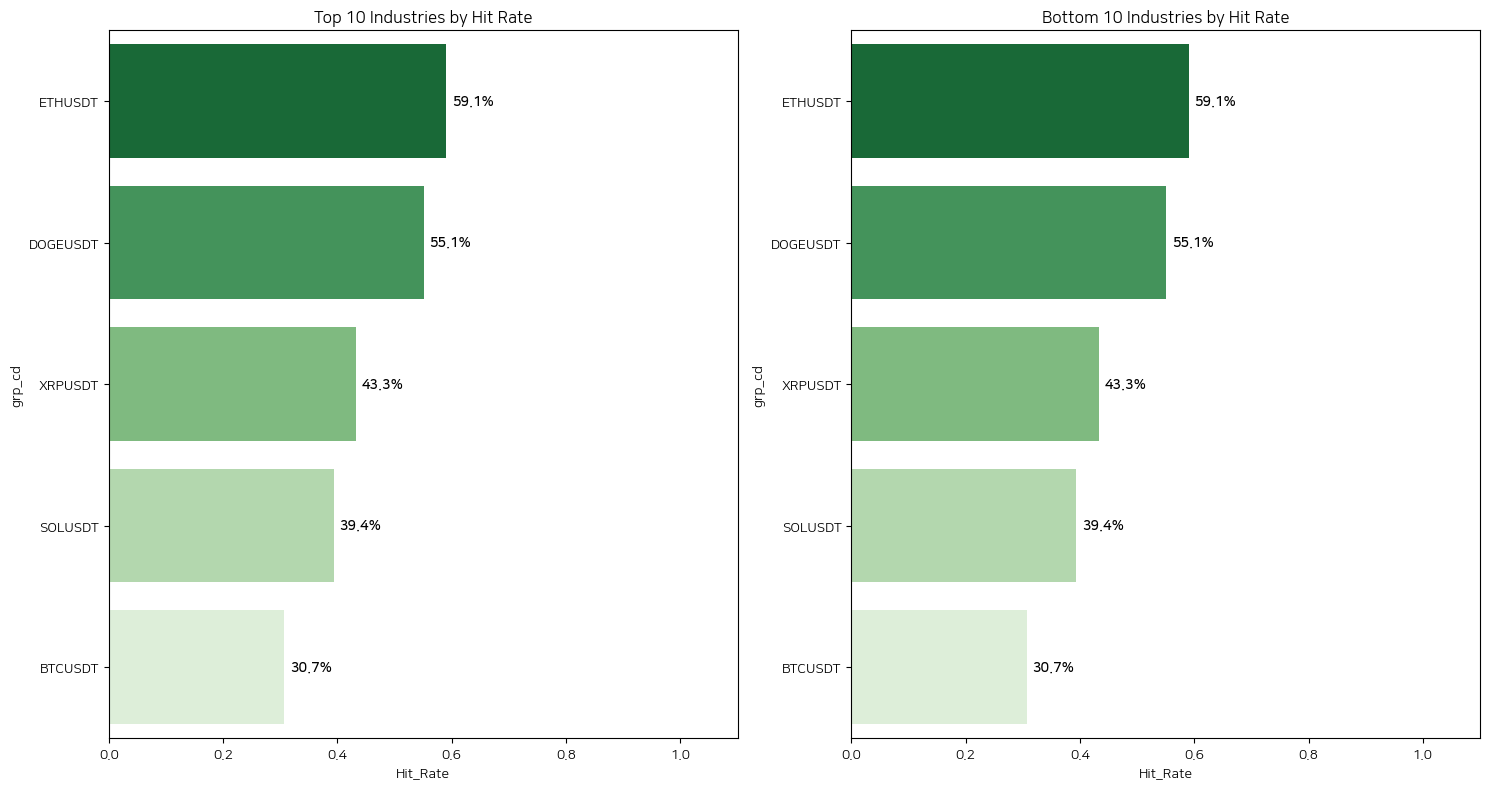

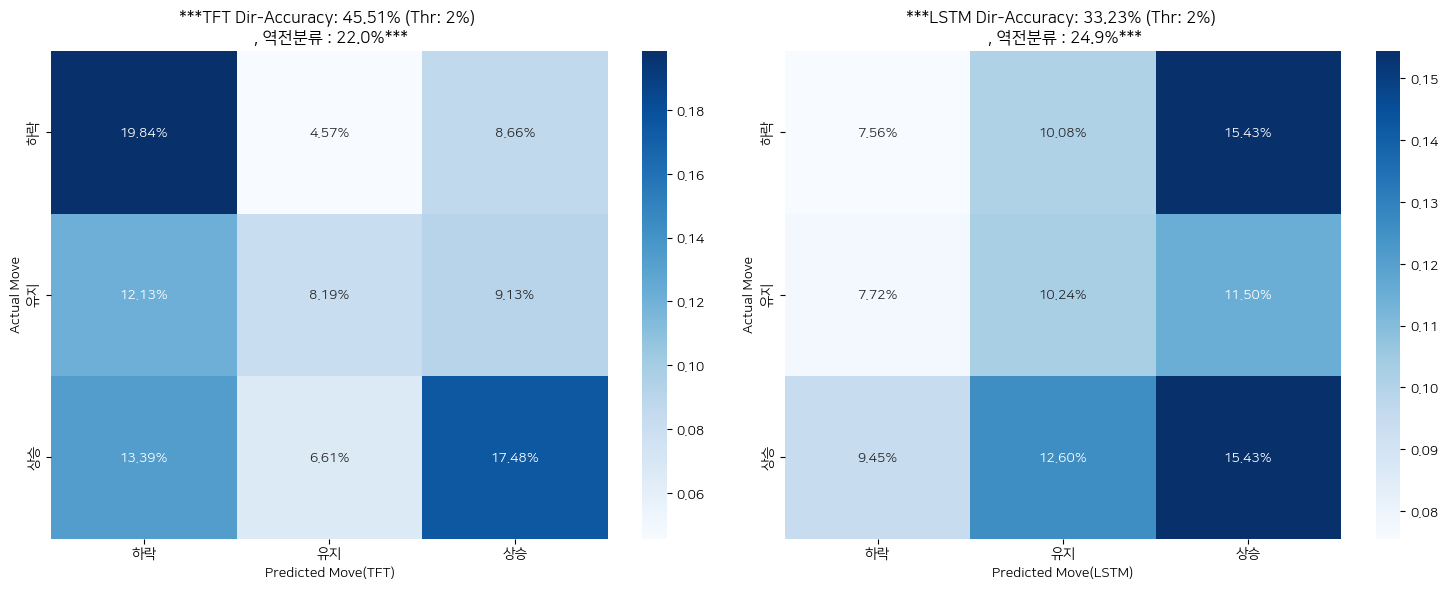

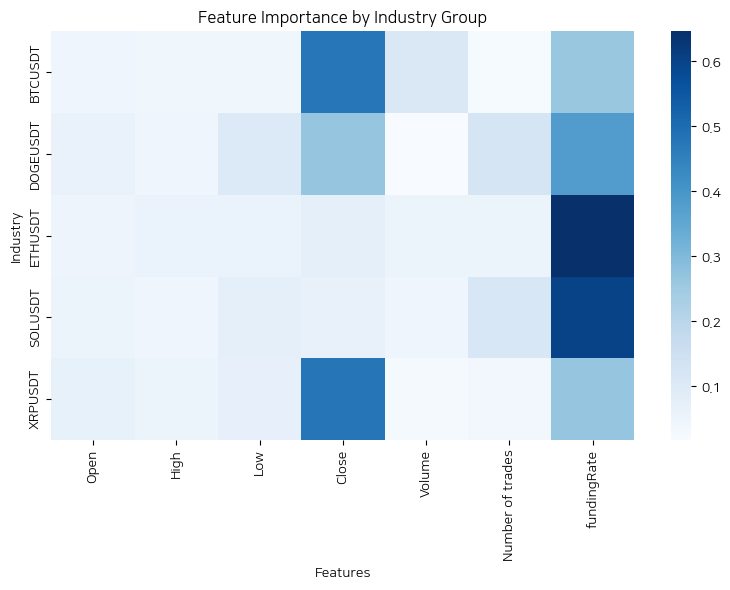

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 7/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 32, 'seq_length': 21}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121808~2026030100 자료 추출 중 : 1095
test set : 2026021508~2026041200 자료 추출 중 : 840
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.115321 | val_loss=0.119922 | test_loss=0.090782 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/7_2605160745_D32_H64_N32_SEQ21/tft_best.pt
***[TFT Epoch:002] train_loss=0.110359 | val_loss=0.112386 | test_loss=0.084832 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/7_2605160745_D32_H64_N32_SEQ21/tft_best.pt
***[TFT Epoch:003] train_loss=0.112801 | val_loss=0.104552 | test_loss=0.086808 | lr=3.99e-04***
 -> saved best to /content/driv

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


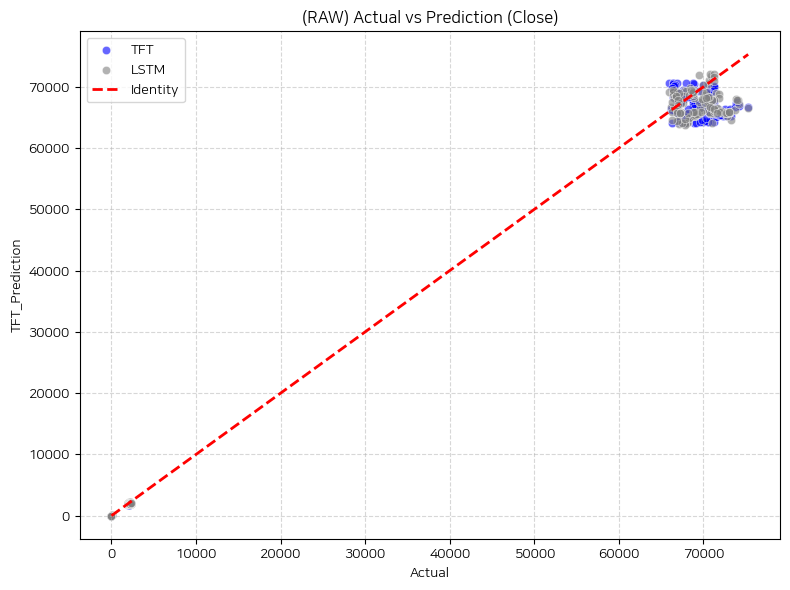

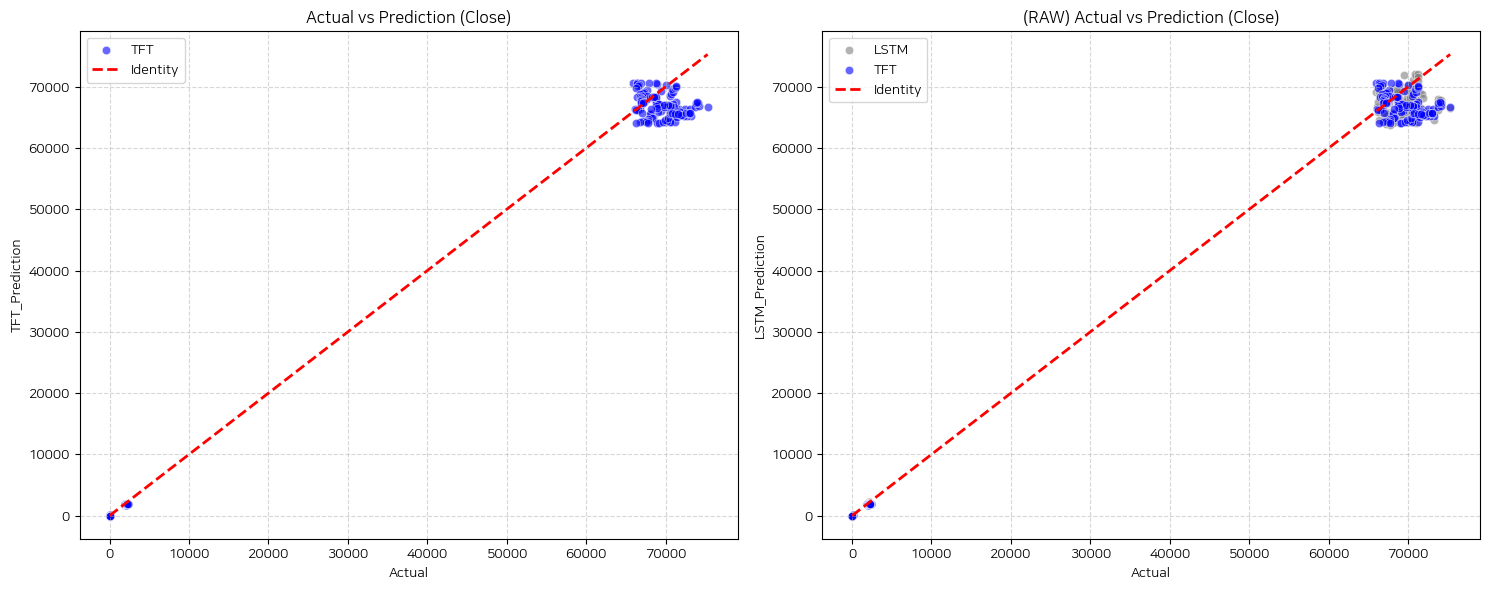

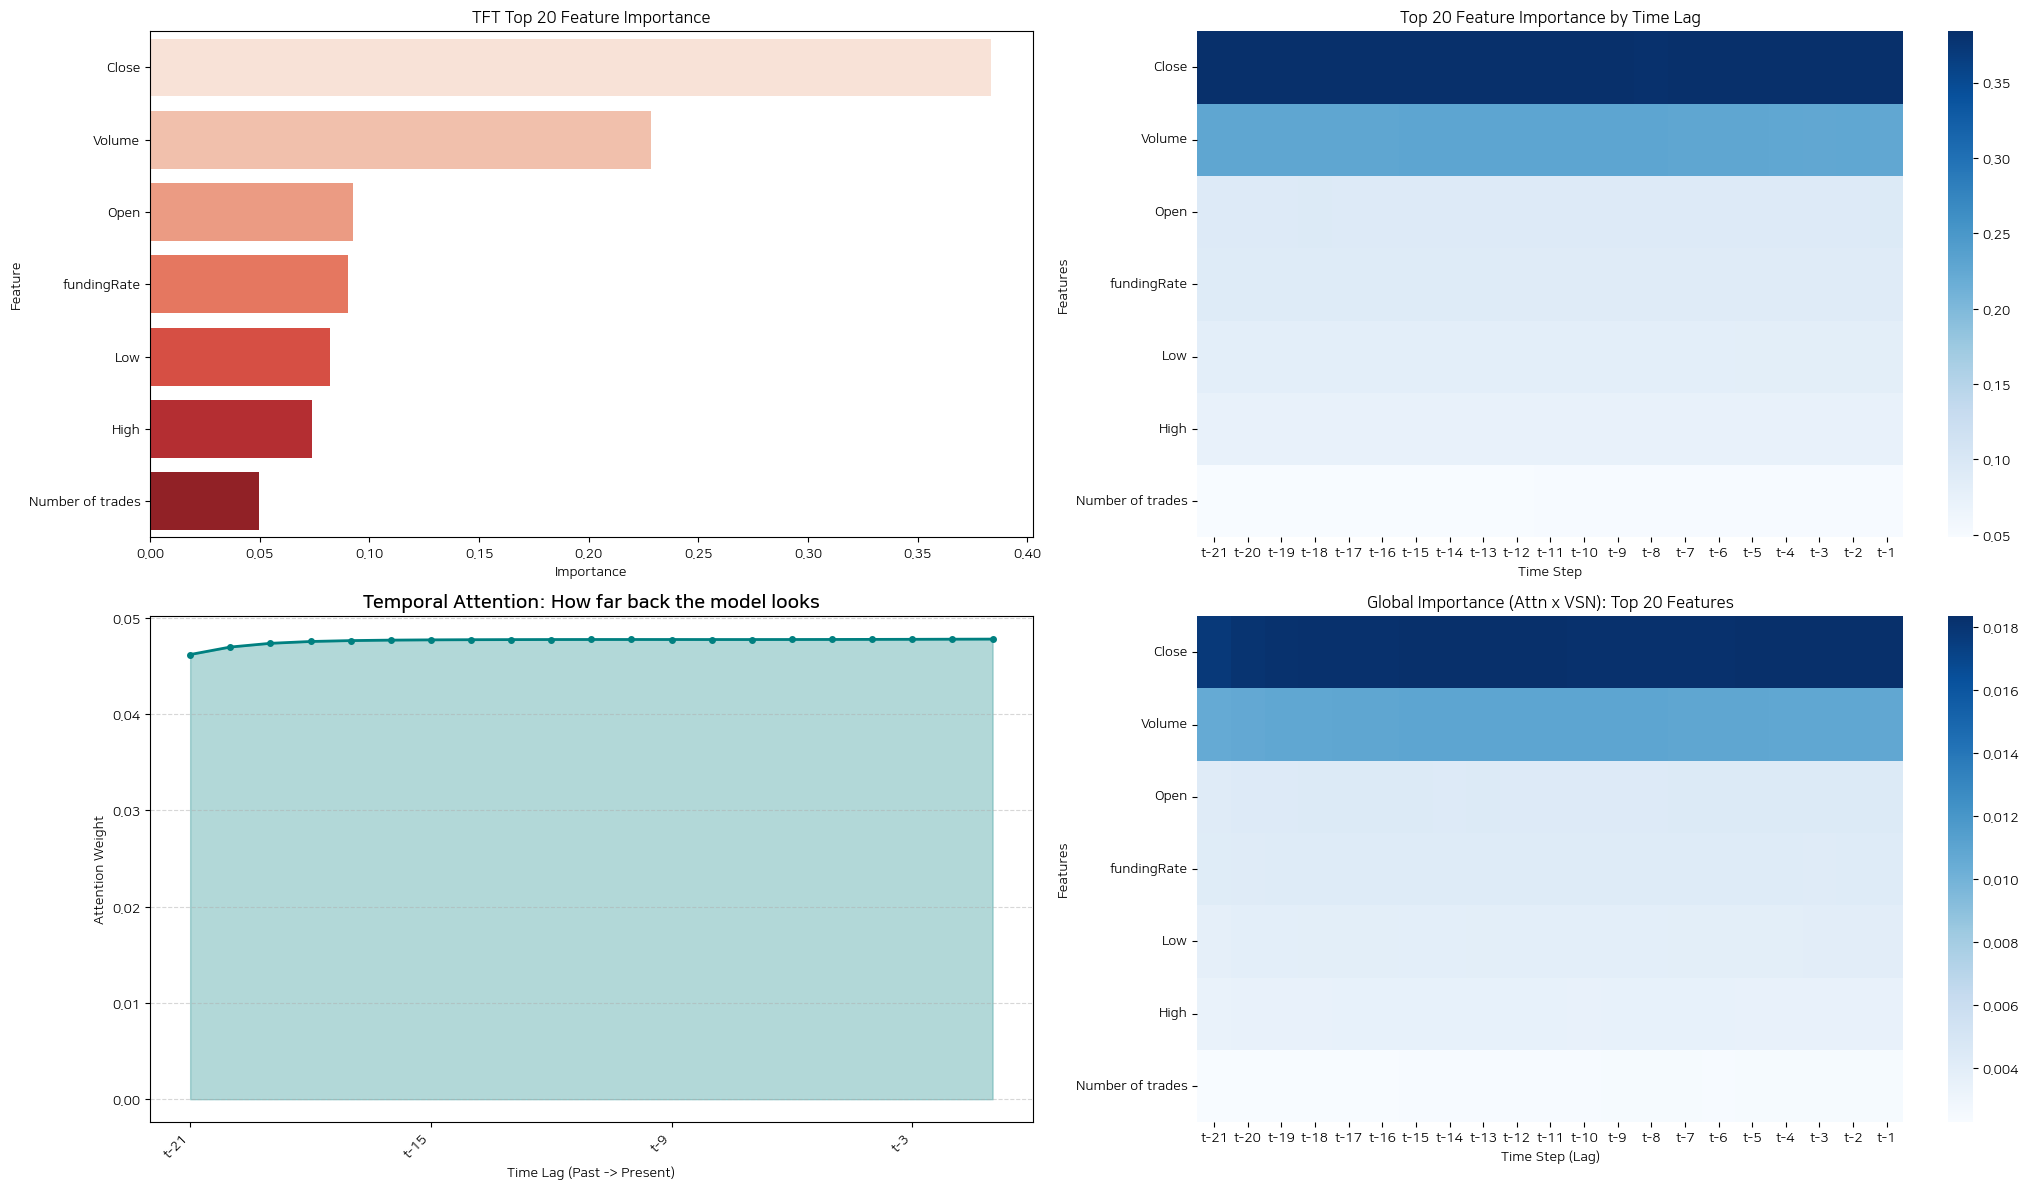

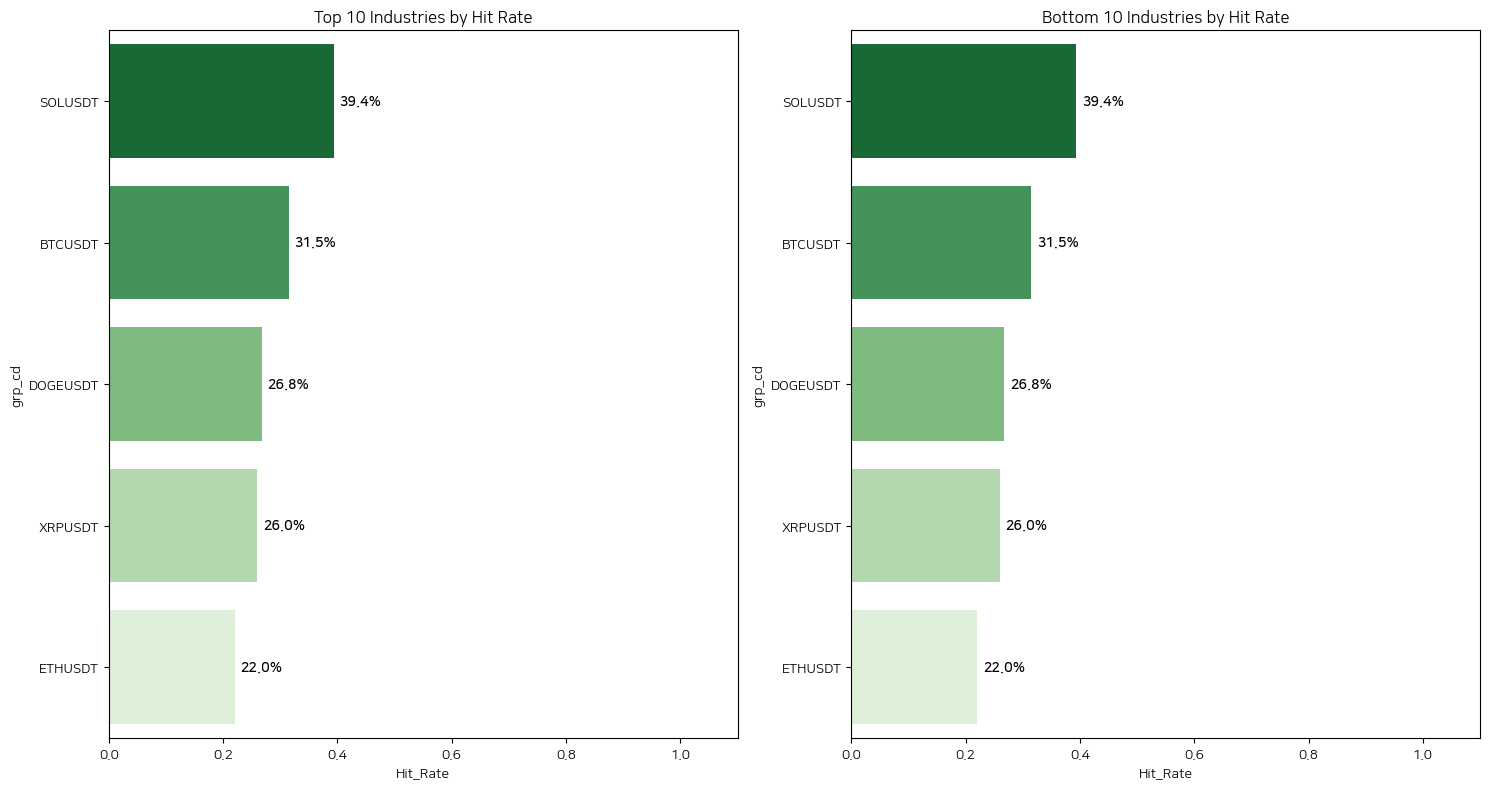

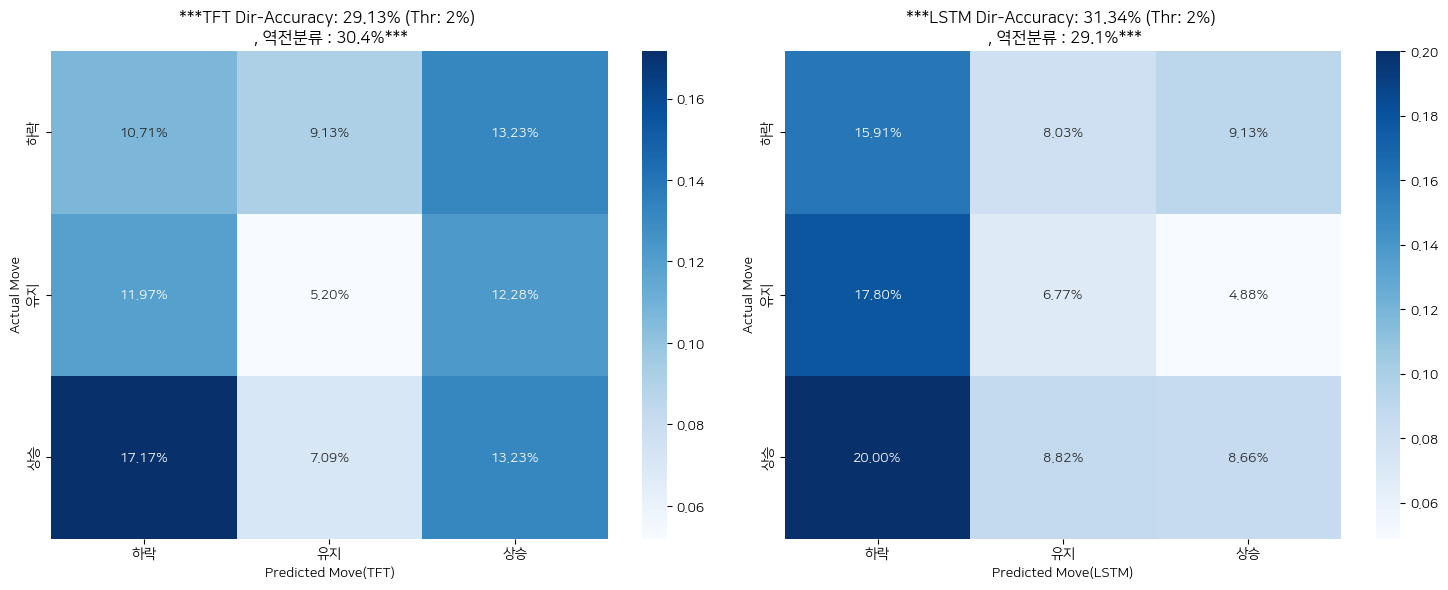

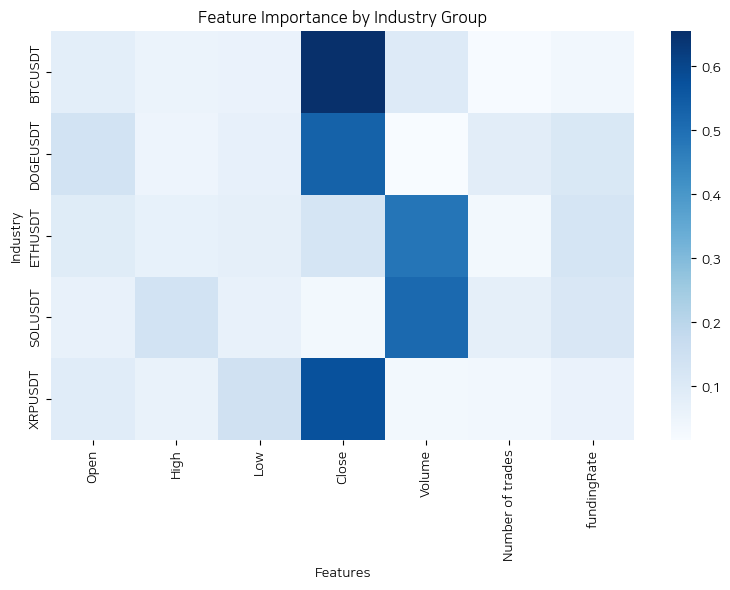

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 8/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 32, 'seq_length': 42}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121108~2026030100 자료 추출 중 : 1200
test set : 2026020808~2026041200 자료 추출 중 : 945
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.123277 | val_loss=0.141558 | test_loss=0.093126 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/8_2605160747_D32_H64_N32_SEQ42/tft_best.pt
***[TFT Epoch:002] train_loss=0.119571 | val_loss=0.141740 | test_loss=0.091267 | lr=4.53e-04***
***[TFT Epoch:003] train_loss=0.120617 | val_loss=0.162552 | test_loss=0.114815 | lr=3.99e-04***
***[TFT Epoch:004] train_loss=0.111997 | val_loss=0.144384 | test_loss=0.121560 | lr=3.31e-04***
***[TFT Epoch:005] train_loss=0.109423 | val_loss=0.147155 | test

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


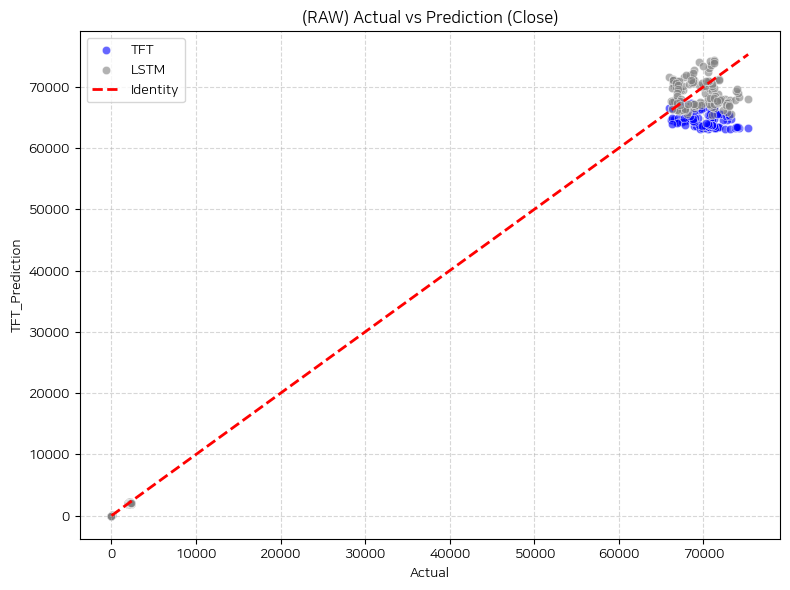

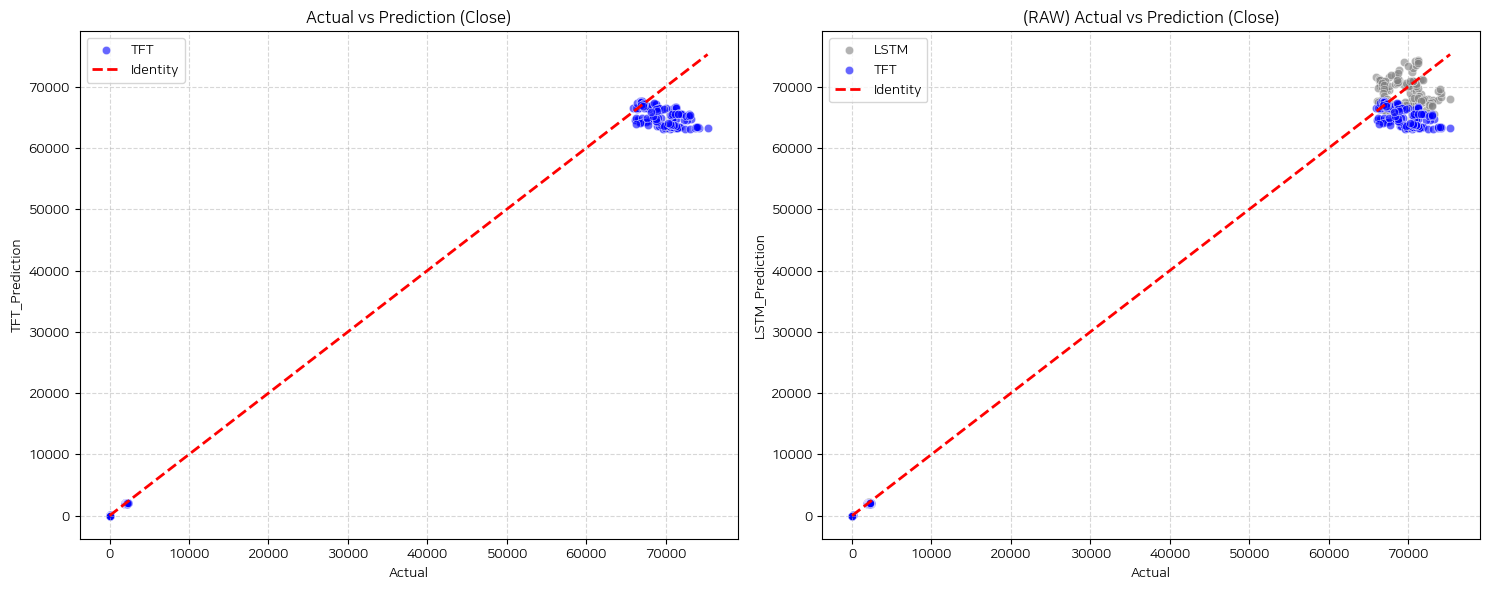

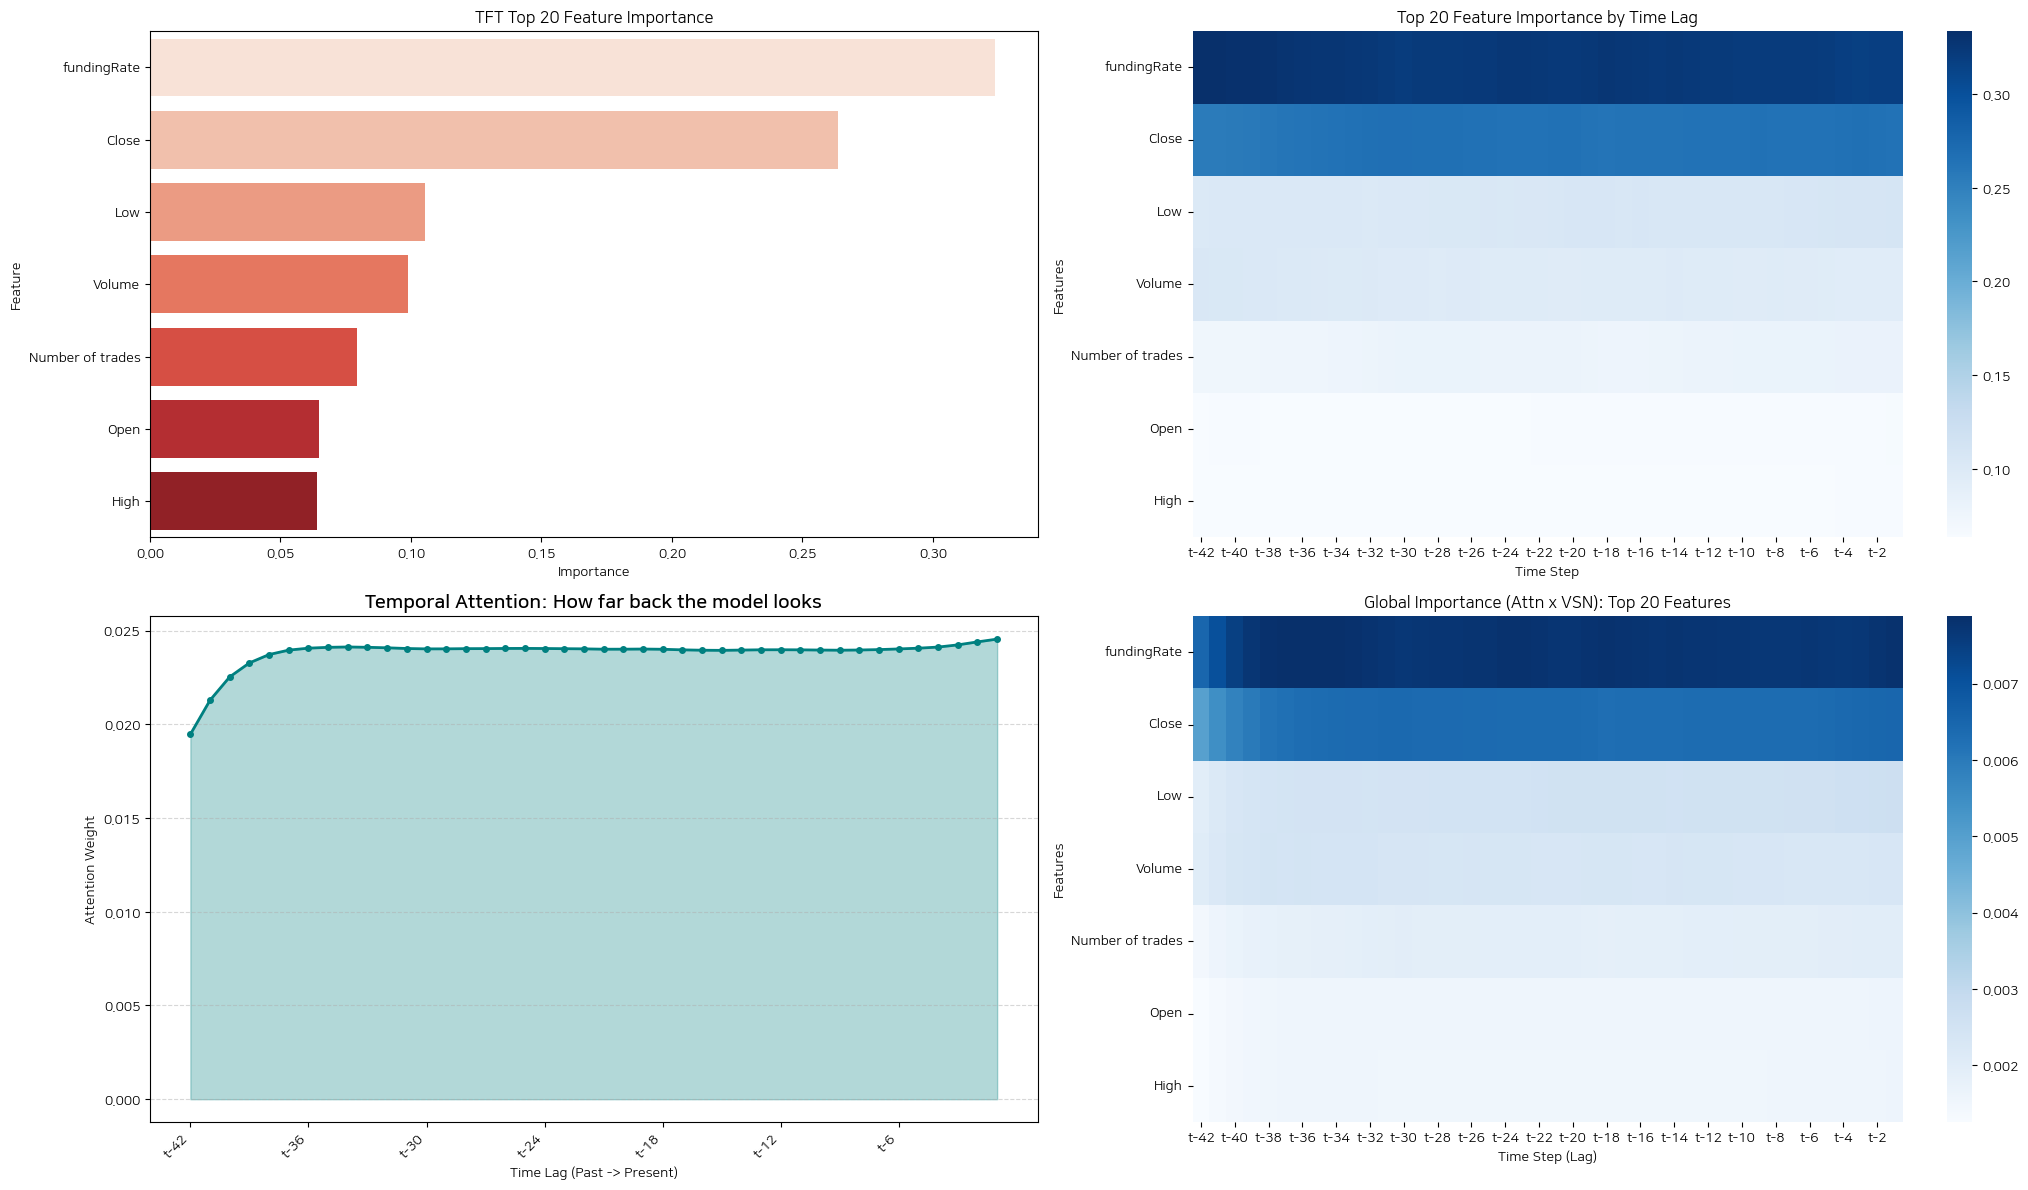

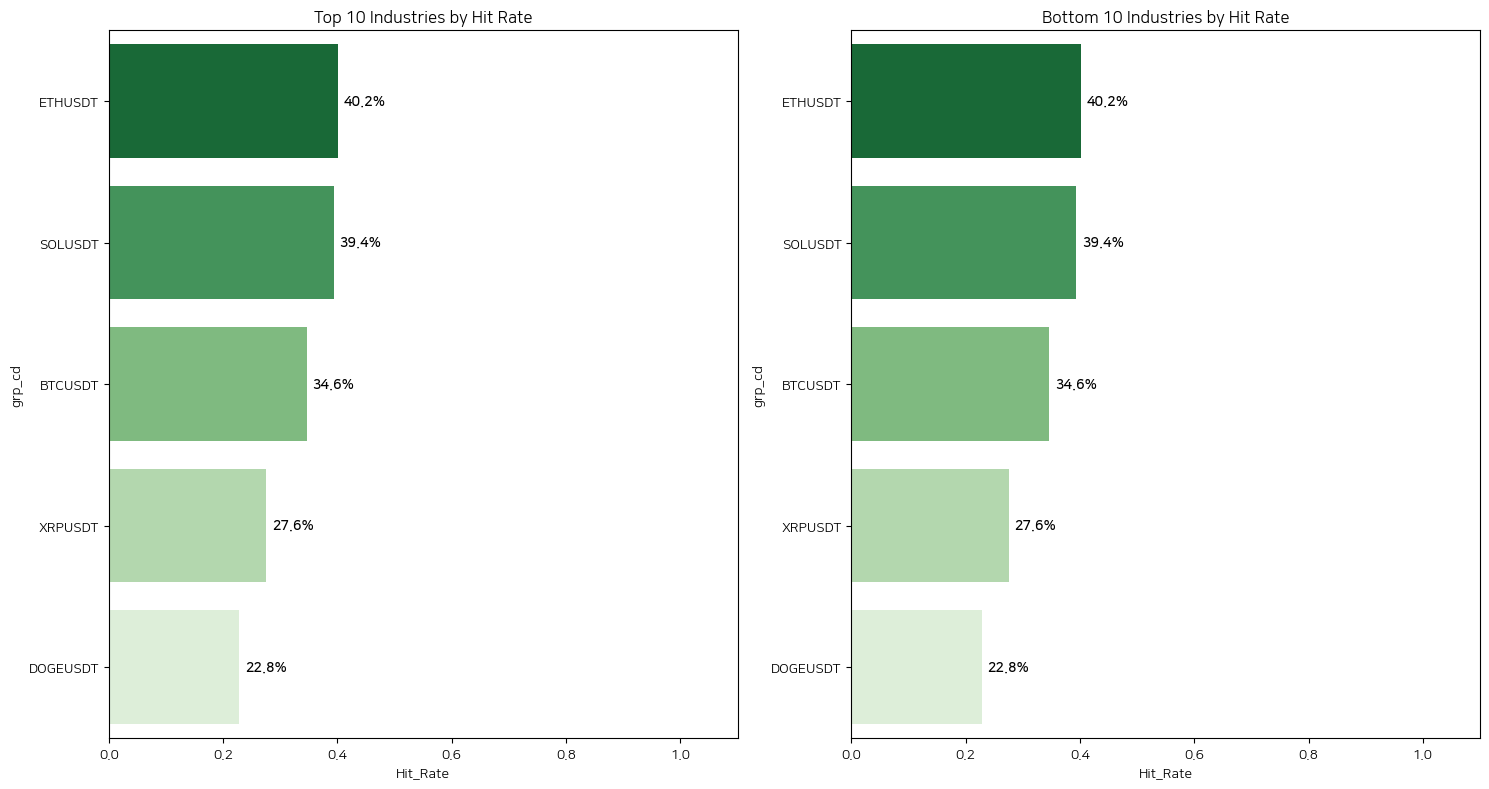

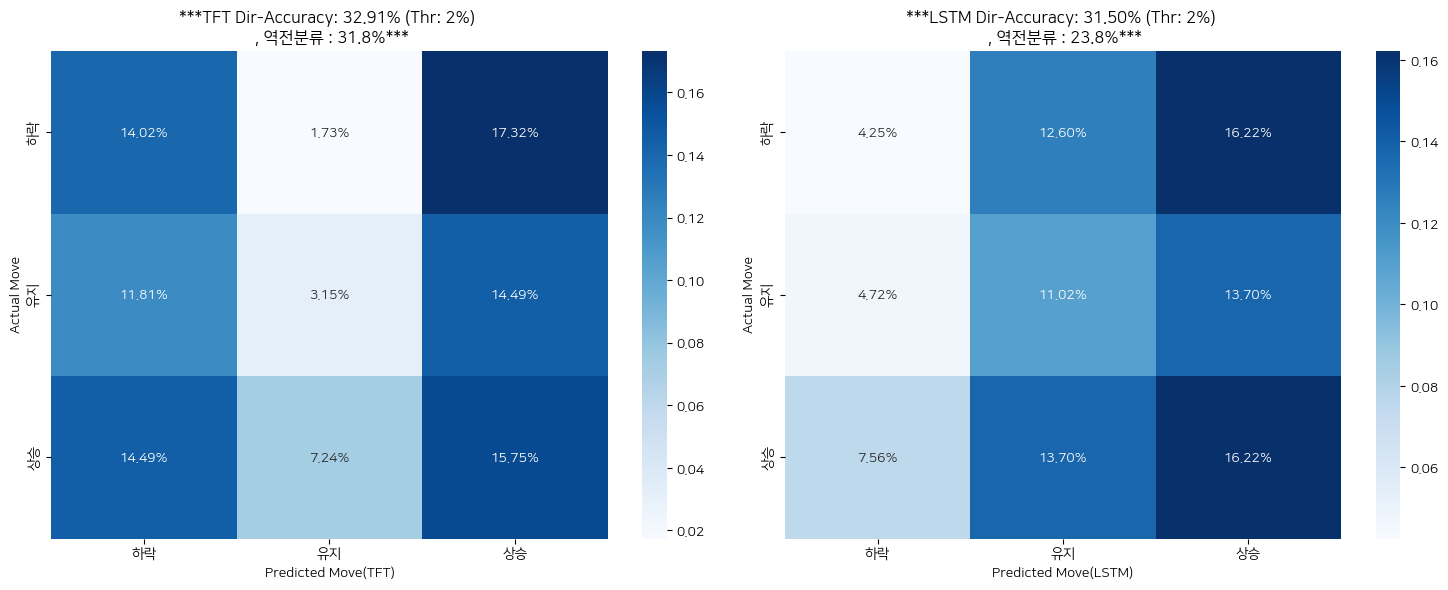

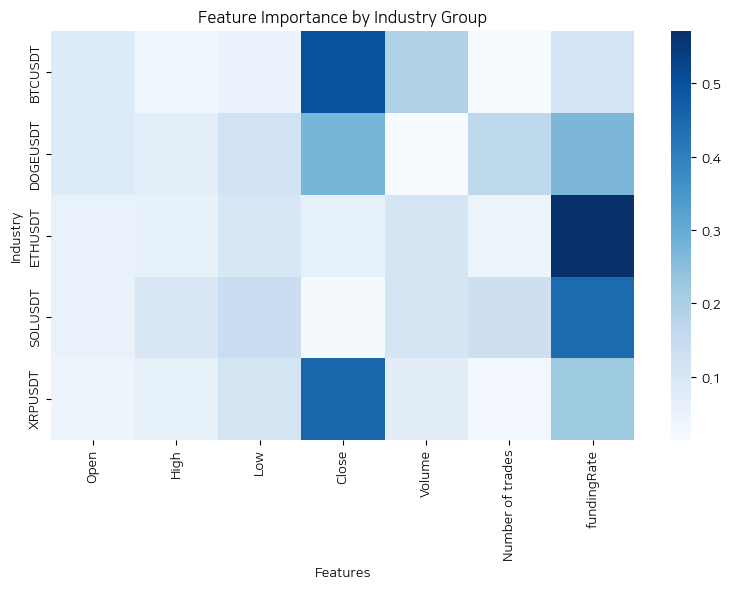

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 9/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 64, 'n_heads': 32, 'seq_length': 63}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025120408~2026030100 자료 추출 중 : 1305
test set : 2026020108~2026041200 자료 추출 중 : 1050
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.131979 | val_loss=0.160070 | test_loss=0.101040 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/9_2605160748_D32_H64_N32_SEQ63/tft_best.pt
***[TFT Epoch:002] train_loss=0.129318 | val_loss=0.159477 | test_loss=0.105715 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/9_2605160748_D32_H64_N32_SEQ63/tft_best.pt
***[TFT Epoch:003] train_loss=0.121320 | val_loss=0.153816 | test_loss=0.110971 | lr=3.99e-04***
 -> saved best to /content/dri

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


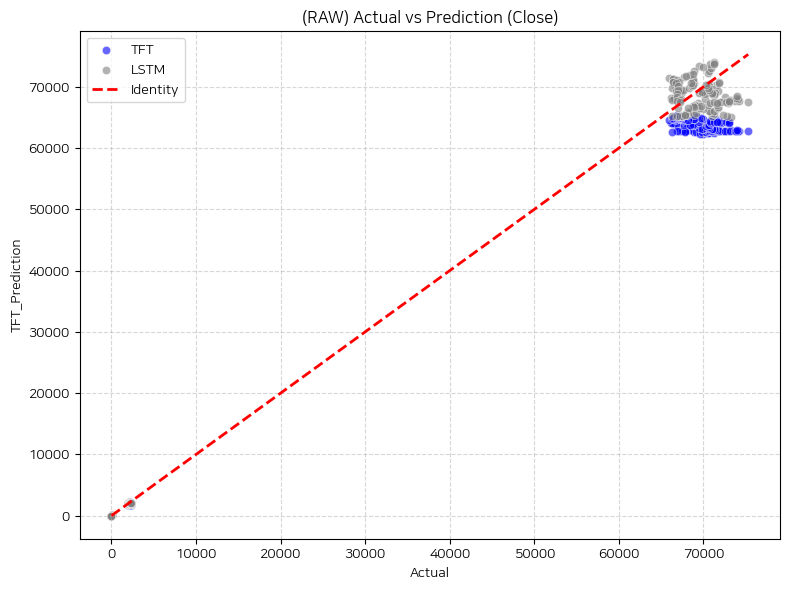

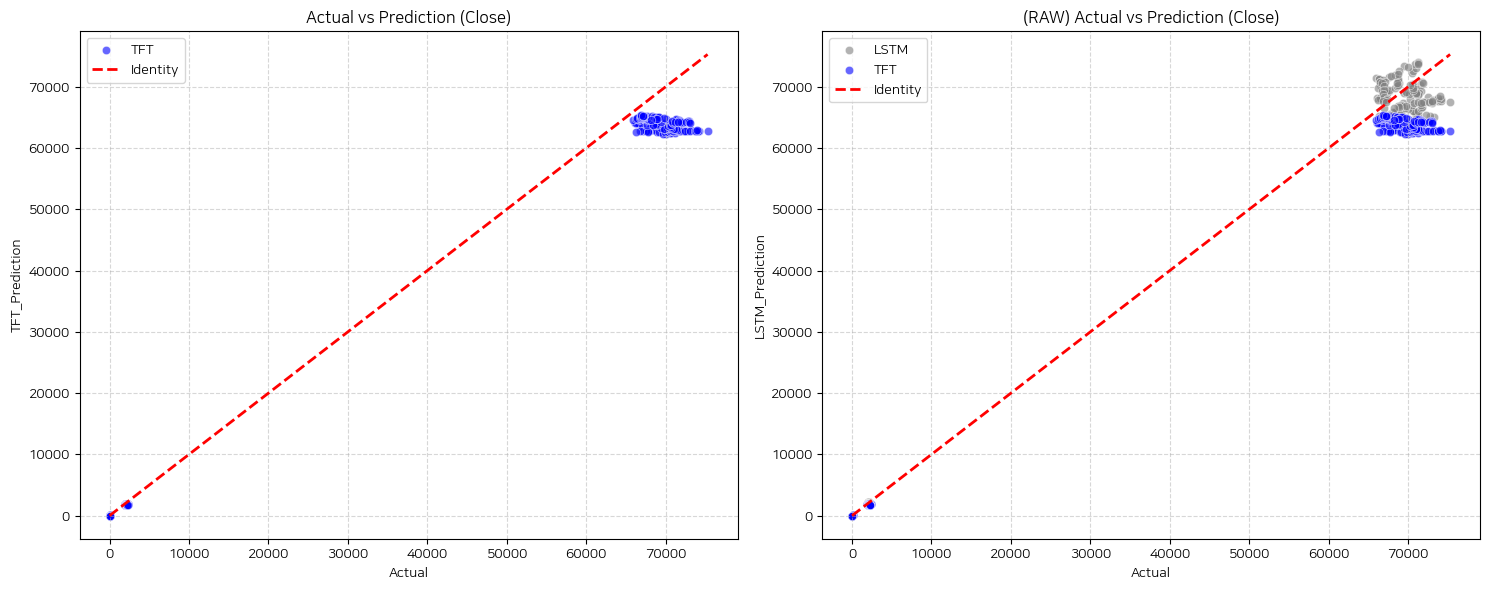

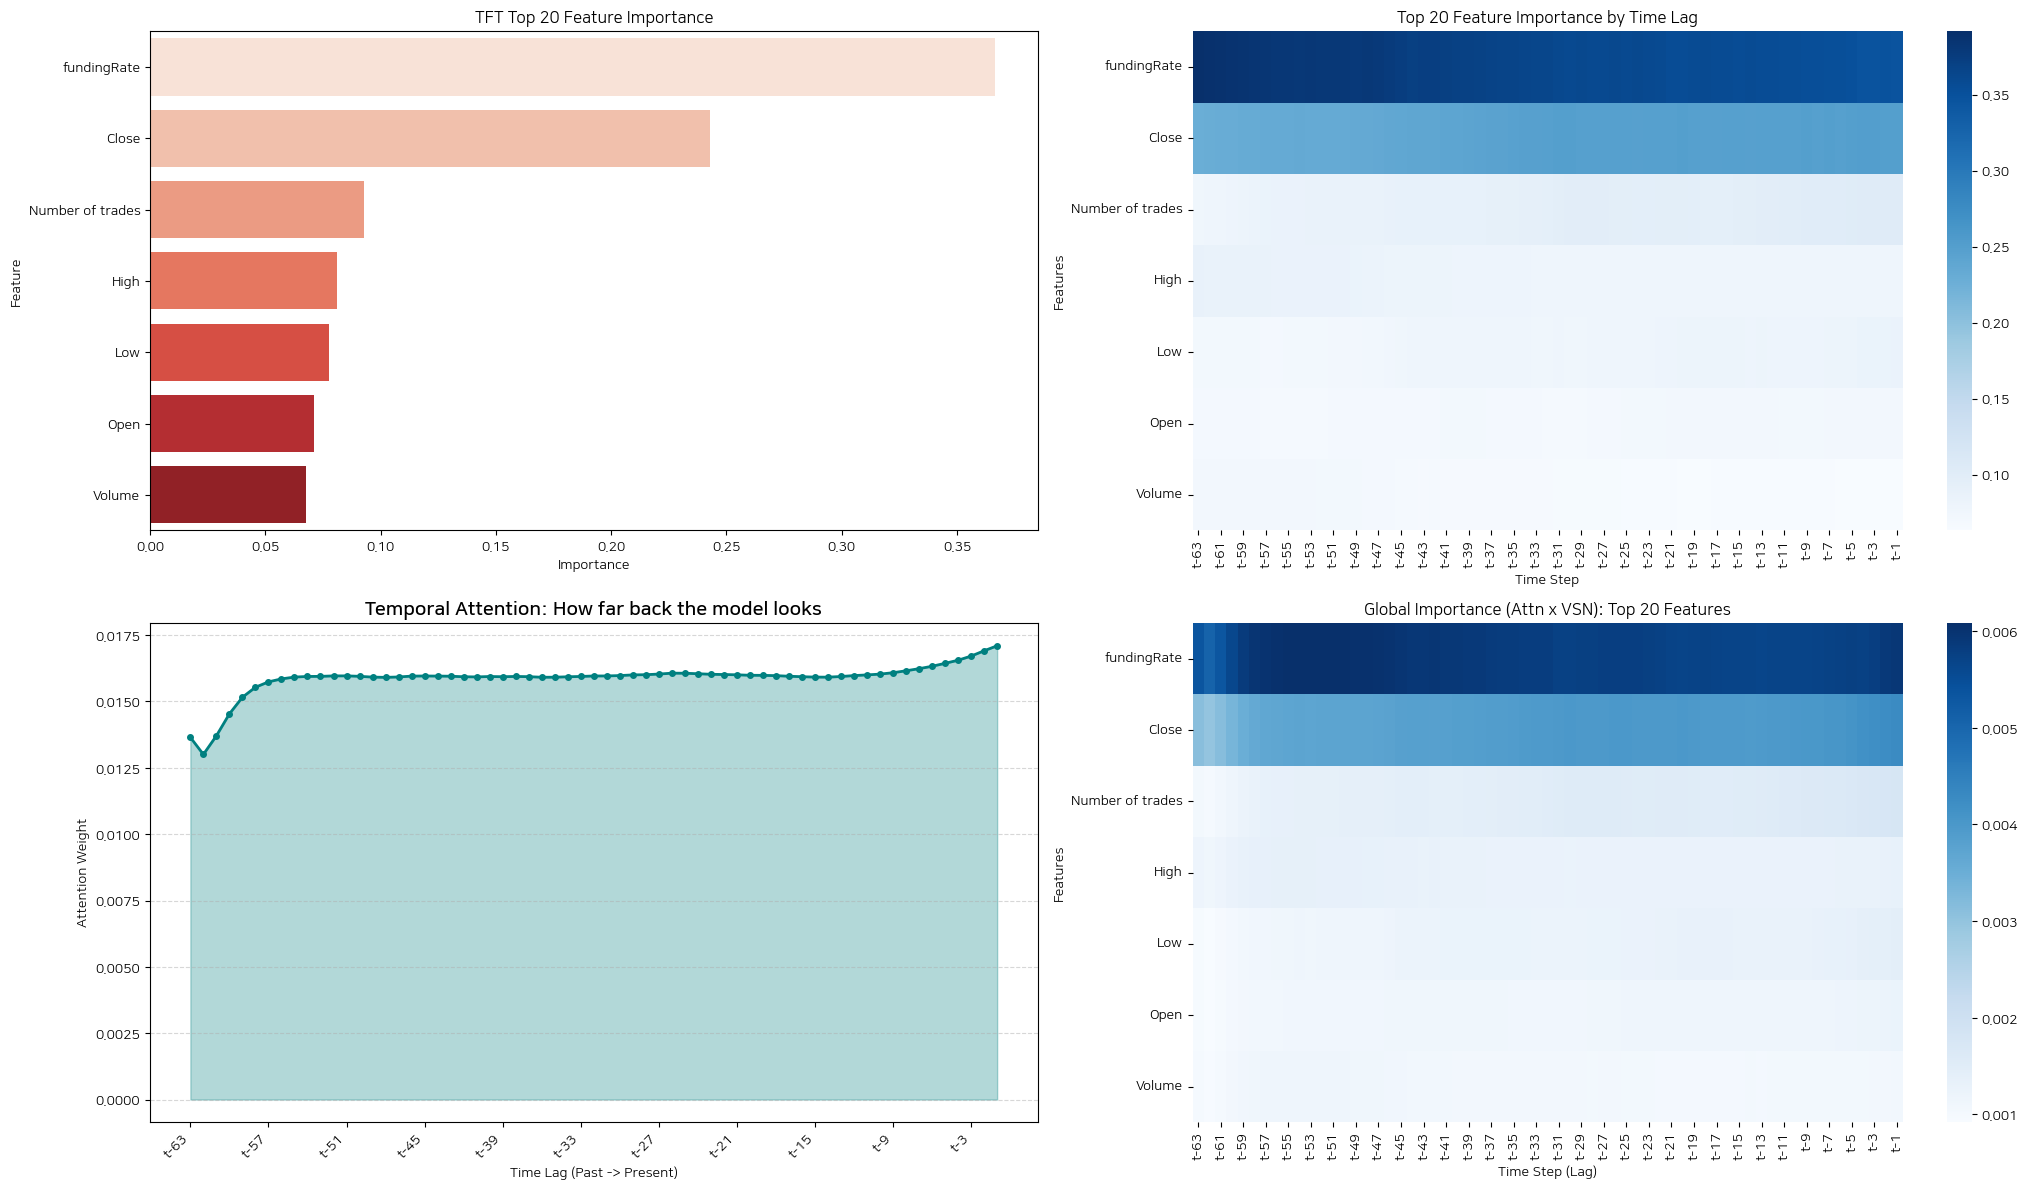

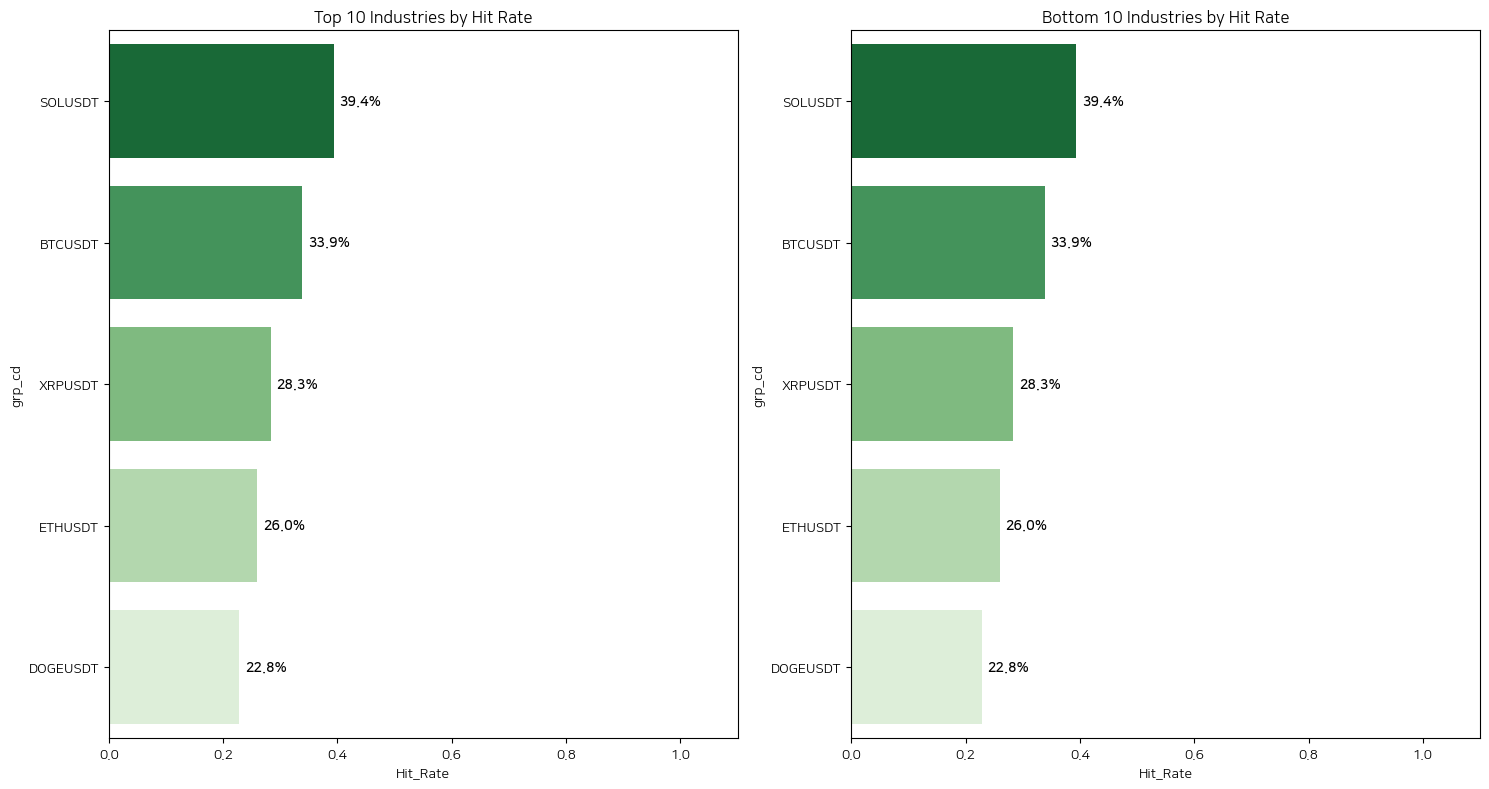

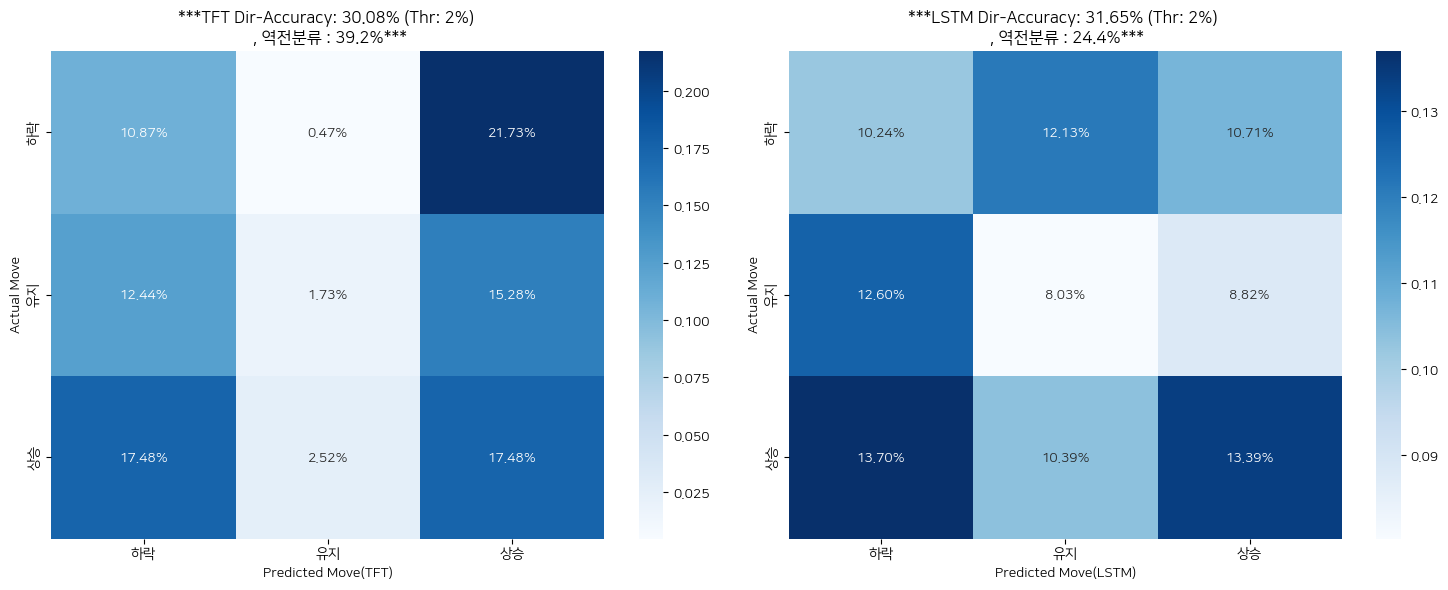

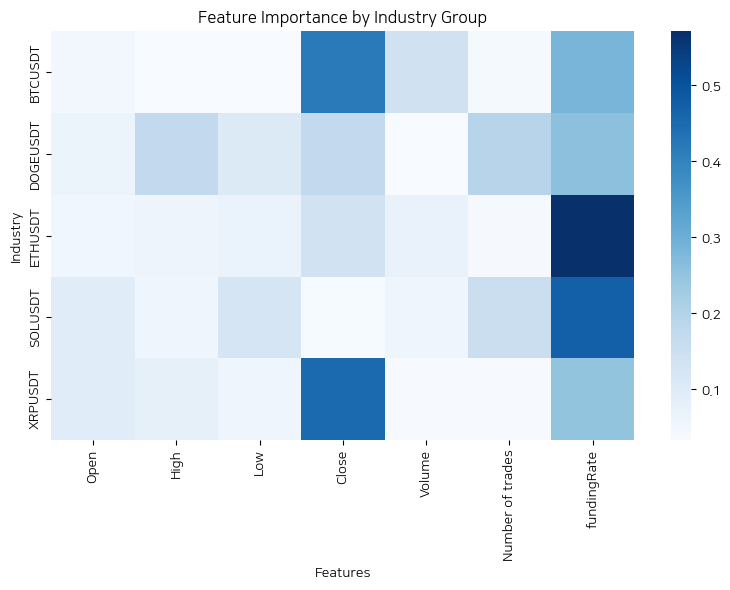

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 10/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 128, 'n_heads': 8, 'seq_length': 21}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121808~2026030100 자료 추출 중 : 1095
test set : 2026021508~2026041200 자료 추출 중 : 840
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.117019 | val_loss=0.130069 | test_loss=0.117984 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/10_2605160751_D32_H128_N8_SEQ21/tft_best.pt
***[TFT Epoch:002] train_loss=0.110942 | val_loss=0.129092 | test_loss=0.097666 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/10_2605160751_D32_H128_N8_SEQ21/tft_best.pt
***[TFT Epoch:003] train_loss=0.107052 | val_loss=0.122680 | test_loss=0.095031 | lr=3.99e-04***
 -> saved best to /content/d

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


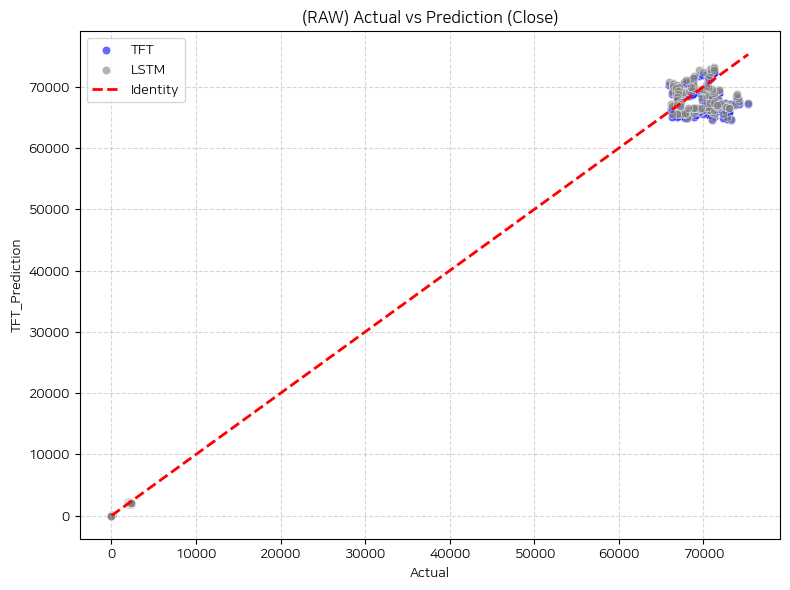

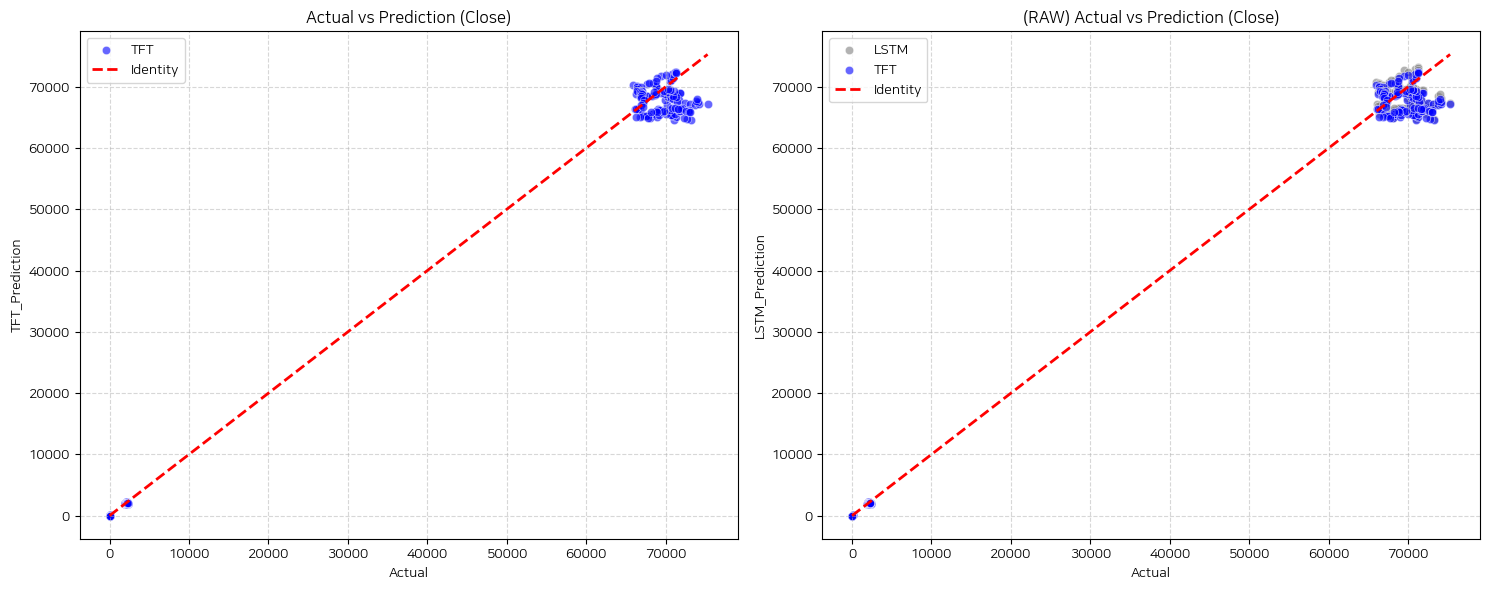

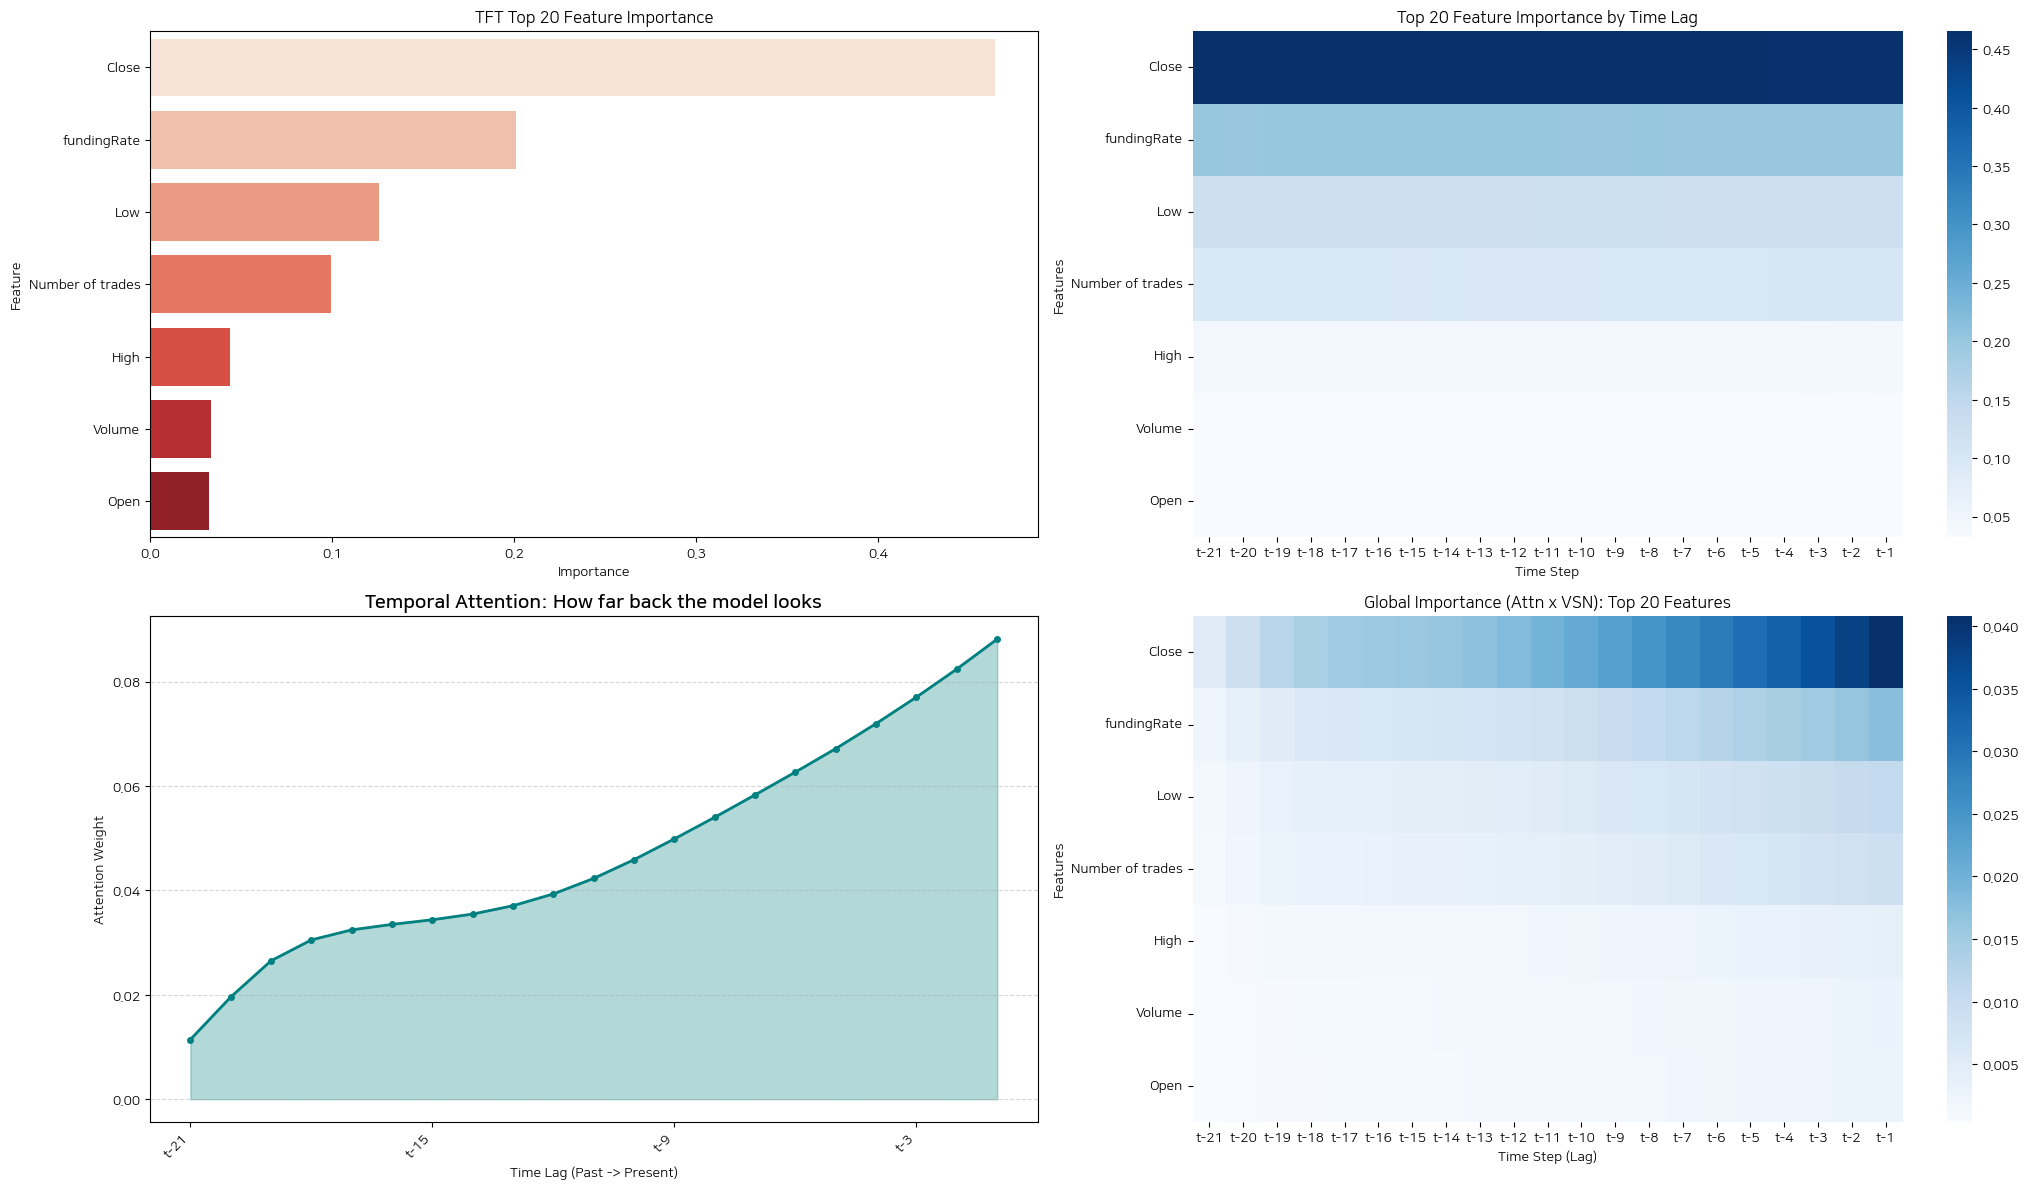

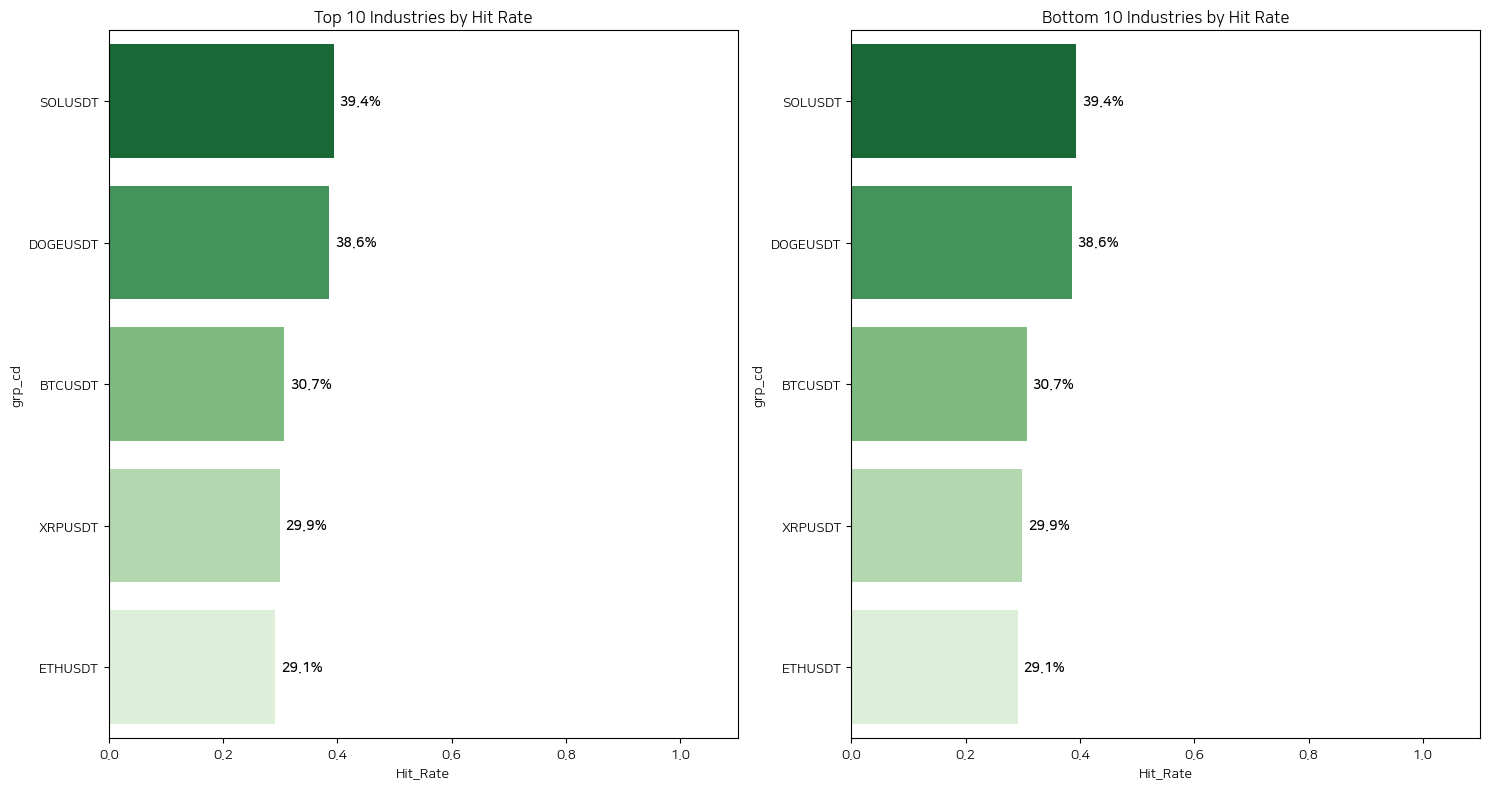

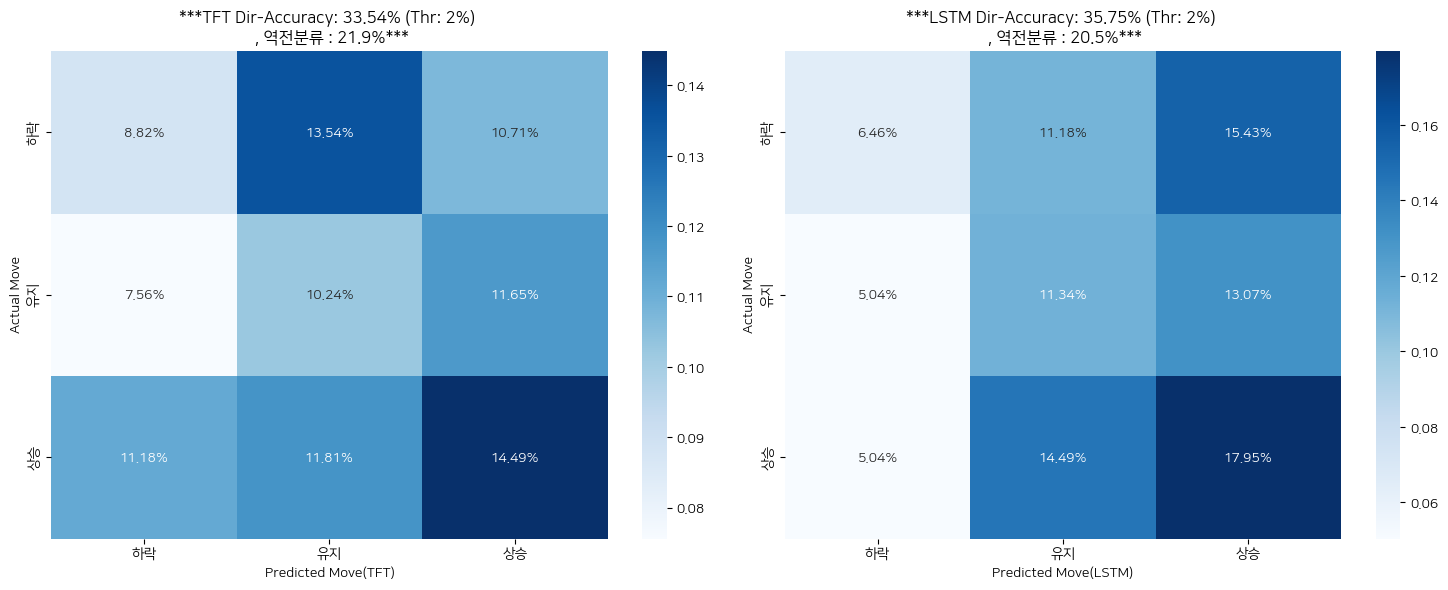

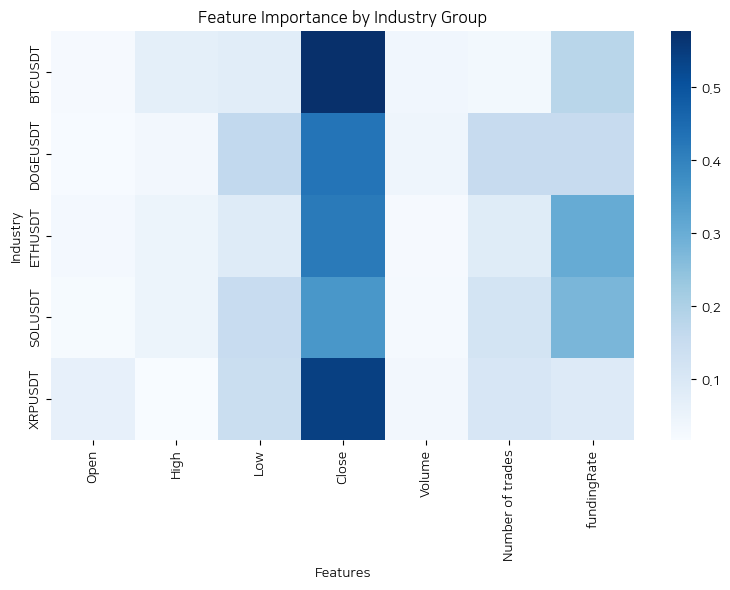

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 11/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 128, 'n_heads': 8, 'seq_length': 42}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121108~2026030100 자료 추출 중 : 1200
test set : 2026020808~2026041200 자료 추출 중 : 945
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.125018 | val_loss=0.155086 | test_loss=0.126581 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/11_2605160753_D32_H128_N8_SEQ42/tft_best.pt
***[TFT Epoch:002] train_loss=0.116751 | val_loss=0.141474 | test_loss=0.099532 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/11_2605160753_D32_H128_N8_SEQ42/tft_best.pt
***[TFT Epoch:003] train_loss=0.117488 | val_loss=0.164274 | test_loss=0.118112 | lr=3.99e-04***
***[TFT Epoch:004] train_los

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


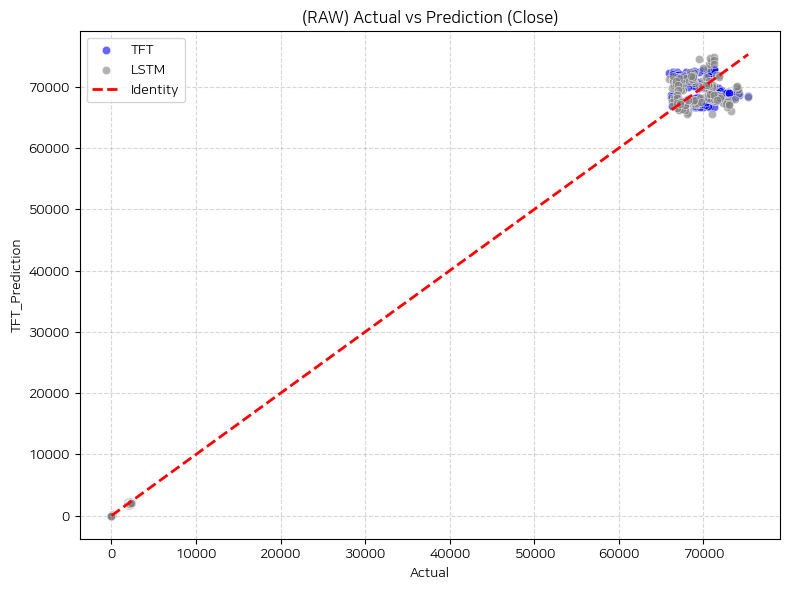

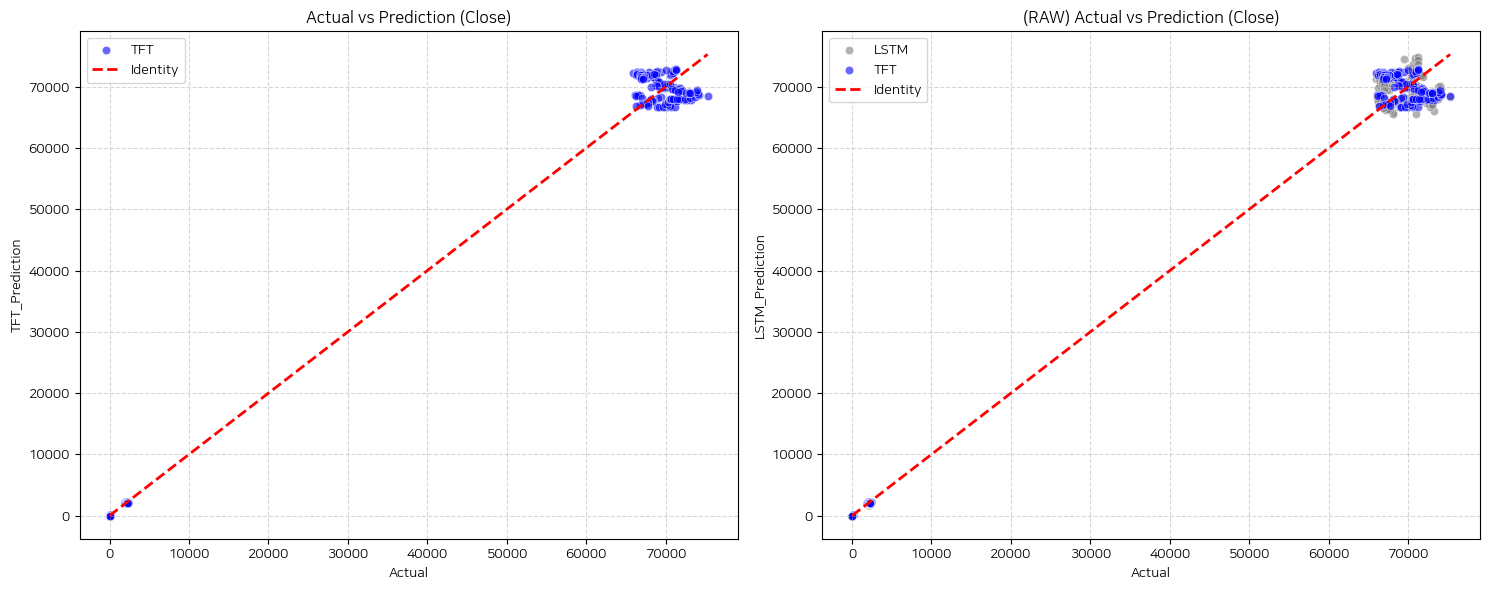

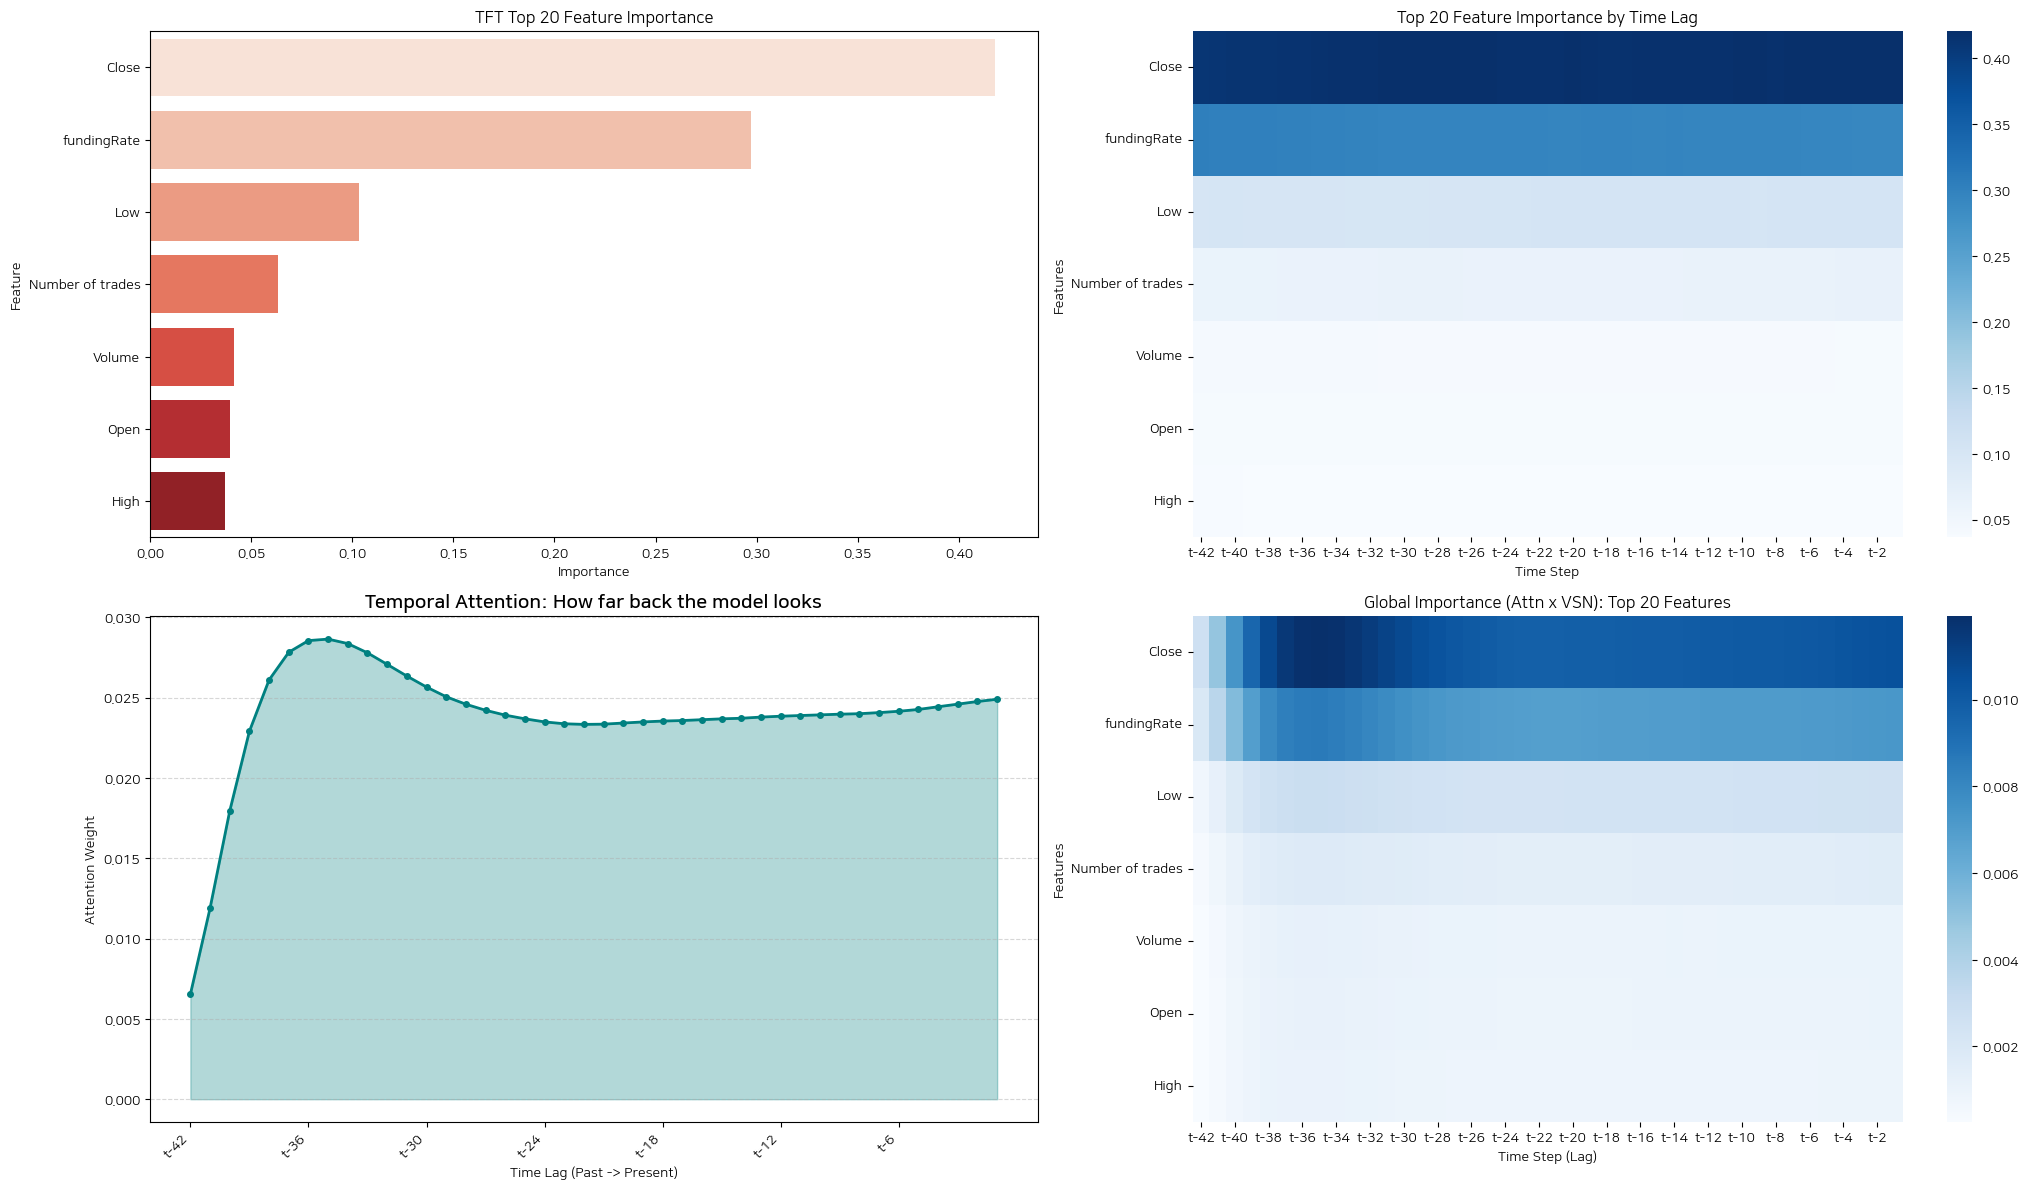

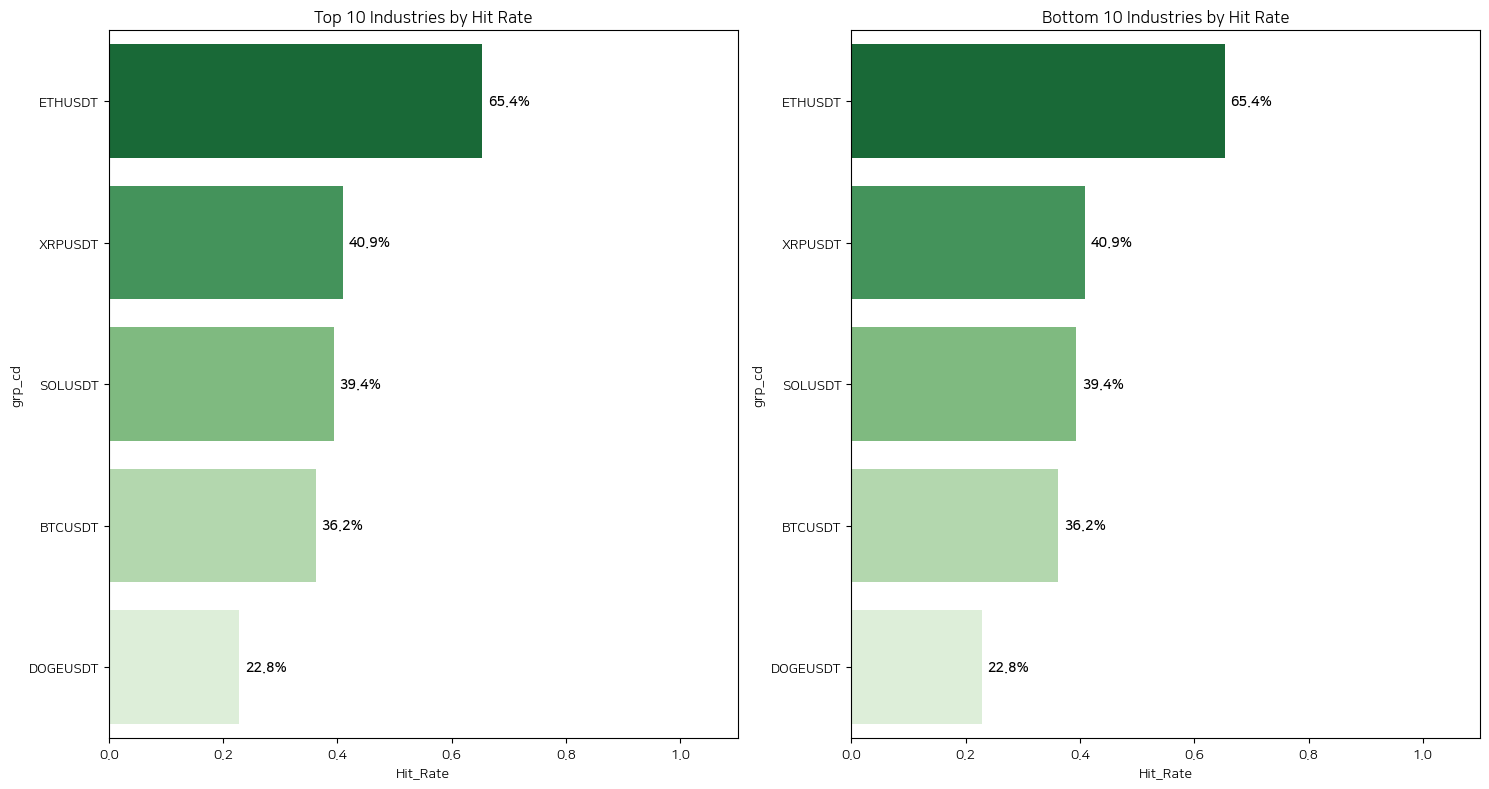

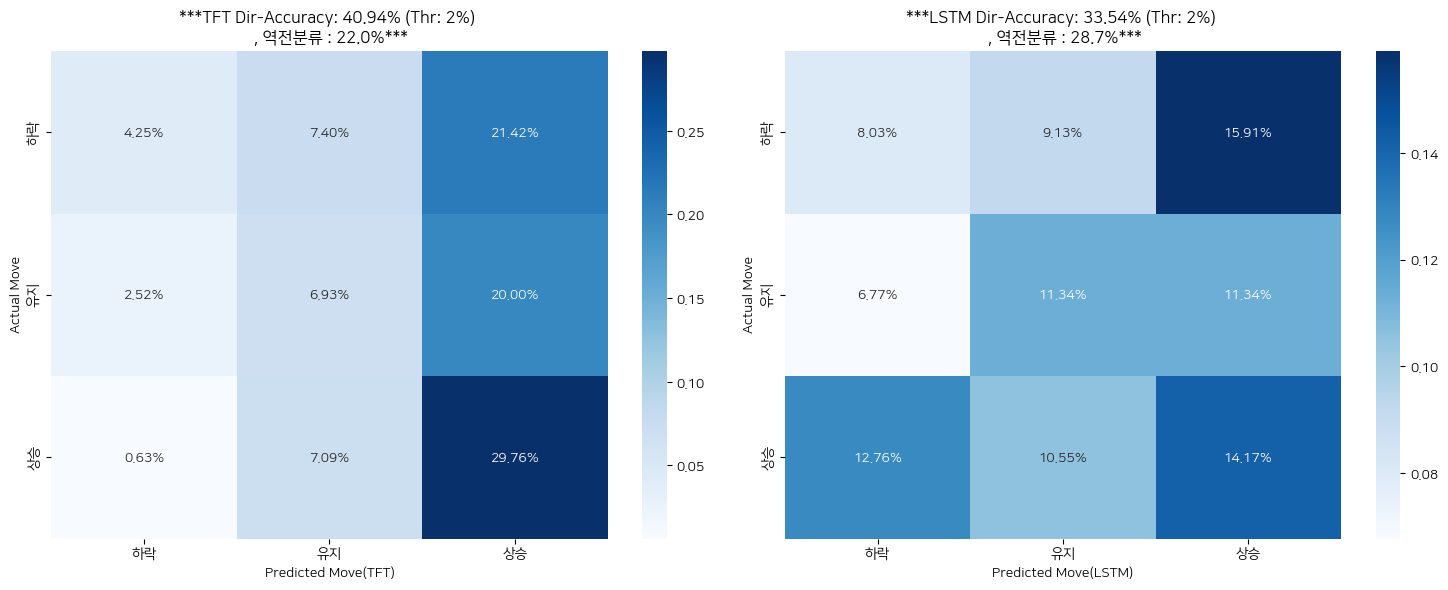

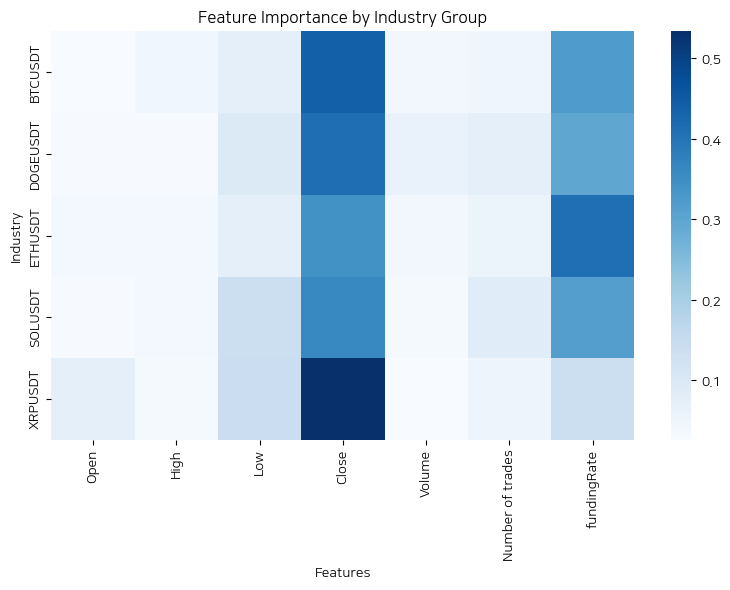

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 12/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 128, 'n_heads': 8, 'seq_length': 63}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025120408~2026030100 자료 추출 중 : 1305
test set : 2026020108~2026041200 자료 추출 중 : 1050
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.133261 | val_loss=0.159542 | test_loss=0.116167 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/12_2605160758_D32_H128_N8_SEQ63/tft_best.pt
***[TFT Epoch:002] train_loss=0.122857 | val_loss=0.150162 | test_loss=0.103624 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/12_2605160758_D32_H128_N8_SEQ63/tft_best.pt
***[TFT Epoch:003] train_loss=0.113093 | val_loss=0.130811 | test_loss=0.112552 | lr=3.99e-04***
 -> saved best to /content/

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


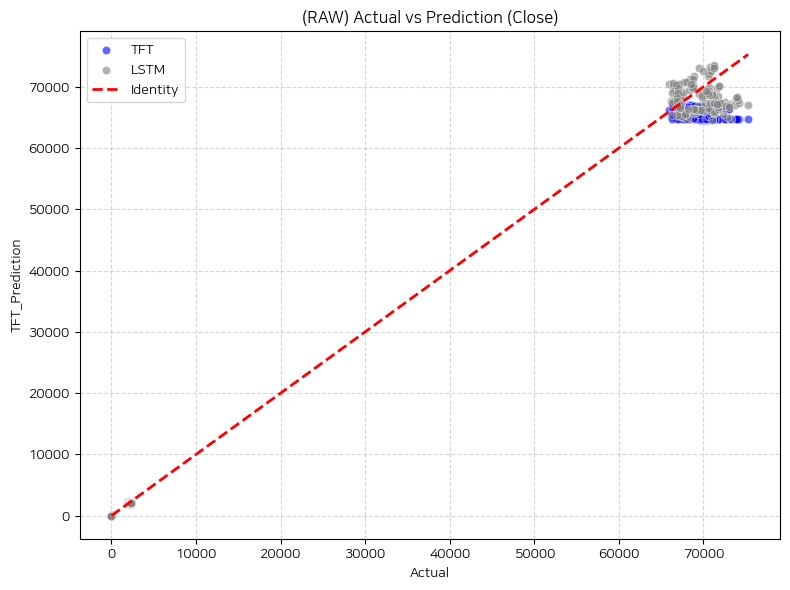

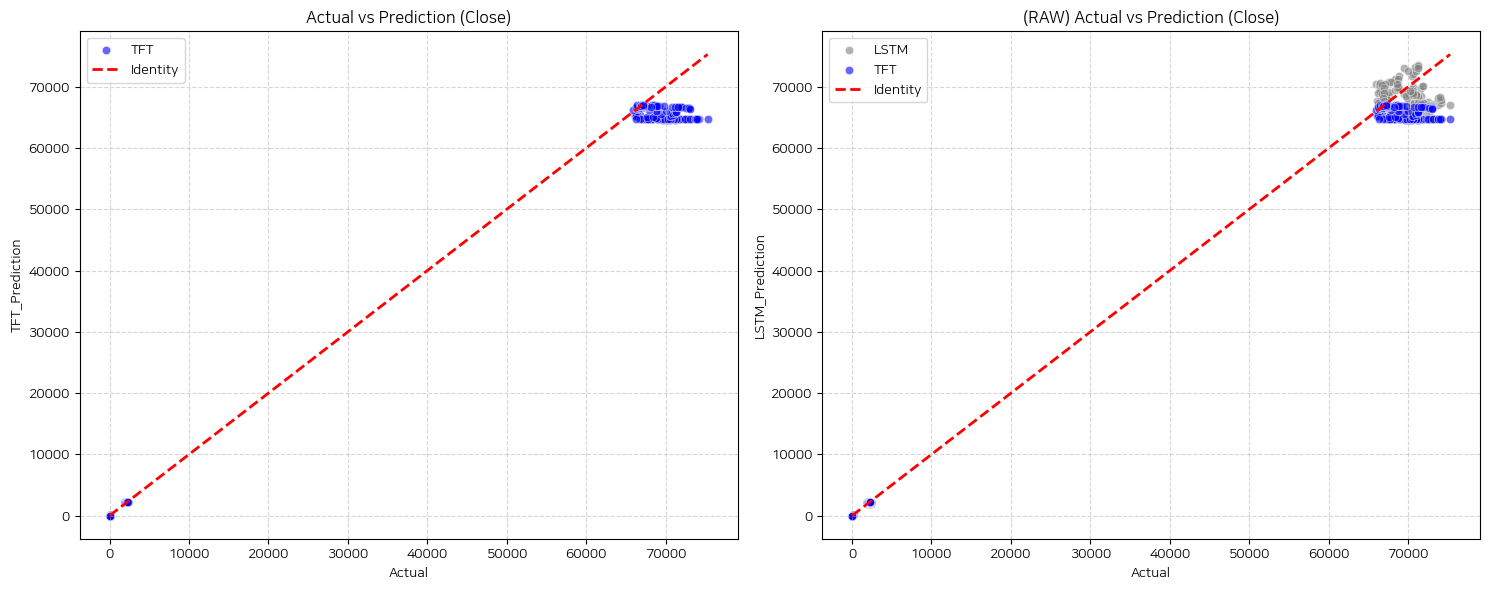

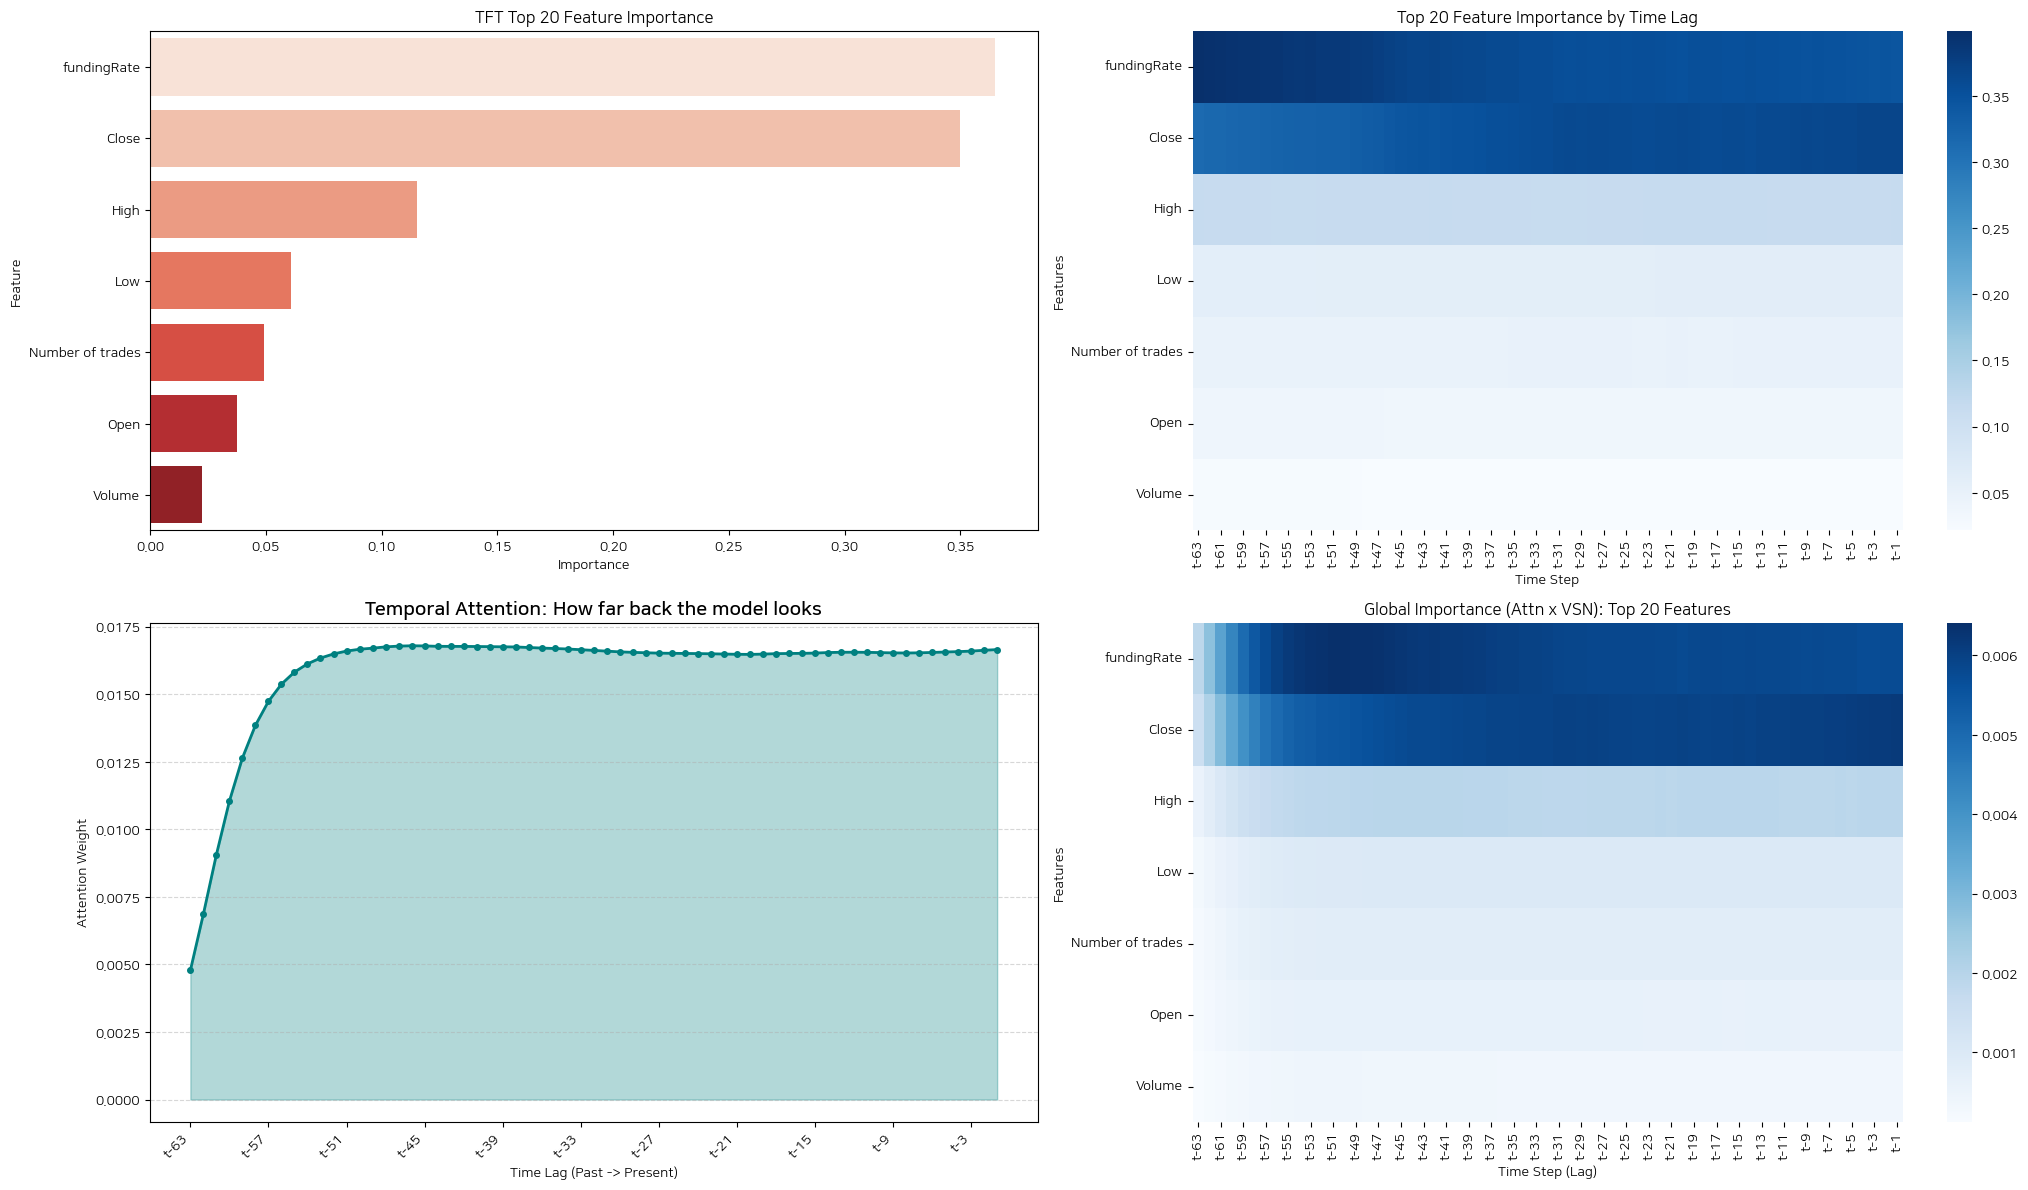

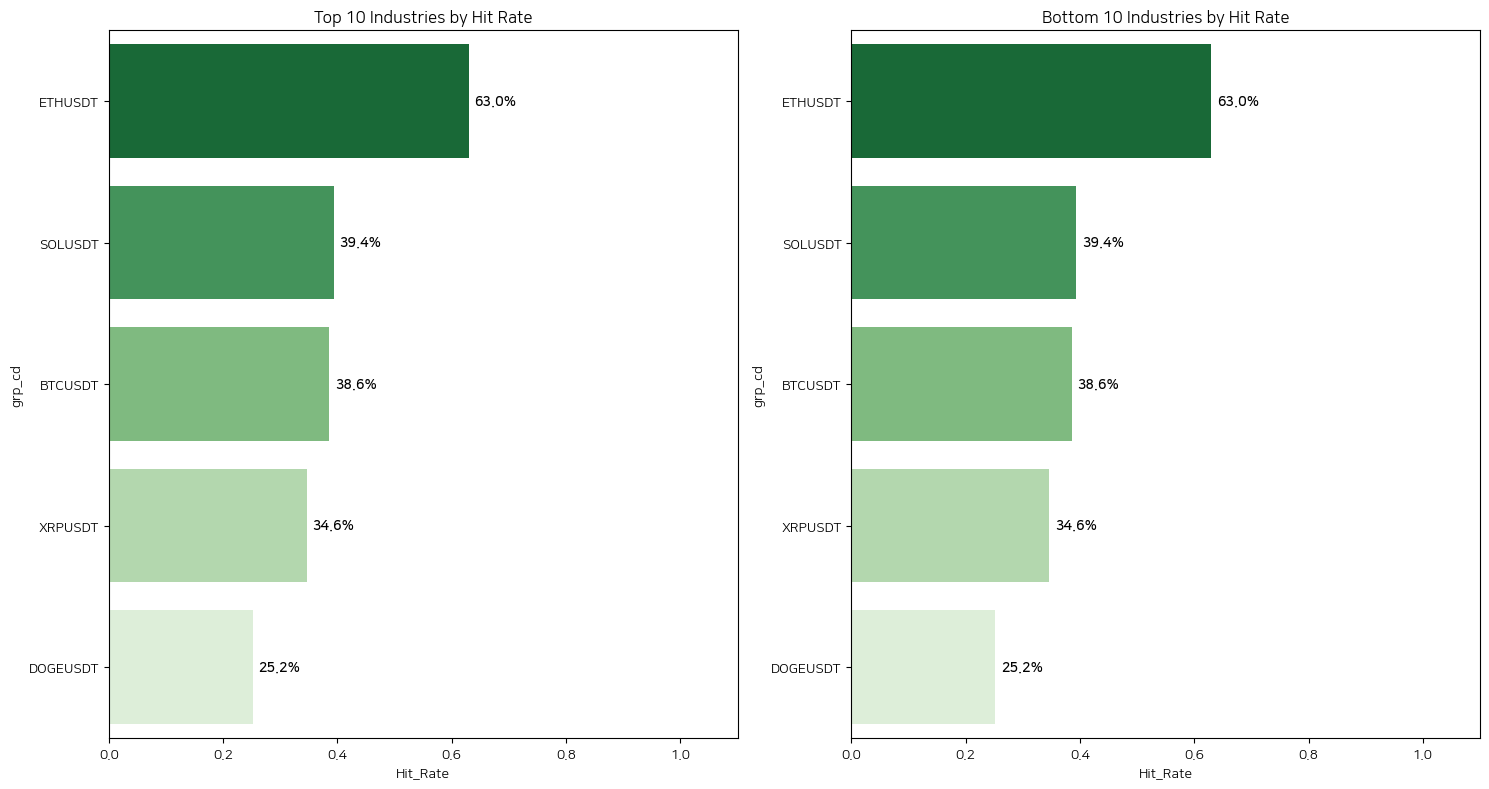

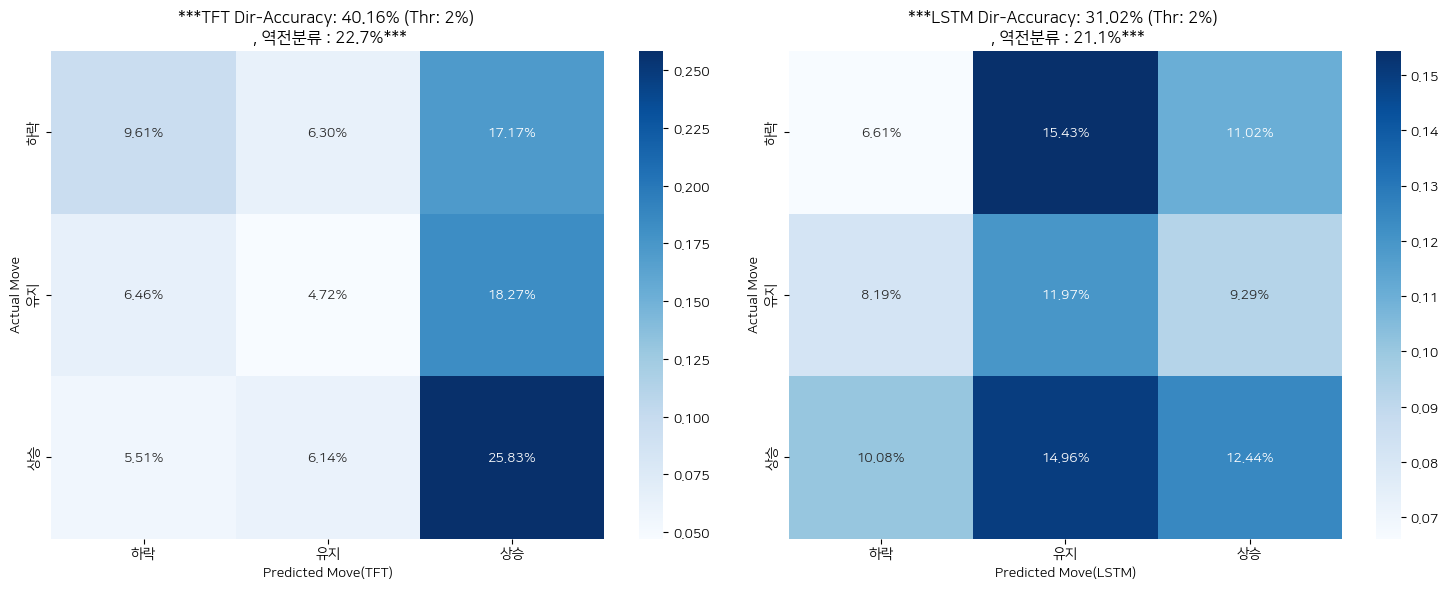

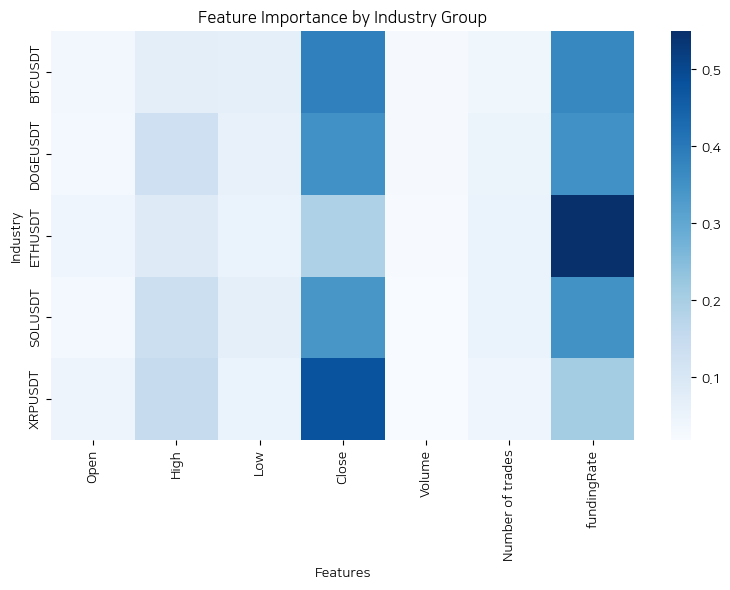

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 13/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 128, 'n_heads': 16, 'seq_length': 21}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121808~2026030100 자료 추출 중 : 1095
test set : 2026021508~2026041200 자료 추출 중 : 840
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.118223 | val_loss=0.136697 | test_loss=0.116587 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/13_2605160803_D32_H128_N16_SEQ21/tft_best.pt
***[TFT Epoch:002] train_loss=0.109511 | val_loss=0.126338 | test_loss=0.097432 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/13_2605160803_D32_H128_N16_SEQ21/tft_best.pt
***[TFT Epoch:003] train_loss=0.106811 | val_loss=0.119634 | test_loss=0.092583 | lr=3.99e-04***
 -> saved best to /conten

/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:494: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax2_1, palette='Reds')


==========시각화(2-3) Temporal Attention Score==========
==========시각화(2-4) 글로벌 중요도==========
==========시각화(3) Hit-rate(상/하위 10개)==========


/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:536: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_1, palette='Greens_r')
/content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/run_regression.py:544: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10_ind, x='Hit_Rate', y='grp_cd', ax=ax3_2, palette='Greens_r')


==========시각화(4) 변동 방향성 혼동행렬==========
==========시각화(4-1) TFT==========
==========시각화(4-2) LSTM==========
==========시각화(5) 변수중요도_산업별==========
==========★★★★★최종output★★★★★==========


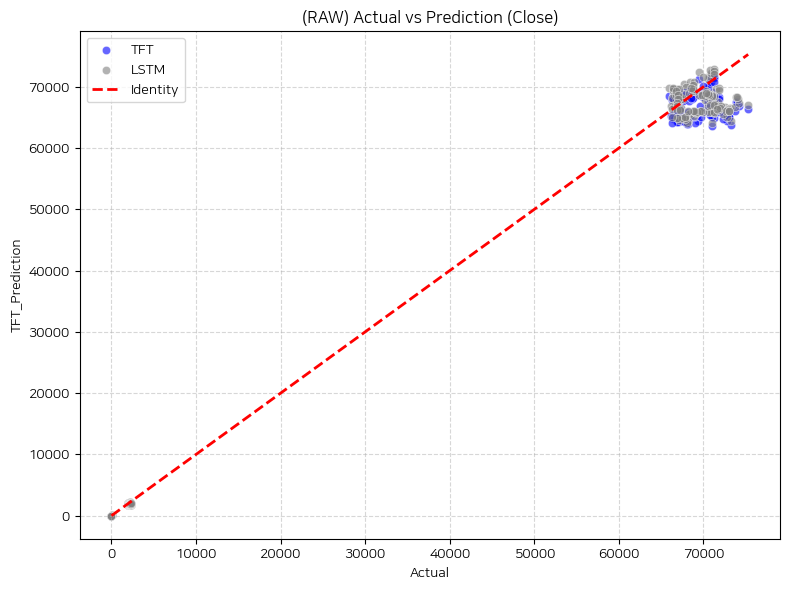

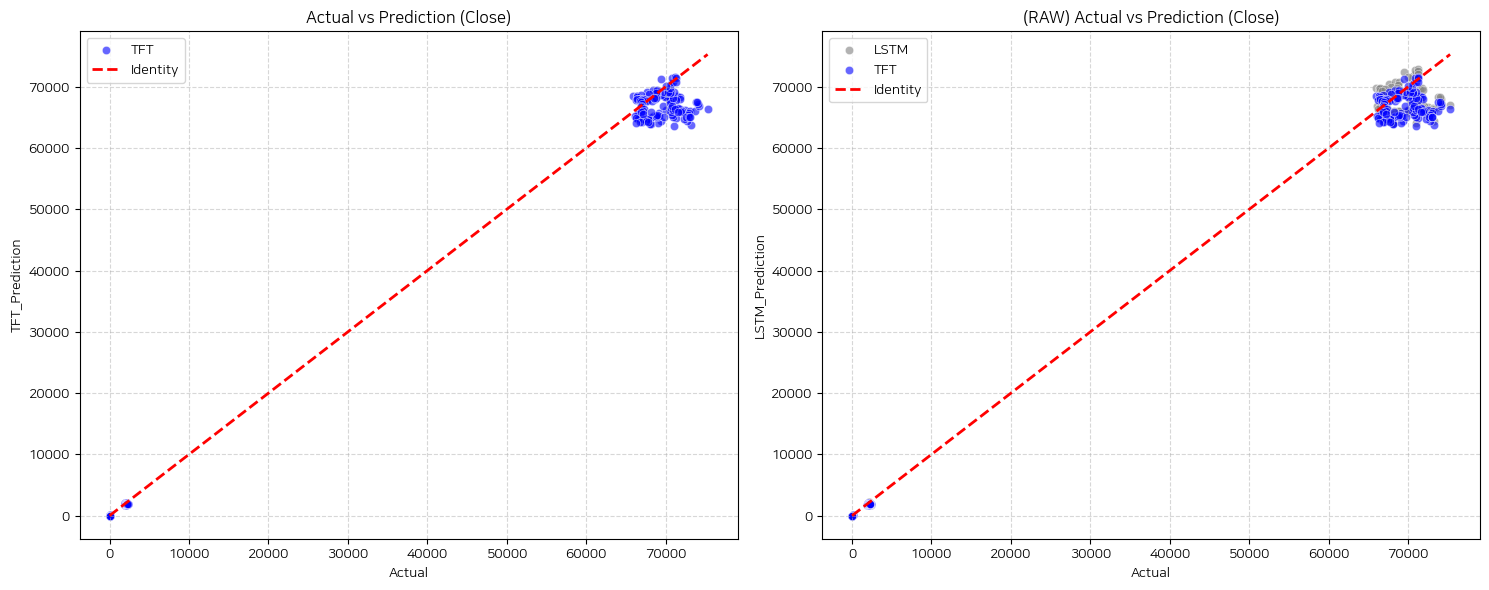

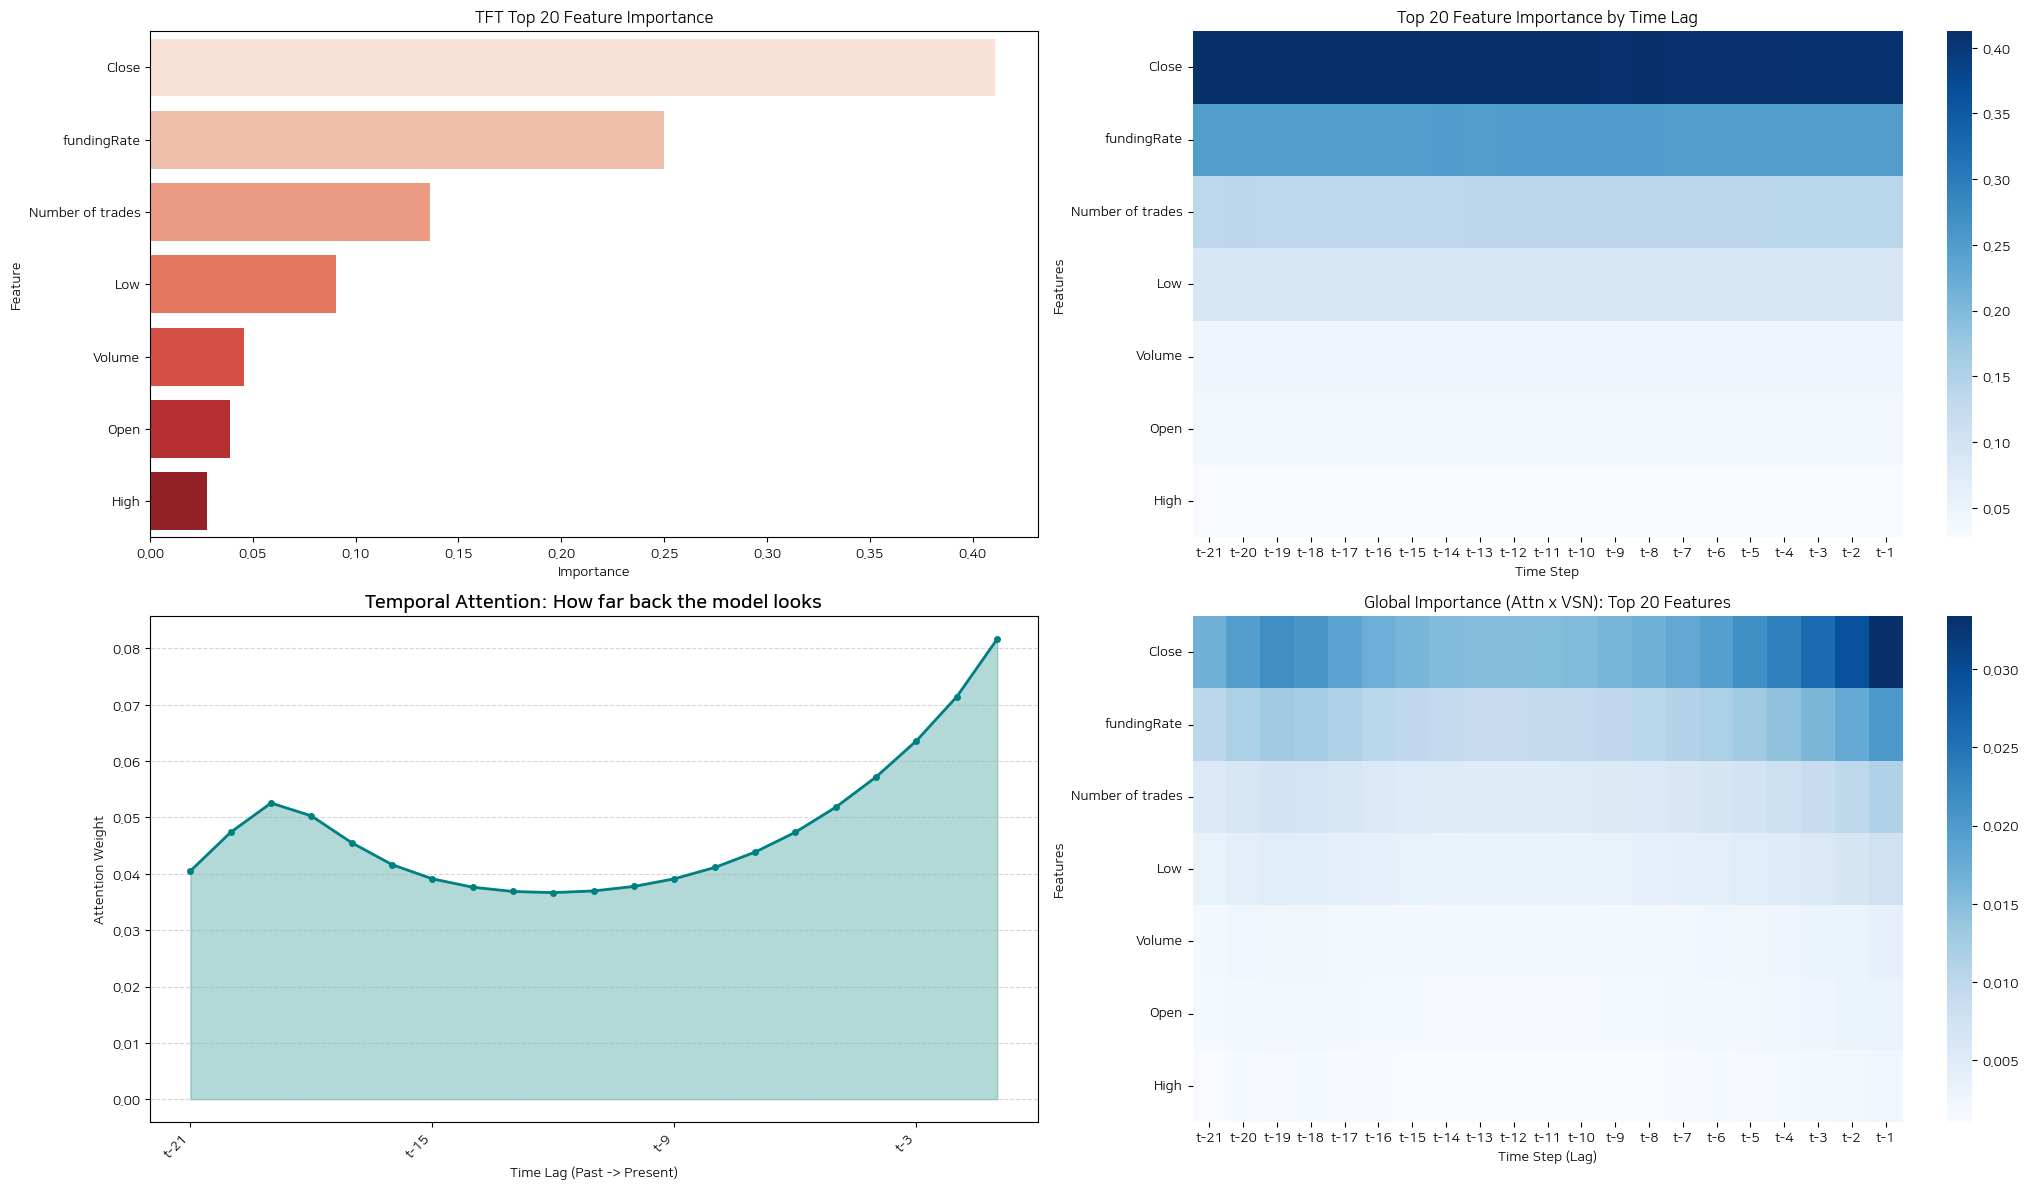

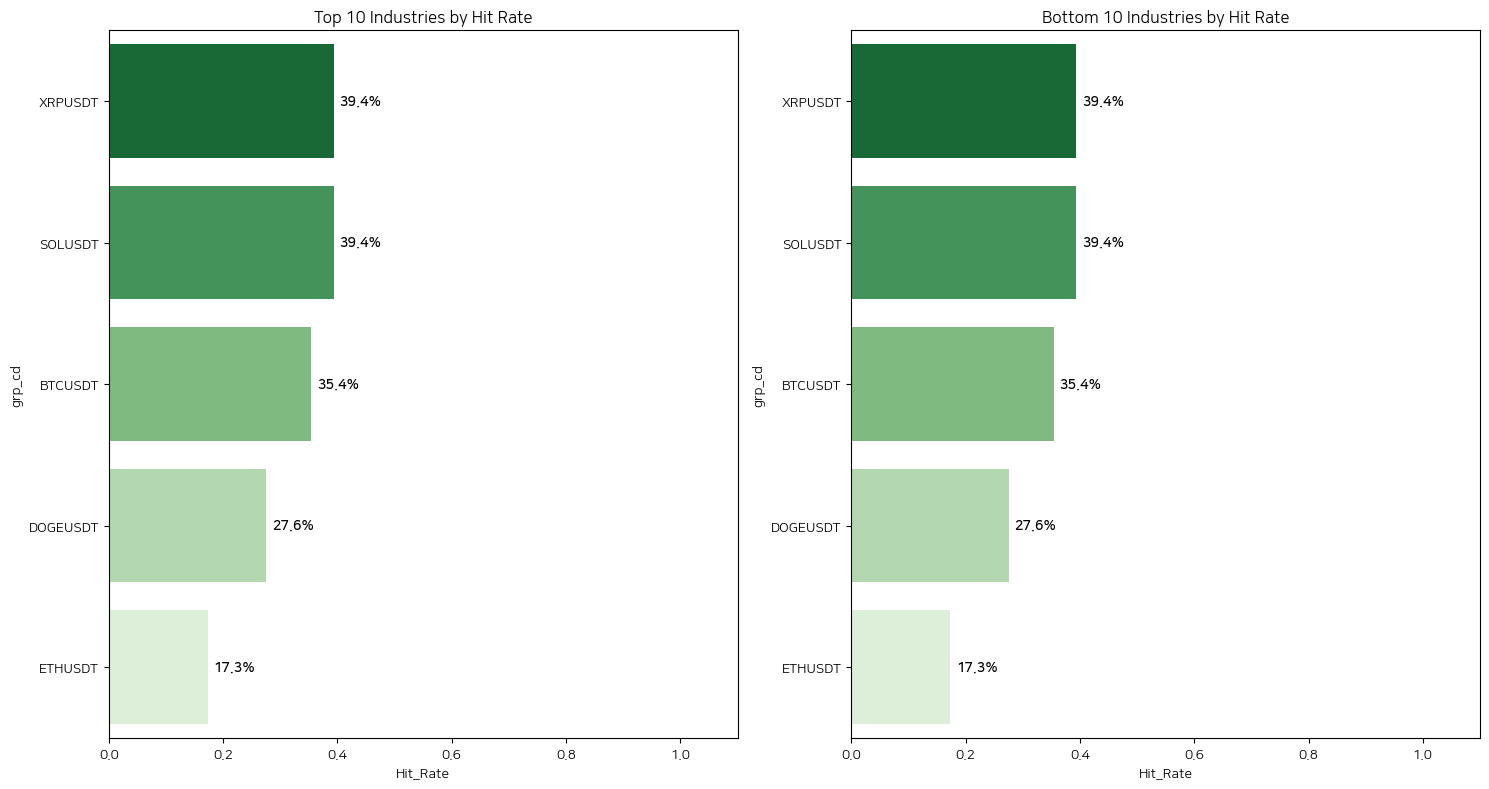

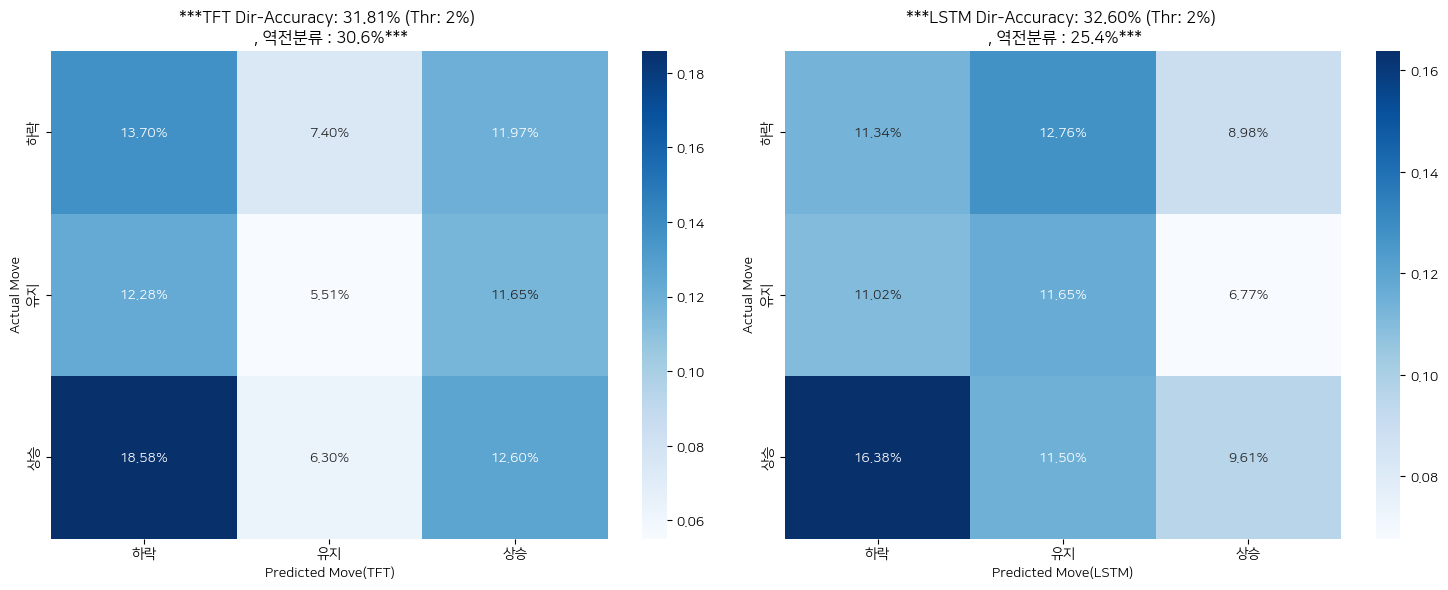

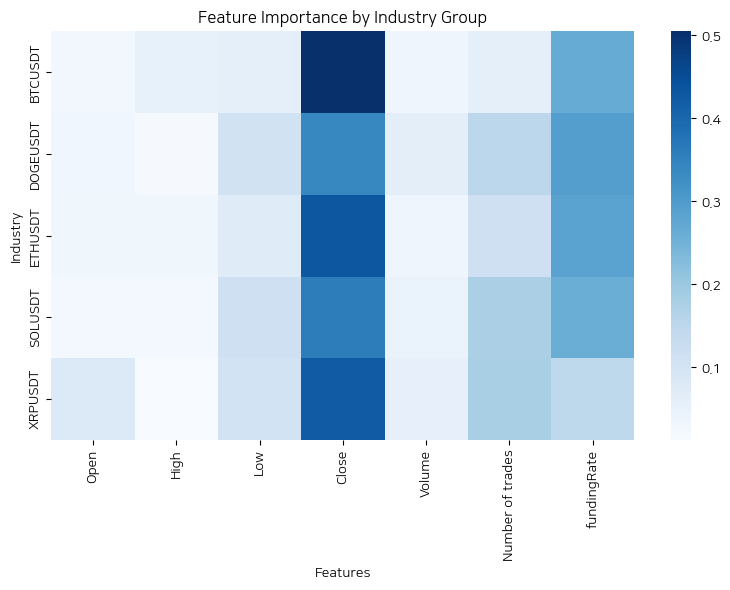

✅ df_log 전체 기록 완료 -> 경로: /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/df_log.csv.gz

🚀 [Trial 14/81] 모델 학습 시작...
📌 Params: {'d_model': 32, 'hidden_dim': 128, 'n_heads': 16, 'seq_length': 42}
====target : 4 Close=====
train: 2024030100~2026010100 자료 추출 중 : 10070
validation set : 2025121108~2026030100 자료 추출 중 : 1200
test set : 2026020808~2026041200 자료 추출 중 : 945
=======1. TFT 모델 학습중=======
cuda
***[TFT Epoch:001] train_loss=0.129181 | val_loss=0.146800 | test_loss=0.121602 | lr=4.88e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/14_2605160806_D32_H128_N16_SEQ42/tft_best.pt
***[TFT Epoch:002] train_loss=0.117159 | val_loss=0.142668 | test_loss=0.100073 | lr=4.53e-04***
 -> saved best to /content/drive/MyDrive/GCY6902_01_TFT/005.regression_final/outputs/dl/14_2605160806_D32_H128_N16_SEQ42/tft_best.pt
***[TFT Epoch:003] train_loss=0.121100 | val_loss=0.172878 | test_loss=0.122200 | lr=3.99e-04***
***[TFT Epoch:004] train_

In [ ]:
import itertools

# 1. 탐색할 하이퍼파라미터 그리드 설정
param_grid = {
    'd_model': [32, 64, 128],
    'hidden_dim': [64, 128, 256],
    'n_heads': [8, 16, 32],
    'seq_length': [21, 42, 63]  # SEQ도 그리드에 포함
}

# 2. 모든 조합 생성
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

target = "Close"
no=1
# 3. 루프 실행
for i, params in enumerate(combinations):
    # 기본 config_dict 설정
    config_dict = {
        'd_model': params['d_model'],
        'hidden_dim': params['hidden_dim'],
        'lstm_hidden': params['hidden_dim'], 
        'n_heads': params['n_heads'],
        'dropout': 0.2,
        'past_vars': len(var_list),
        'known_vars': 1,
        'static_vars': 1,
        'output_mode': "regression"
    }
    
    SEQ = params['seq_length']
    
    # 4. 폴더명 생성 (조합 정보 포함)
    timestamp = datetime.now().strftime('%y%m%d%H%M')
    folder_name = f"{no}_{timestamp}_D{config_dict['d_model']}_H{config_dict['hidden_dim']}_N{config_dict['n_heads']}_SEQ{str(SEQ).zfill(2)}"
    outdir = os.path.join(project_path, "outputs", "dl", folder_name) + "/"
    no += 1
    if not os.path.exists(outdir):
        os.makedirs(outdir)

    print(f"\n🚀 [Trial {i+1}/{len(combinations)}] 모델 학습 시작...")
    print(f"📌 Params: {params}")

    try:
        fit_and_out(
            df,
            target,
            outdir,
            config_dict,
            var_list=var_list,
            grp_cd="Symbol",
            epochs=50,
            patience=5,
            threshold=0.02,
            seq_length=SEQ,
            tgt_gap=20,
            seed=42)
    except Exception as e:
        print(f"❌ Trial {i+1} 실패: {e}")
        continue